In [1]:
import os
import pandas as pd
import numpy as np
import re 
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
from datetime import datetime, timedelta
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import ListedColormap
import geopandas as gpd
from shapely.validation import make_valid
from matplotlib.cm import get_cmap
from matplotlib.colors import LinearSegmentedColormap

# --- Configuration ---
path_to_scenarios   = '/home/abhis/india_power/scenarios'
path_to_save_images = '/home/abhis/india_power/images'
path_to_images = '/home/abhis/india_power/images'
path_to_csvs        = '/home/abhis/india_power/gridpath_india_viz/csvs'
# scenario_names = ['iced_2050_cc_1','iced_2050_cc_2','iced_2050_cc_3'] # Example: Explicit list
# scenario_names = ['pier_mid_ra_2040_1','pier_mid_ra_2040_2','pier_mid_ra_2040_3'] # Example: Explicit list
path_to_data = '/home/abhis/india_power/gridpath_india_viz/data/'
tech_labels_ = pd.read_csv(path_to_csvs + '/technology_labels_new_hydro_seperated.csv') 
# scenarios_   = pd.read_csv(path_to_csvs + '/ra-scenario_labels.csv')
# scenarios_   = pd.read_csv(path_to_csvs + '/ra-new_credits-0prm_noccap.csv')
scenarios_   = pd.read_csv(path_to_csvs + '/ra-new_credits-noprm_noccap.csv')
# scenarios_   = pd.read_csv(path_to_csvs + '/ra-new_credits-12prm_noccap.csv')
# scenarios_   = pd.read_csv(path_to_csvs + '/ra-new_credits-112_prm_no_ccap.csv')
# scenarios_   = pd.read_csv(path_to_csvs + '/ra-new_credits-noprm_noccap_12_subprob.csv')

# Load and processing system load timepoints

In [2]:
# Load and processing system load timepoints
def _processing_system_load_timepoints(scenarios_):

    dfs_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, dirnames, filenames in os.walk(path_to_scenario):
            # Processing scenarios results folder only
            if dirpath.split('/')[-1] == 'results':
                print(scenario)

                df_ = pd.read_csv(os.path.join(dirpath, 'system_load_zone_timepoint.csv'), low_memory = False)
                
                df_ = df_[['timepoint', 
                           'load_zone', 
                           'static_load_mw',
                           'net_imports_mw', 
                           'overgeneration_mw', 
                           'unserved_energy_mw']]
                
                df_ = df_.groupby(['timepoint',
                                   'load_zone']).agg({'static_load_mw': 'sum',
                                                      'net_imports_mw': 'sum',
                                                      'overgeneration_mw': 'sum',
                                                      'unserved_energy_mw': 'sum'}).reset_index(drop = False)
                
                df_ = df_.rename(columns = {'static_load_mw': 'static_load',
                                            'net_imports_mw': 'net_imports',
                                            'overgeneration_mw': 'overgeneration',
                                            'unserved_energy_mw': 'unserved_energy'})
                
                # df_ = pd.melt(df_, id_vars = ['timepoint', 
                #                                'load_zone'], 
                #                 value_vars = ['static_load', 
                #                               'net_imports',
                #                               'overgeneration',
                #                               'unserved_energy'], 
                #                 var_name   = 'technology', 
                #                 value_name = 'power_mw')
                
                # Add iteration descriptors to dataframe
                df_['W'] = dirpath.split('/')[-4].split('_')[-1]
                df_['H'] = dirpath.split('/')[-3].split('_')[-1]
                df_['A'] = dirpath.split('/')[-2].split('_')[-1]
                
                dfs_.append(df_)

    return pd.concat(dfs_).reset_index(drop = True)

df_load_ = _processing_system_load_timepoints(scenarios_)
print(df_load_.head())

pier_no_prm_no_ccap_2040_1
pier_no_prm_no_ccap_2040_2
pier_no_prm_no_ccap_2040_3
pier_no_prm_no_ccap_2040_4
pier_no_prm_no_ccap_2040_5
pier_no_prm_no_ccap_2040_6
pier_no_prm_no_ccap_2040_7
pier_no_prm_no_ccap_2040_8
pier_no_prm_no_ccap_2040_9
pier_no_prm_no_ccap_2040_10
pier_no_prm_no_ccap_2040_11
pier_no_prm_no_ccap_2040_12
pier_no_prm_no_ccap_2040_13
pier_no_prm_no_ccap_2040_14
pier_no_prm_no_ccap_2040_15
pier_no_prm_no_ccap_2040_16
pier_no_prm_no_ccap_2040_17
pier_no_prm_no_ccap_2040_18
    timepoint          load_zone   static_load   net_imports  overgeneration  \
0  2040040101     Andhra_Pradesh  18479.474483 -13241.268286             0.0   
1  2040040101  Arunachal_Pradesh    329.816680    261.713331             0.0   
2  2040040101              Assam   4089.792284   2952.740137             0.0   
3  2040040101             Bhutan      0.000000  -3060.159527             0.0   
4  2040040101              Bihar   9839.340580   6533.758546             0.0   

   unserved_energy  W  H

In [3]:
# Create a timestamp column from 'timepoint' field (YYYYMMDDHH)
tp = df_load_['timepoint'].astype(str)
dates = tp.str[:8]
hours = tp.str[8:].astype(int)  #1-24

df_load_['timestamp'] = (
    pd.to_datetime(dates, format='%Y%m%d')
    + pd.to_timedelta(hours, unit='h')
)
# Reorder so timestamp is first
cols = df_load_.columns.tolist()
cols.insert(0, cols.pop(cols.index('timestamp')))
df_load_ = df_load_[cols]

In [4]:
# === Add load_pct column to df_load_ ===
df = df_load_.copy()

# 1. Find annual (iteration-wise) peak static load
peak_load = (
    df.groupby(['W','H','A','load_zone'], as_index=False)['static_load']
      .max()
      .rename(columns={'static_load': 'annual_peak_static_load'})
)

# 2. Merge peak value back to main dataframe
df = df.merge(peak_load, on=['W','H','A','load_zone'], how='left')

# 3. Compute hourly static load as % of the iteration peak
df['load_pct'] = np.where(
    df['annual_peak_static_load'] > 0,
    100.0 * df['static_load'] / df['annual_peak_static_load'],
    np.nan
)

# 4. Assign back to df_load_
df_load_ = df.copy()

# State-level metrics for all iterations (includes national metrics)

In [5]:
df = df_load_.copy()

# Exclude Bhutan
df = df[df['load_zone'] != "Bhutan"].copy()

HOURS_PER_YEAR = 8760.0  
tau = 1.0  # 1 MW threshold for LOL event

df['is_lol']     = df['unserved_energy'] > tau
df['date']       = df['timestamp'].dt.date
df['hrs_in_tmp'] = 1

def compute_metrics(sub, label):
    """Compute RA metrics for a given dataframe slice."""
    num_iters = sub[['W','H','A']].drop_duplicates().shape[0]
    hrs_run_total = float(sub['hrs_in_tmp'].sum())
    n_years = hrs_run_total / HOURS_PER_YEAR if hrs_run_total else np.nan

    total_lol_hours    = int(sub['is_lol'].sum())
    total_unserved_MWh = float((sub['unserved_energy'] * sub['hrs_in_tmp']).sum())
    total_energy_MWh   = float((sub['static_load']     * sub['hrs_in_tmp']).sum())

    days_with_lol = int(
        sub.groupby(['W','H','A','date'])['is_lol'].max().sum()
    )

    # Annualized metrics
    EUE_MWh_per_yr   = (total_unserved_MWh / n_years) if np.isfinite(n_years) else np.nan
    LOLH_hrs_per_yr  = (total_lol_hours / n_years) if np.isfinite(n_years) else np.nan
    LOLE_days_per_yr = (days_with_lol / n_years) if np.isfinite(n_years) else np.nan

    return {
        'load_zone':               label,
        'iterations (W,H,A)':      num_iters,
        'LOLH (hrs/yr)':           LOLH_hrs_per_yr,
        'EUE (MWh/yr)':            EUE_MWh_per_yr,
        'LOLE (days/yr)':          LOLE_days_per_yr,
        'LOLE (days/10yr)':        (LOLE_days_per_yr * 10) if np.isfinite(LOLE_days_per_yr) else np.nan,
        'LOLP (fraction of hrs)':  (total_lol_hours / hrs_run_total) if hrs_run_total > 0 else np.nan,
        'LOLP (%)':                ((total_lol_hours / hrs_run_total) * 100) if hrs_run_total > 0 else np.nan,
        'Annual Energy (MWh/yr)':  (total_energy_MWh / n_years) if np.isfinite(n_years) else np.nan,
        'NENS (%)':                (100 * EUE_MWh_per_yr / (total_energy_MWh / n_years))
                                   if (n_years and total_energy_MWh > 0) else np.nan,
    }

# --- per-zone metrics ---
zone_metrics = []
for zone, sub in df.groupby("load_zone"):
    zone_metrics.append(compute_metrics(sub.copy(), zone))
metrics_df = pd.DataFrame(zone_metrics)

# --- national metric (all zones pooled) ---
national_metric_df = pd.DataFrame([
    compute_metrics(df.copy(), "National (excl. Bhutan)")
])

# --- outputs ---
print(metrics_df)

print(national_metric_df)


             load_zone  iterations (W,H,A)  LOLH (hrs/yr)  EUE (MWh/yr)  \
0       Andhra_Pradesh                  18       0.277778    710.816432   
1    Arunachal_Pradesh                  18       0.000000      0.000000   
2                Assam                  18       0.000000      0.000000   
3                Bihar                  18       0.000000      0.000000   
4           Chandigarh                  18      10.111111    719.669064   
5         Chhattisgarh                  18       0.000000      0.000000   
6   Dadra_Nagar_Haveli                  18      51.666667  33131.259502   
7            Daman_Diu                  18       6.333333   2508.571033   
8                Delhi                  18       6.777778  28842.532303   
9                  Goa                  18       7.500000   5367.463507   
10             Gujarat                  18       6.944444  28757.033119   
11             Haryana                  18       0.000000      0.000000   
12    Himachal_Pradesh   

# States violating the global standards

In [6]:
# Filter zones with LOLP > 0.0274 OR LOLE > 1 day/10yr
filtered_metrics_global_df = metrics_df[
    (metrics_df['LOLP (%)'] > 0.0274) |
    (metrics_df['LOLE (days/10yr)'] > 1.0)
].reset_index(drop=True)

print("=== Zones with inadequate reliability ===")
print(filtered_metrics_global_df)


=== Zones with inadequate reliability ===
             load_zone  iterations (W,H,A)  LOLH (hrs/yr)  EUE (MWh/yr)  \
0       Andhra_Pradesh                  18       0.277778    710.816432   
1           Chandigarh                  18      10.111111    719.669064   
2   Dadra_Nagar_Haveli                  18      51.666667  33131.259502   
3            Daman_Diu                  18       6.333333   2508.571033   
4                Delhi                  18       6.777778  28842.532303   
5                  Goa                  18       7.500000   5367.463507   
6              Gujarat                  18       6.944444  28757.033119   
7        Jammu_Kashmir                  18       1.500000   2307.237774   
8            Karnataka                  18       0.944444  16080.888895   
9          Maharashtra                  18       0.722222   8956.987800   
10           Meghalaya                  18       0.944444    268.038060   
11            Nagaland                  18       0.611111 

/tmp/ipykernel_1275677/1897440238.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('Reds')       # full Reds scale, starting from the true min


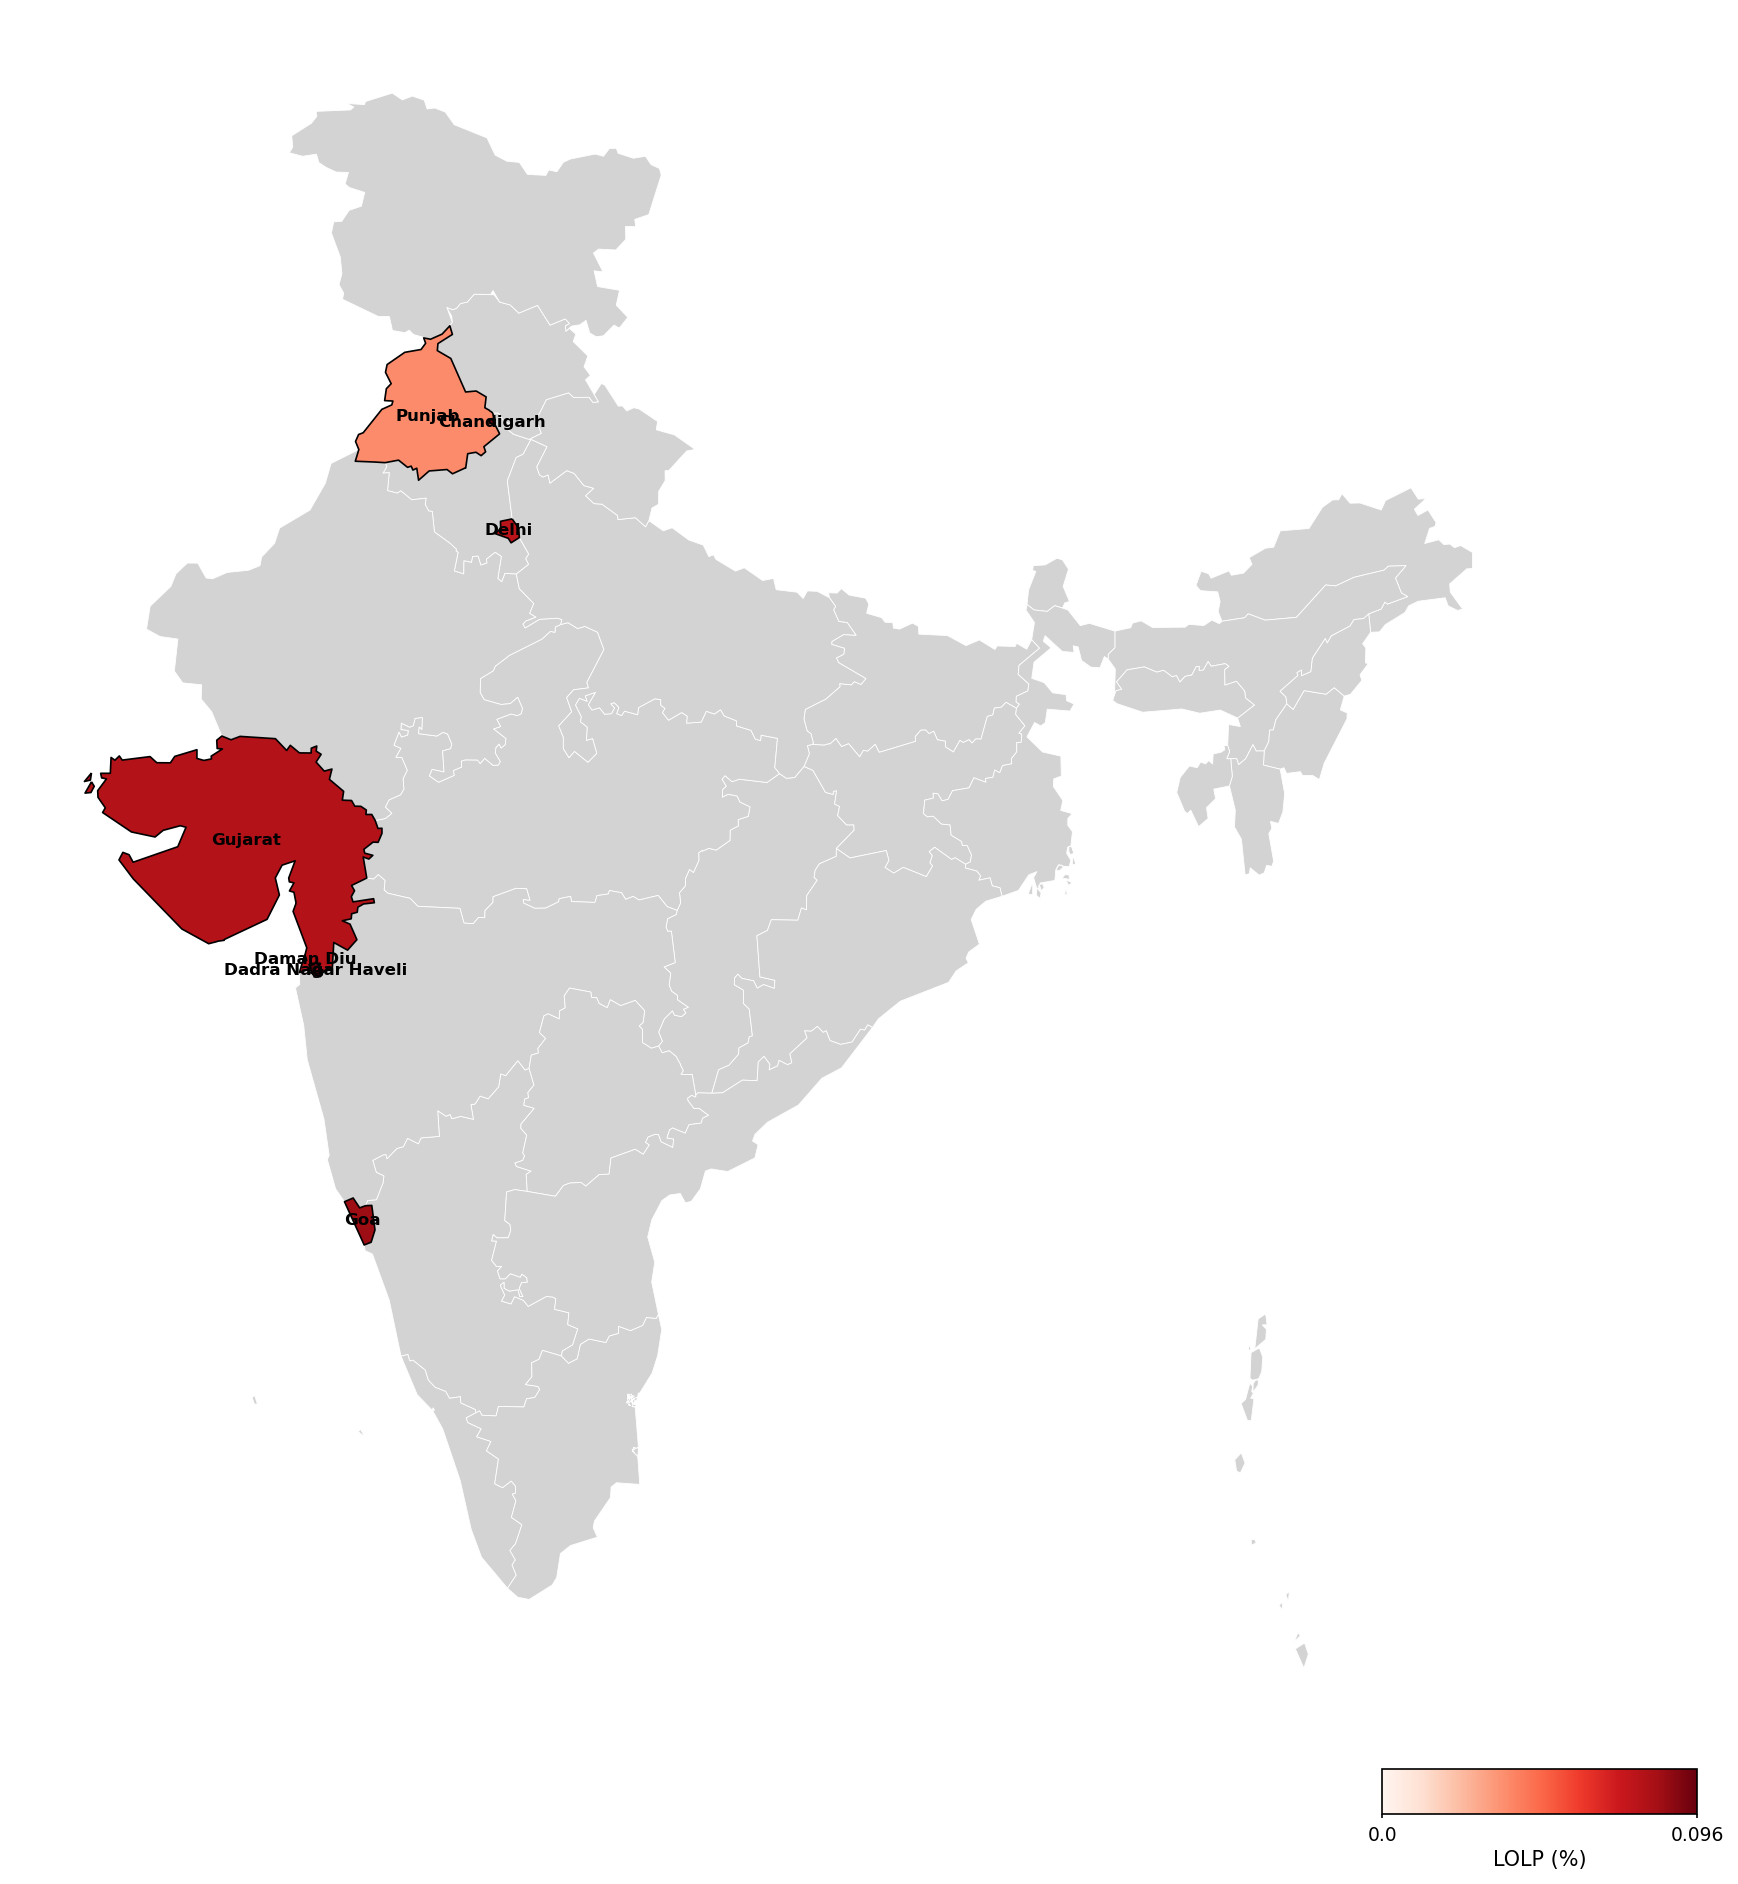

In [7]:
# --- Load shapefile ---
_india = gpd.read_file(path_to_data + "map/india/india-polygon.shp").to_crs("epsg:4326")
_india['geometry'] = _india['geometry'].apply(lambda geom: make_valid(geom) if geom else None)
_india = _india.dropna(subset=['geometry'])

# Harmonize naming
_india = _india.rename(columns={'st_nm': 'load_zone'})
_india['load_zone'] = (
    _india['load_zone']
    .str.replace(" ", "_")
    .str.replace("&", "and")
    .str.replace("_and_", "_", regex=False)
)

# Merge union for DNH + DD if both exist
if 35 in _india.index and 36 in _india.index:
    _india.loc[35, 'geometry'] = _india.loc[35, 'geometry'].union(_india.loc[36, 'geometry'])
    _india = _india.drop([36]).reset_index(drop=True)

# --- Merge with reliability metrics ---
india_metrics = _india.merge(metrics_df, on='load_zone', how='left')

# --- Apply violation flag (LOLP only) ---
threshold = 0.0274
india_metrics['violation'] = india_metrics['LOLP (%)'] > threshold

# --- Clip extreme values (to balance colors) ---
india_metrics['LOLP (%)'] = india_metrics['LOLP (%)'].clip(
    upper=india_metrics['LOLP (%)'].quantile(0.95)
)

# --- Define color normalization and colormap ---
cmap = get_cmap('Reds')       # full Reds scale, starting from the true min
vmin = float(np.nanmin(india_metrics['LOLP (%)']))
vmax = float(np.nanmax(india_metrics['LOLP (%)']))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 15), dpi=150)

# Base map (light grey background)
india_metrics.plot(ax=ax, color="lightgrey", edgecolor="white", lw=0.4, zorder=1)

# Violating states shaded by LOLP intensity
india_metrics[india_metrics['violation']].plot(
    ax=ax,
    column='LOLP (%)',
    cmap=cmap,
    norm=norm,
    edgecolor='black',
    linewidth=0.8,
    zorder=2
)

# --- Smooth, small colorbar at bottom-right ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []

# [x0, y0, width, height] → bottom right position
cax = fig.add_axes([0.80, 0.08, 0.15, 0.02])
cb = plt.colorbar(sm, cax=cax, orientation='horizontal')

cb.set_label("LOLP (%)", fontsize=10, labelpad=2)
cb.ax.tick_params(labelsize=9, length=2)

cb.set_ticks([vmin, vmax])
cb.set_ticklabels([f'{np.round(vmin, 3)}', f'{np.round(vmax, 3)}'])

# --- Labels for violating states ---
for _, row in india_metrics[india_metrics['violation']].iterrows():
    x, y = row['geometry'].centroid.x, row['geometry'].centroid.y
    ax.text(
        x, y, row['load_zone'].replace("_", " "),
        fontsize=8, ha='center', va='center',
        color='black', weight='bold', zorder=3
    )

# --- Clean up axes ---
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()

/tmp/ipykernel_1275677/2663293854.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('Blues')    # blue gradient for NENS


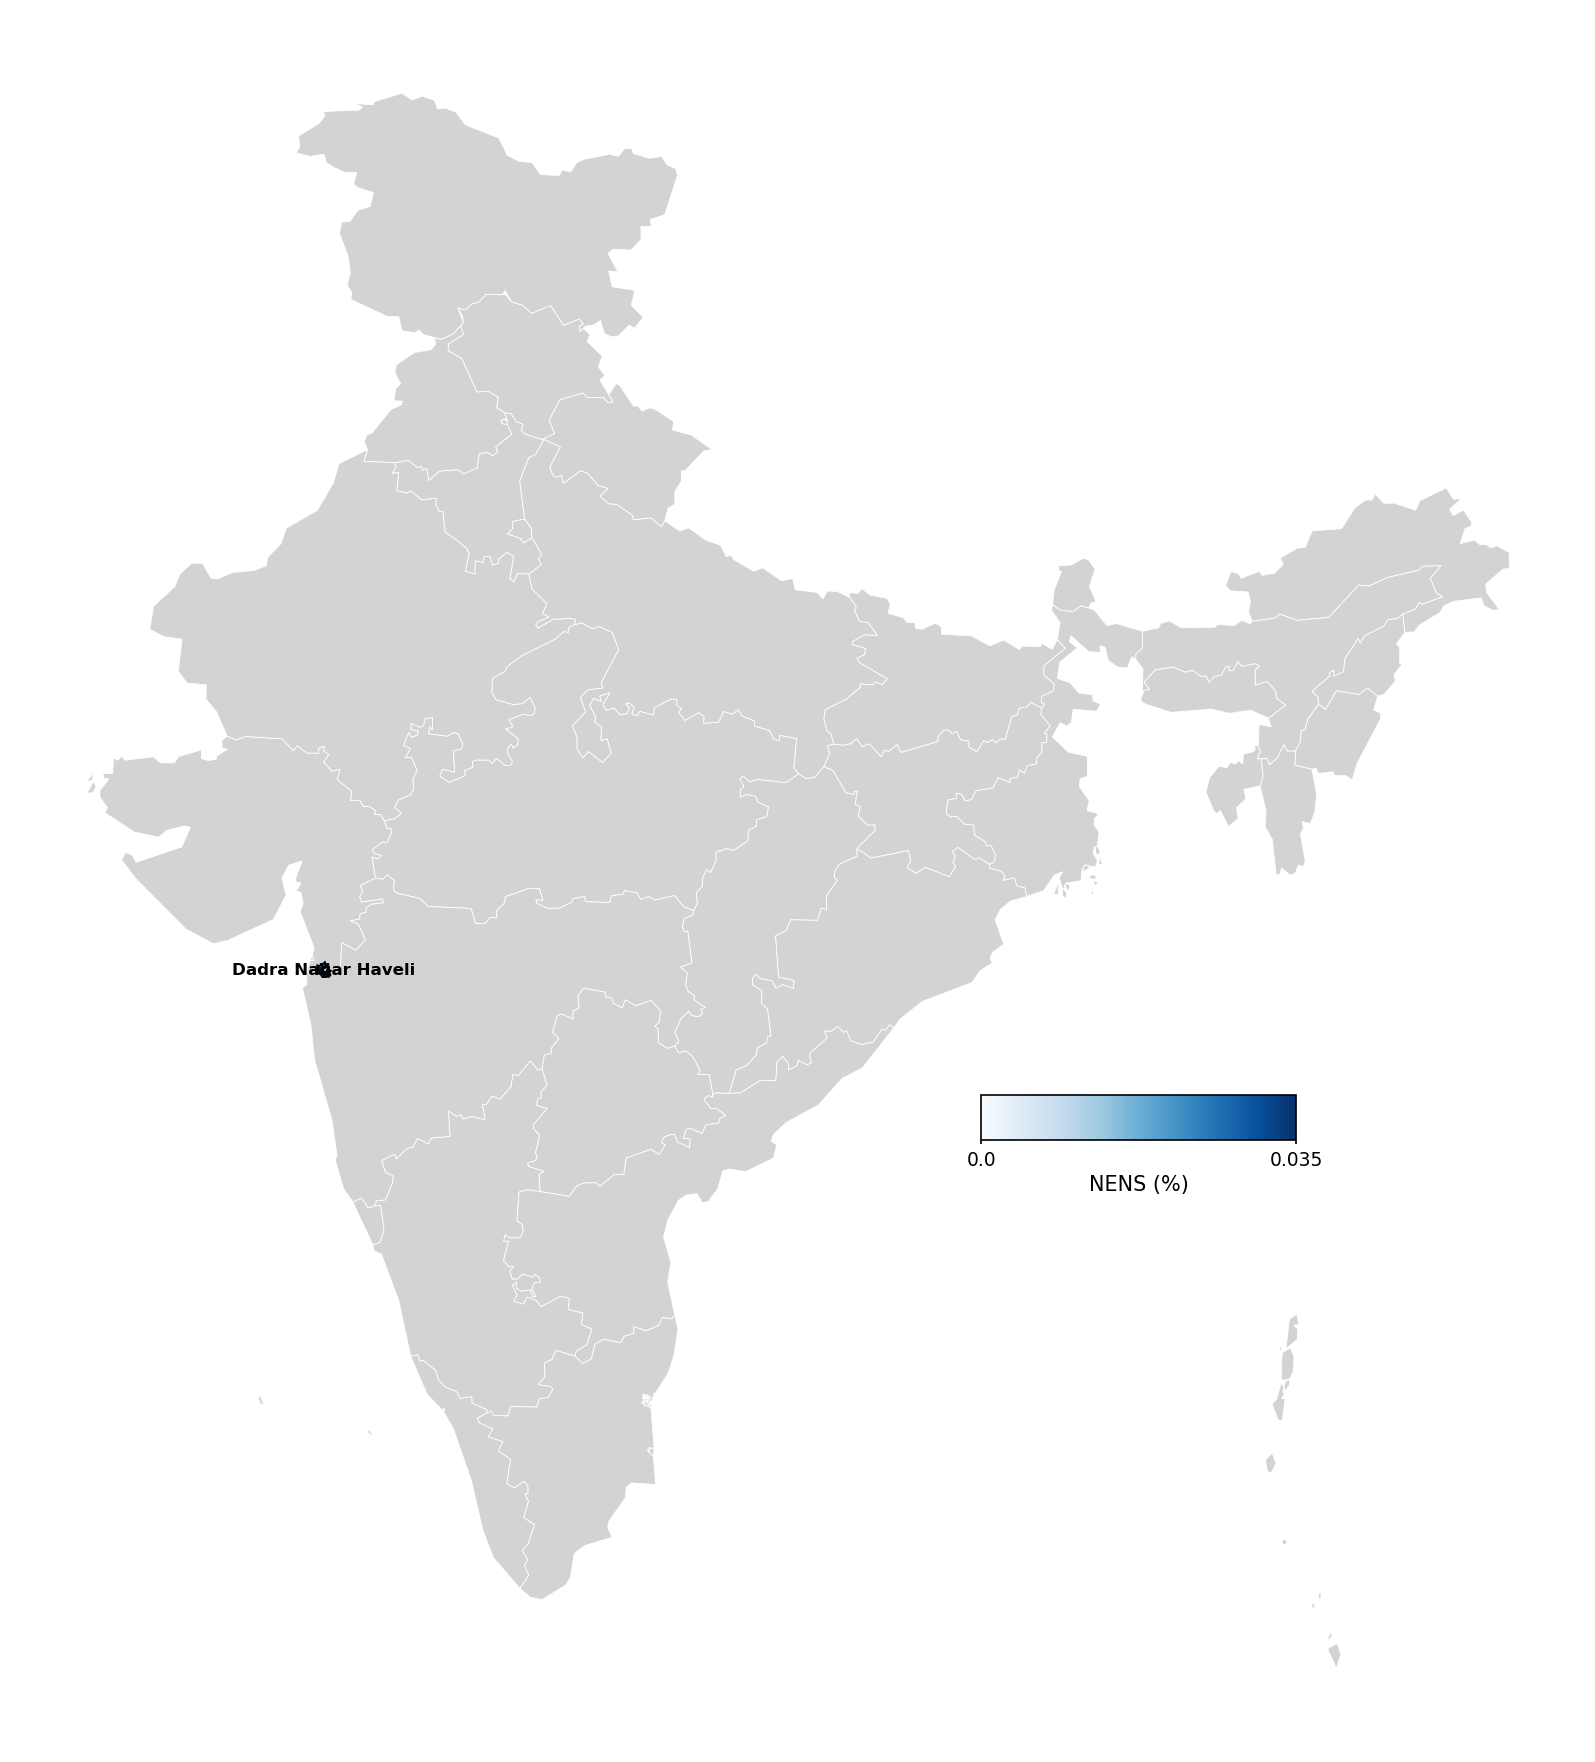

In [8]:

# --- Load shapefile ---
_india = gpd.read_file(path_to_data + "map/india/india-polygon.shp").to_crs("epsg:4326")
_india['geometry'] = _india['geometry'].apply(lambda geom: make_valid(geom) if geom else None)
_india = _india.dropna(subset=['geometry'])

# Harmonize naming
_india = _india.rename(columns={'st_nm': 'load_zone'})
_india['load_zone'] = (
    _india['load_zone']
    .str.replace(" ", "_")
    .str.replace("&", "and")
    .str.replace("_and_", "_", regex=False)
)

# Merge union for DNH + DD if both exist
if 35 in _india.index and 36 in _india.index:
    _india.loc[35, 'geometry'] = _india.loc[35, 'geometry'].union(_india.loc[36, 'geometry'])
    _india = _india.drop([36]).reset_index(drop=True)

# --- Merge with reliability metrics ---
india_metrics = _india.merge(metrics_df, on='load_zone', how='left')

# --- Apply violation flag for NENS ---
threshold = 0.05
india_metrics['violation'] = india_metrics['NENS (%)'] > threshold

# --- Clip extreme values for better color balance ---
india_metrics['NENS (%)'] = india_metrics['NENS (%)'].clip(
    upper=india_metrics['NENS (%)'].quantile(0.95)
)

# --- Define color normalization and colormap ---
cmap = get_cmap('Blues')    # blue gradient for NENS
vmin = float(np.nanmin(india_metrics['NENS (%)']))
vmax = float(np.nanmax(india_metrics['NENS (%)']))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 15), dpi=150)

# Base map (light grey background)
india_metrics.plot(ax=ax, color="lightgrey", edgecolor="white", lw=0.4, zorder=1)

# Violating states shaded by NENS intensity
india_metrics[india_metrics['violation']].plot(
    ax=ax,
    column='NENS (%)',
    cmap=cmap,
    norm=norm,
    edgecolor='black',
    linewidth=0.8,
    zorder=2
)

# --- Compact smooth colorbar (bottom right) ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []

# [x0, y0, width, height] → bottom right
cax = fig.add_axes([0.60, 0.38, 0.15, 0.02])
cb = plt.colorbar(sm, cax=cax, orientation='horizontal')

cb.set_label("NENS (%)", fontsize=10, labelpad=2)
cb.ax.tick_params(labelsize=9, length=2)
cb.set_ticks([vmin, vmax])
cb.set_ticklabels([f'{np.round(vmin, 3)}', f'{np.round(vmax, 3)}'])

# --- Labels for violating states ---
for _, row in india_metrics[india_metrics['violation']].iterrows():
    x, y = row['geometry'].centroid.x, row['geometry'].centroid.y
    ax.text(
        x, y, row['load_zone'].replace("_", " "),
        fontsize=8, ha='center', va='center',
        color='black', weight='bold', zorder=3
    )

# --- Clean up axes ---
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()

/tmp/ipykernel_1275677/4104095103.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  purples = get_cmap('Purples')


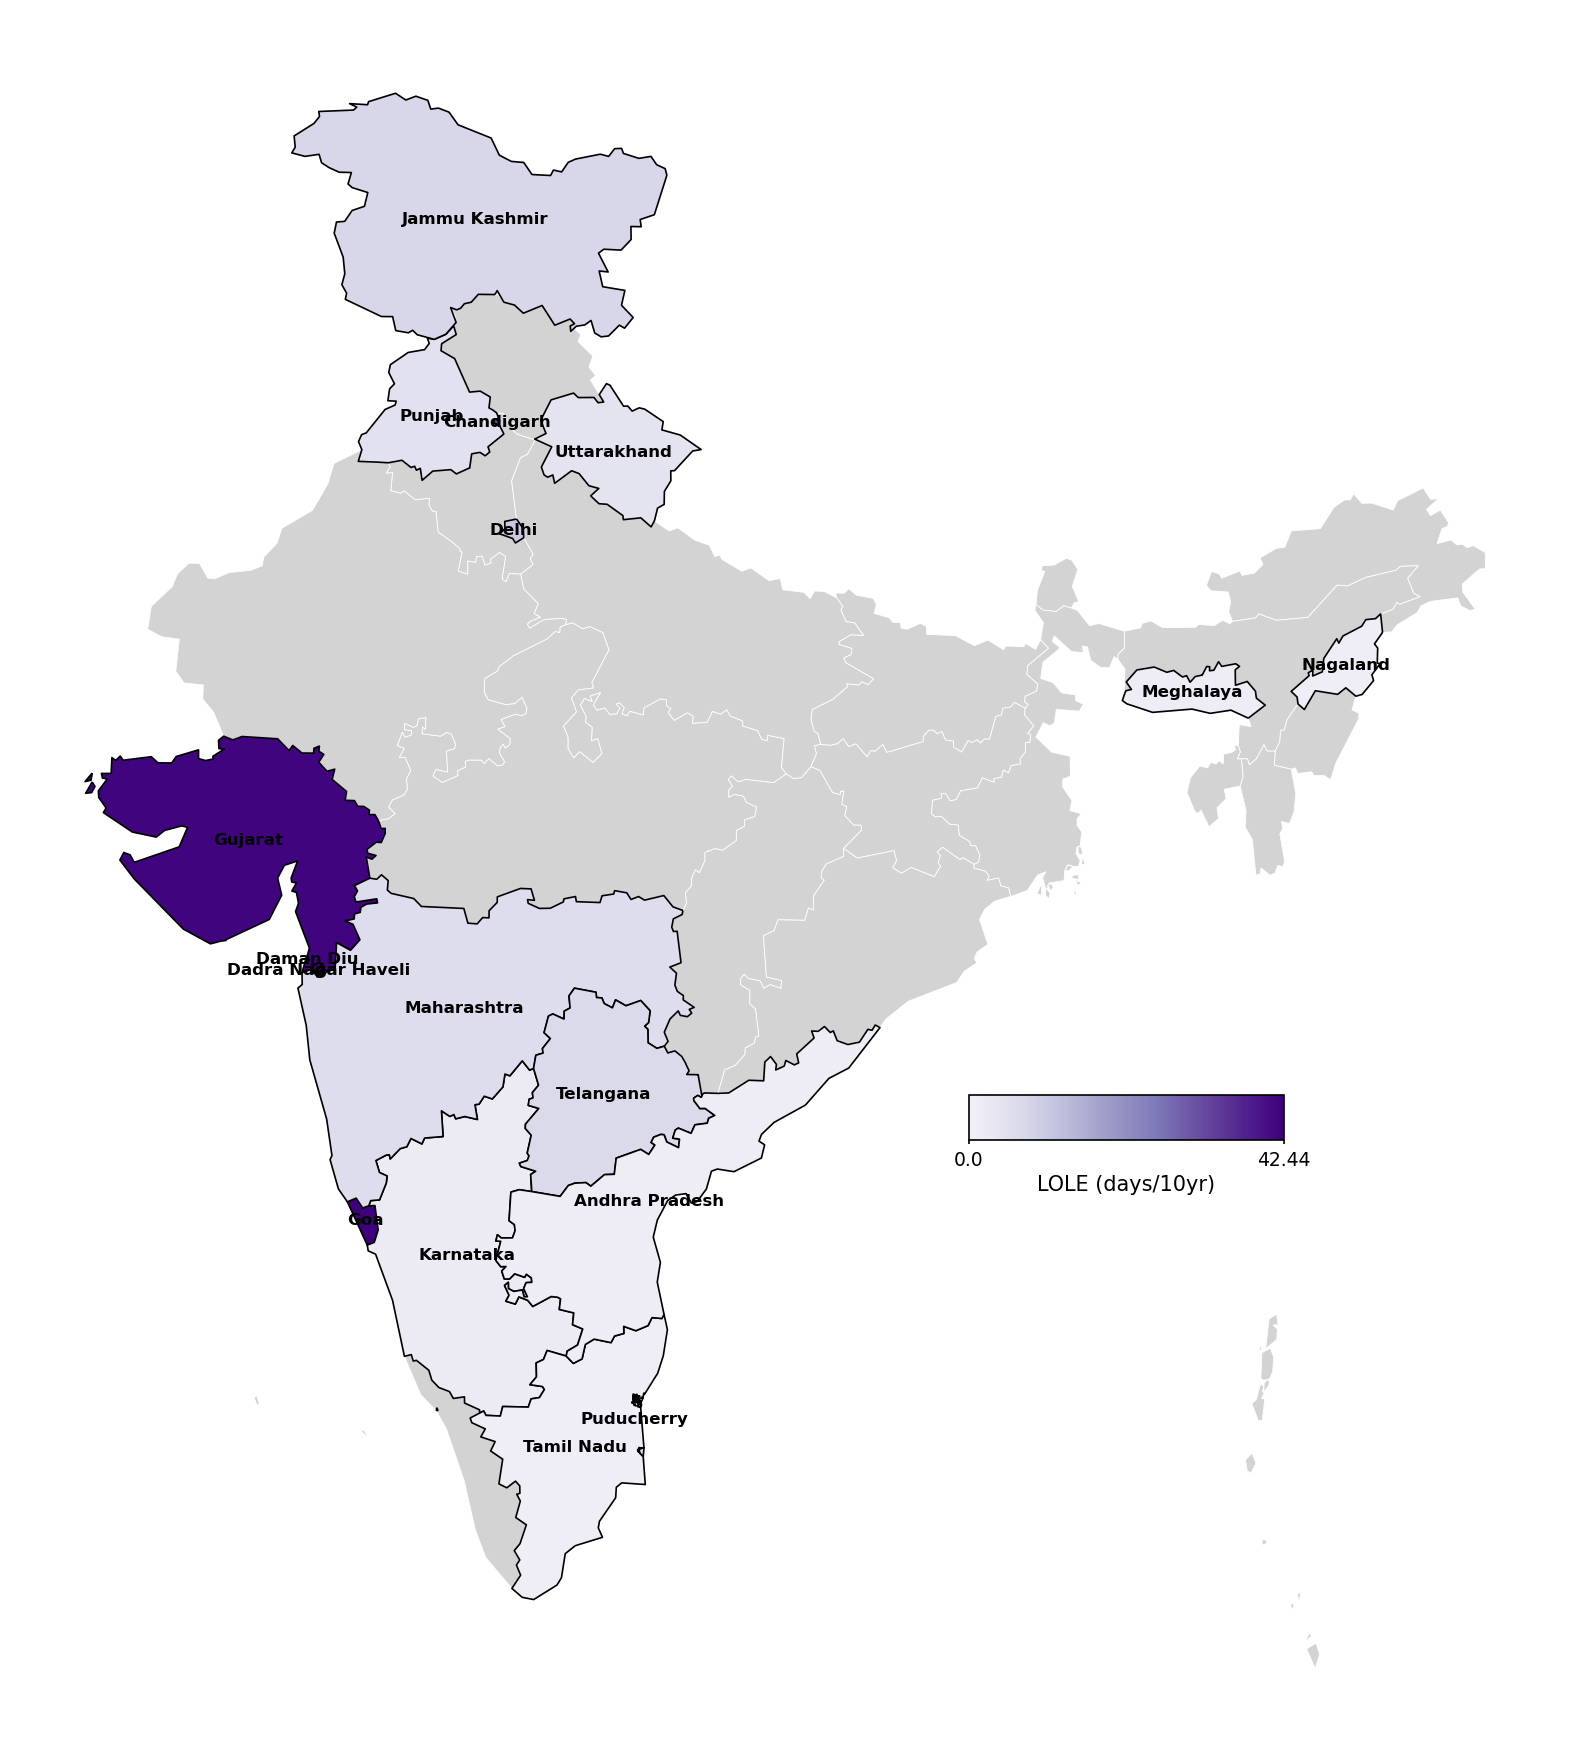

In [9]:
# --- Load shapefile ---
_india = gpd.read_file(path_to_data + "map/india/india-polygon.shp").to_crs("epsg:4326")
_india['geometry'] = _india['geometry'].apply(lambda geom: make_valid(geom) if geom else None)
_india = _india.dropna(subset=['geometry'])

# Harmonize naming
_india = _india.rename(columns={'st_nm': 'load_zone'})
_india['load_zone'] = (
    _india['load_zone']
    .str.replace(" ", "_")
    .str.replace("&", "and")
    .str.replace("_and_", "_", regex=False)
)

# Merge union for DNH + DD if both exist
if 35 in _india.index and 36 in _india.index:
    _india.loc[35, 'geometry'] = _india.loc[35, 'geometry'].union(_india.loc[36, 'geometry'])
    _india = _india.drop([36]).reset_index(drop=True)

# --- Merge with reliability metrics ---
india_metrics = _india.merge(metrics_df, on='load_zone', how='left')

# --- Apply violation flag (LOLE > 1 day/10yr) ---
threshold = 1.0
india_metrics['violation'] = india_metrics['LOLE (days/10yr)'] > threshold

# --- Clip extreme values for better visual balance ---
india_metrics['LOLE (days/10yr)'] = india_metrics['LOLE (days/10yr)'].clip(
    upper=india_metrics['LOLE (days/10yr)'].quantile(0.95)
)

# --- Define colormap and normalization ---
purples = get_cmap('Purples')
# optional: start from a slightly darker tone for better visibility
colors = purples(np.linspace(0.1, 1, 256))
cmap = LinearSegmentedColormap.from_list('custom_purples', colors)

vmin = float(np.nanmin(india_metrics['LOLE (days/10yr)']))
vmax = float(np.nanmax(india_metrics['LOLE (days/10yr)']))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 15), dpi=150)

# Base map (light grey background)
india_metrics.plot(ax=ax, color="lightgrey", edgecolor="white", lw=0.4, zorder=1)

# Violating states shaded by LOLE intensity
india_metrics[india_metrics['violation']].plot(
    ax=ax,
    column='LOLE (days/10yr)',
    cmap=cmap,
    norm=norm,
    edgecolor='black',
    linewidth=0.8,
    zorder=2
)

# --- Compact colorbar (bottom right) ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []
cax = fig.add_axes([0.60, 0.38, 0.15, 0.02])
cb = plt.colorbar(sm, cax=cax, orientation='horizontal')

cb.set_label("LOLE (days/10yr)", fontsize=10, labelpad=2)
cb.ax.tick_params(labelsize=9, length=2)
cb.set_ticks([vmin, vmax])
cb.set_ticklabels([f'{np.round(vmin, 2)}', f'{np.round(vmax, 2)}'])

# --- Labels for violating states ---
for _, row in india_metrics[india_metrics['violation']].iterrows():
    x, y = row['geometry'].centroid.x, row['geometry'].centroid.y
    ax.text(
        x, y, row['load_zone'].replace("_", " "),
        fontsize=8, ha='center', va='center',
        color='black', weight='bold', zorder=3
    )

# --- Clean up axes ---
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()

# Reliability Assesment

## Processing state-level metrics for every interation (W, H, and A combinations)

In [10]:
df = df_load_.copy()

# --- flags & helpers ---
df['is_lol']     = df['unserved_energy'] > tau # 1MW threshold for LOL event
df['date']       = df['timestamp'].dt.date
df['hrs_in_tmp'] = 1

metrics, events_stats = [], []
group_cols = ['load_zone', 'W', 'H', 'A']
HOURS_PER_YEAR = 8760.0  

for (zone, w, h, a), sub in df.groupby(group_cols):
    hrs_run = sub['hrs_in_tmp'].sum()
    n_years = hrs_run / HOURS_PER_YEAR if hrs_run > 0 else np.nan

    # --- energy & tallies (MW → MWh by multiplying hrs_in_tmp) ---
    total_lol_hours   = int(sub['is_lol'].sum())
    total_unserved_MWh = float((sub['unserved_energy'] * sub['hrs_in_tmp']).sum())
    total_energy_MWh   = float((sub['static_load']     * sub['hrs_in_tmp']).sum())
    days_with_lol      = int(sub.groupby('date')['is_lol'].max().sum())

    # --- annualized metrics ---
    LOLH   = total_lol_hours / n_years if np.isfinite(n_years) else np.nan
    EUE_MWh = total_unserved_MWh / n_years if np.isfinite(n_years) else np.nan
    EUE_GWh = EUE_MWh / 1000 if np.isfinite(EUE_MWh) else np.nan
    LOLE_10yr = (days_with_lol / n_years * 10) if np.isfinite(n_years) else np.nan
    LOLP   = total_lol_hours / hrs_run if hrs_run > 0 else np.nan
    annual_energy = total_energy_MWh / n_years if np.isfinite(n_years) else np.nan
    NENS   = 100 * EUE_MWh / annual_energy if (annual_energy and np.isfinite(annual_energy)) else np.nan

    metrics.append({
        'load_zone':        zone,
        'W':                w, 'H': h, 'A': a,
        'LOLH (hrs/yr)':    LOLH,
        'EUE (GWh/yr)':     EUE_GWh,
        'LOLE (days/10yr)': LOLE_10yr,
        'LOLP (fraction)':  LOLP,
        'NENS (%)':         NENS
    })

    # --- event‐level stats ---
    run = sub.sort_values('timestamp').copy()
    run['event_start'] = (~run['is_lol'].shift(fill_value=False)) & run['is_lol']
    run['event_id']    = run['event_start'].cumsum()

    durations = run[run['is_lol']].groupby('event_id').size()
    events_stats.append({
        'load_zone':              zone,
        'W': w, 'H': h, 'A': a,
        'num_LOL_events':         int(durations.count()),
        'total_LOL_duration_hrs': int(durations.sum())
    })

# Build DataFrames
metrics_per_zone_df = pd.DataFrame(metrics)
lol_events_df       = pd.DataFrame(events_stats)


print(lol_events_df)


          load_zone   W   H   A  num_LOL_events  total_LOL_duration_hrs
0    Andhra_Pradesh   1   1   1               0                       0
1    Andhra_Pradesh  10  10  10               0                       0
2    Andhra_Pradesh  11  11  11               0                       0
3    Andhra_Pradesh  12  12  12               0                       0
4    Andhra_Pradesh  13  13  13               0                       0
..              ...  ..  ..  ..             ...                     ...
625     West_Bengal   5   5   5               0                       0
626     West_Bengal   6   6   6               0                       0
627     West_Bengal   7   7   7               0                       0
628     West_Bengal   8   8   8               0                       0
629     West_Bengal   9   9   9               0                       0

[630 rows x 6 columns]


# Loss-of-load probability heatmap

In [11]:
df = df_load_.copy()

tau = 1.
df['lol'] = df['unserved_energy'] > tau

df = df[['timepoint', 'load_zone', 'lol']]

df = df.groupby(['timepoint', 'load_zone']).agg({'lol': 'sum'}).reset_index(drop = False)
df = df.groupby(['timepoint']).agg({'lol': 'sum'}).reset_index(drop = False)

df['interval'] = df['timepoint'].apply(lambda x: int(str(x)[-2:]))
df['month']    = df['timepoint'].apply(lambda x: int(str(x)[-6:-4]))

df = df[['month', 'interval', 'lol']]
df = df.groupby(['month', 'interval']).agg({'lol': 'sum'}).reset_index(drop = False)
print(df)

months_    = np.array([4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3])
intervals_ = df['interval'].unique()
LOLP_      = np.zeros((months_.shape[0], intervals_.shape[0]))

for m, month in zip(range(months_.shape[0]), months_):
    for interval in intervals_:
        print(df.loc[(df['month'] == month) & (df['interval'] == interval), 'lol'].to_numpy()[0], calendar.monthrange(2001, month)[1])
        LOLP_[m, interval - 1] = df.loc[(df['month'] == month) & (df['interval'] == interval), 'lol'].to_numpy()[0]/(18*calendar.monthrange(2001, month)[1])

print(LOLP_.max(), LOLP_.min())

     month  interval  lol
0        1         1    0
1        1         2    0
2        1         3    0
3        1         4    0
4        1         5    0
..     ...       ...  ...
283     12        20   11
284     12        21    6
285     12        22    4
286     12        23    0
287     12        24    0

[288 rows x 3 columns]
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
1 30
3 30
7 30
5 30
4 30
3 30
28 30
1 30
1 30
0 30
0 30
0 30
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
1 31
2 31
1 31
1 31
6 31
7 31
4 31
5 31
24 31
0 31
0 31
0 31
0 31
0 31
0 30
0 30
0 30
0 30
1 30
0 30
2 30
3 30
1 30
1 30
1 30
0 30
1 30
2 30
21 30
29 30
12 30
5 30
8 30
0 30
0 30
2 30
0 30
0 30
12 31
12 31
10 31
10 31
11 31
5 31
14 31
6 31
0 31
0 31
2 31
3 31
1 31
3 31
8 31
6 31
1 31
12 31
25 31
13 31
12 31
12 31
10 31
12 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
4 31
16 31
14 31
13 31
17 31
24 31
15 31
4 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 30
1 30
0 30
0 30
1 30
2 30
9 30
11 30

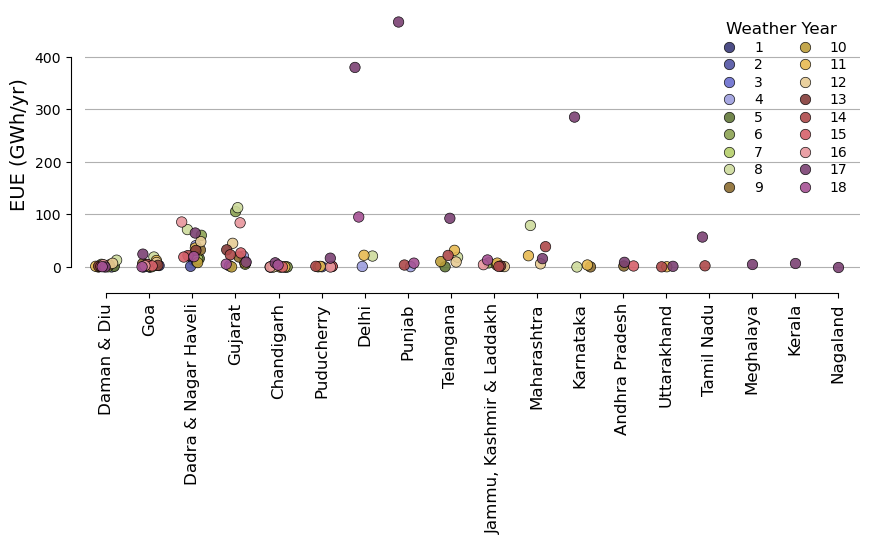

In [12]:
def plot_metrics(ax, df, metric, group_cols = ('W')): 
    
    # 1) remove Bhutan entirely
    df = df[df['load_zone'] != 'Bhutan'].copy()
    df = df.loc[df[metric] > 0.] 

    # 2) define mapping for special zones
    display_map = {'Jammu_Kashmir': 'Jammu, Kashmir & Laddakh',
                   'Dadra_Nagar_Haveli': 'Dadra & Nagar Haveli',
                   'Daman_Diu': 'Daman & Diu'}

    # 3) determine unique zones (in order of appearance)
    zones    = df['load_zone'].unique()
    zone_pos = {zone: idx for idx, zone in enumerate(zones)}

    
    # 4) build list of display labels in the same order
    zone_labels = [display_map.get(z, z.replace('_', ' ')) for z in zones]

    x_ = np.arange(zones.shape[0])

    # for x, zone in zip(x_, zones):
    #     y = df.loc[df['load_zone'] == zone, metric].to_numpy()
    #     print(y.shape)


    ax.set_xticks(x_, list(zone_pos.values()))

    sns.stripplot(data      = df,
                  x         = "load_zone",
                  y         = metric, 
                  size      = "s", 
                  hue       = "iteration",
                  s         = 7.5,
                  alpha     = 0.9, 
                  edgecolor = 'k',
                  linewidth        = .5,
                  zorder    = 9, 
                  jitter    = .25,
                  palette   = "tab20b")

    # set the custom ticks & labels

    ax.set_ylabel(metric, fontsize = 14)
    ax.set_xlabel('', fontsize = 14)

    # Add a legend
    ax.legend(
        title = 'Weather Year',
        bbox_to_anchor = (1., 1), # Position legend outside
        #loc='upper right',
        fontsize=10, 
        labelspacing = .25,
        title_fontsize=12, 
        frameon=False, ncol = 2)
    
    # Add Y-axis gridlines only
    #ax.grid(True, axis='y', linestyle='--', alpha=1.0, linewidth=1.0, zorder=1)
    ax.grid(axis = 'y')

    sns.despine(offset=10, trim=True)
    ax.set_xlim(-.5, len(list(zone_pos.values())) - .5)
    
    ax.set_xticklabels(zone_labels, 
                       rotation=90, 
                       ha='center', 
                       fontsize=12) 

df = metrics_per_zone_df.copy()
df['iteration'] = df['W']
df['iteration'] = df['iteration'].astype(int)
df              = df.sort_values(by='iteration')
df['iteration'] = df['iteration'].astype(str)

df_sum=df.groupby('load_zone').agg({'EUE (GWh/yr)': 'sum'}).reset_index(drop = False)


fig, ax = plt.subplots(figsize = (10., 3.5))
plot_metrics(ax, df, metric = 'EUE (GWh/yr)')

# Ensure tight_layout is called after all elements are added for proper spacing
#plt.tight_layout(rect = [0, 0, 0.88, 1]) # Adjusted rect slightly for legend

plt.savefig(path_to_save_images + '/zone-level_EUE.png',
            bbox_inches = 'tight',
            dpi         = 600)

plt.savefig(path_to_save_images + '/zone-level_EUE.pdf',
            bbox_inches = 'tight',
            dpi         = 600)

plt.show()

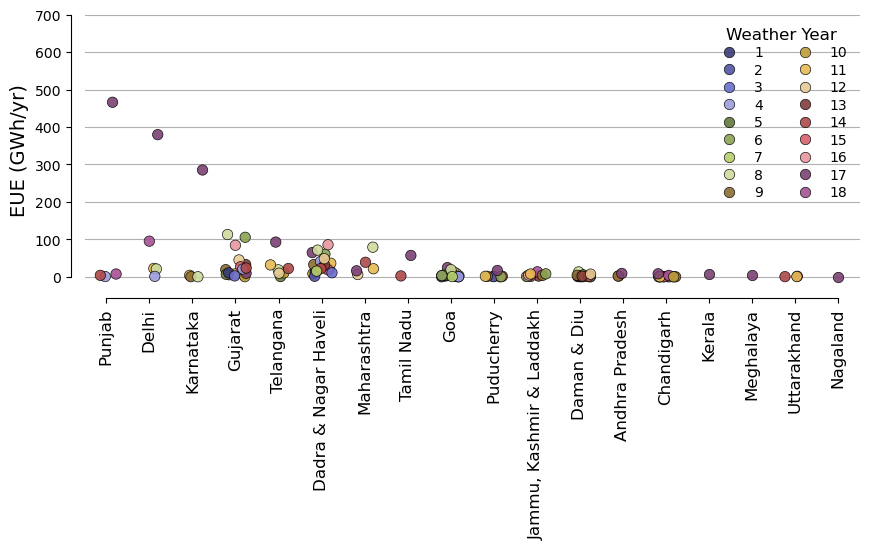

In [13]:

def plot_metrics(ax, df, metric, group_cols=('W'), ylim=1000):
    # 1) remove Bhutan entirely
    df = df[df['load_zone'] != 'Bhutan'].copy()
    df = df.loc[df[metric] > 0.].copy()

    # 2) define mapping for special zones
    display_map = {
        'Jammu_Kashmir': 'Jammu, Kashmir & Laddakh',
        'Dadra_Nagar_Haveli': 'Dadra & Nagar Haveli',
        'Daman_Diu': 'Daman & Diu'
    }

    # 3) sort zones by descending max(EUE)
    zone_order = (
        df.groupby('load_zone', as_index=False)[metric]
          .max()
          .sort_values(metric, ascending=False)['load_zone']
          .tolist()
    )
    df['load_zone'] = pd.Categorical(df['load_zone'],
                                     categories=zone_order,
                                     ordered=True)
    df = df.sort_values('load_zone')

    # 4) order weather years numerically
    if 'iteration' in df.columns:
        iter_order = sorted(df['iteration'].unique(), key=lambda x: int(x))
    else:
        iter_order = None

    # 5) human-readable x labels
    zone_labels = [display_map.get(z, z.replace('_', ' ')) for z in zone_order]

    # 6) plot
    sns.stripplot(
        data=df,
        x="load_zone",
        y=metric,
        hue="iteration",
        hue_order=iter_order,   # <--- ensures numeric order in legend
        s=7.5,
        alpha=0.9,
        edgecolor='k',
        linewidth=.5,
        jitter=.25,
        palette="tab20b",       # colors unchanged
        zorder=9
    )

    # 7) axis labels and legend
    ax.set_ylabel(metric, fontsize=14)
    ax.set_ylim(-20, ylim)
    ax.set_xlabel('', fontsize=14)

    ax.legend(
        title='Weather Year',
        bbox_to_anchor=(1., 1),
        fontsize=10,
        labelspacing=.25,
        title_fontsize=12,
        frameon=False,
        ncol=2
    )

    ax.grid(axis='y')
    sns.despine(offset=10, trim=True)
    ax.set_xlim(-.5, len(zone_order) - .5)
    
    ax.set_xticklabels(zone_labels, rotation=90, ha='center', fontsize=12)


# === Data prep (same as before) ===
df = metrics_per_zone_df.copy()
df['iteration'] = df['W'].astype(int)
df = df.sort_values(by='iteration')
df['iteration'] = df['iteration'].astype(str)

# === Plot ===
fig, ax = plt.subplots(figsize=(10., 3.5))
plot_metrics(ax, df, metric='EUE (GWh/yr)', ylim=700)

plt.savefig(path_to_save_images + '/zone-level_EUE_descendingMax_sortedLegend.png',
            bbox_inches='tight', dpi=600)
plt.savefig(path_to_save_images + '/zone-level_EUE_descendingMax_sortedLegend.pdf',
            bbox_inches='tight', dpi=600)
plt.show()

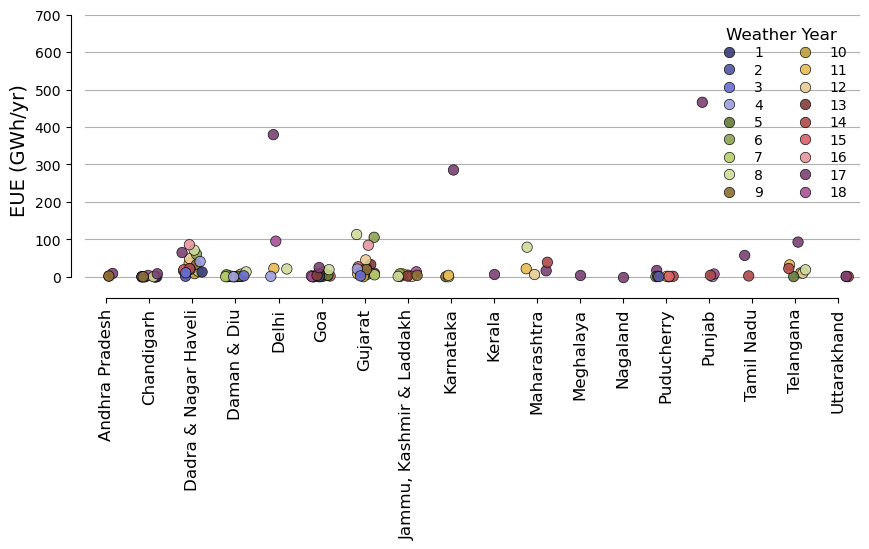

In [14]:


def plot_metrics(ax, df, metric, group_cols=('W'), ylim=1000):
    # 1) remove Bhutan entirely
    df = df[df['load_zone'] != 'Bhutan'].copy()
    df = df.loc[df[metric] > 0.].copy()

    # 2) define mapping for special zones
    display_map = {
        'Jammu_Kashmir': 'Jammu, Kashmir & Laddakh',
        'Dadra_Nagar_Haveli': 'Dadra & Nagar Haveli',
        'Daman_Diu': 'Daman & Diu'
    }

    # 3) --- arrange zones alphabetically ---
    zone_order = sorted(df['load_zone'].unique(), key=lambda z: z.lower())
    df['load_zone'] = pd.Categorical(df['load_zone'],
                                     categories=zone_order,
                                     ordered=True)
    df = df.sort_values('load_zone')

    # 4) order weather years numerically
    if 'iteration' in df.columns:
        iter_order = sorted(df['iteration'].unique(), key=lambda x: int(x))
    else:
        iter_order = None

    # 5) human-readable x-labels
    zone_labels = [display_map.get(z, z.replace('_', ' ')) for z in zone_order]

    # 6) plot
    sns.stripplot(
        data=df,
        x="load_zone",
        y=metric,
        hue="iteration",
        hue_order=iter_order,     # keeps weather years sorted numerically
        s=7.5,
        alpha=0.9,
        edgecolor='k',
        linewidth=.5,
        jitter=.25,
        palette="tab20b",
        zorder=9
    )

    # 7) axis labels, limits, and legend
    ax.set_ylabel(metric, fontsize=14)
    ax.set_ylim(-20, ylim)
    ax.set_xlabel('', fontsize=14)

    ax.legend(
        title='Weather Year',
        bbox_to_anchor=(1., 1),
        fontsize=10,
        labelspacing=.25,
        title_fontsize=12,
        frameon=False,
        ncol=2
    )

    ax.grid(axis='y')
    sns.despine(offset=10, trim=True)
    ax.set_xlim(-.5, len(zone_order) - .5)
    ax.set_xticklabels(zone_labels, rotation=90, ha='center', fontsize=12)


# === Data prep (same as before) ===
df = metrics_per_zone_df.copy()
df['iteration'] = df['W'].astype(int)
df = df.sort_values(by='iteration')
df['iteration'] = df['iteration'].astype(str)

# === Plot ===
fig, ax = plt.subplots(figsize=(10., 3.5))
plot_metrics(ax, df, metric='EUE (GWh/yr)', ylim=700)

plt.savefig(path_to_save_images + '/zone-level_EUE_alphabetical.png',
            bbox_inches='tight', dpi=600)
plt.savefig(path_to_save_images + '/zone-level_EUE_alphabetical.pdf',
            bbox_inches='tight', dpi=600)
plt.show()

{'Punjab': 0, 'Delhi': 1, 'Karnataka': 2, 'Gujarat': 3, 'Telangana': 4, 'Dadra_Nagar_Haveli': 5, 'Maharashtra': 6, 'Tamil_Nadu': 7, 'Goa': 8, 'Puducherry': 9, 'Jammu_Kashmir': 10, 'Daman_Diu': 11, 'Andhra_Pradesh': 12, 'Chandigarh': 13, 'Kerala': 14, 'Meghalaya': 15, 'Uttarakhand': 16, 'Nagaland': 17}


/tmp/ipykernel_1275677/819425864.py:56: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


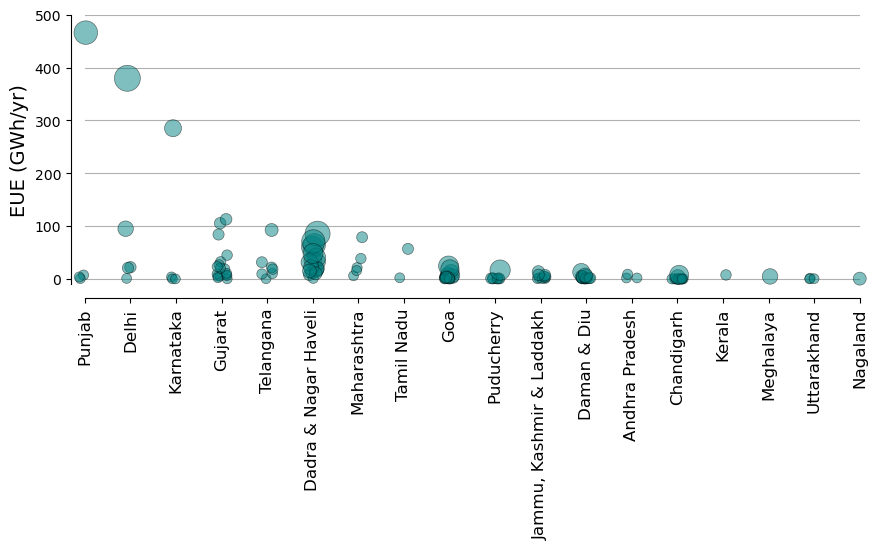

In [15]:

def plot_metrics(ax, df, metric, group_cols=('W'), ylim = 1000, legend = False):
   
    df = df[df['load_zone'] != 'Bhutan'].copy()
    df = df.loc[df[metric] > 0.].copy()

 
    display_map = {
        'Jammu_Kashmir': 'Jammu, Kashmir & Laddakh',
        'Dadra_Nagar_Haveli': 'Dadra & Nagar Haveli',
        'Daman_Diu': 'Daman & Diu'
    }


    zone_order = (
        df.groupby('load_zone', as_index=False)[metric]
          .max()
          .sort_values(metric, ascending=False)['load_zone']
          .tolist()
    )

    df['load_zone'] = pd.Categorical(df['load_zone'],
                                     categories=zone_order,
                                     ordered=True)
    
    df = df.sort_values('load_zone')

   
    if 'iteration' in df.columns:
        iter_order = sorted(df['iteration'].unique(), key=lambda x: int(x))
    else:
        iter_order = None


    #zone_labels = [display_map.get(z, z.replace('_', ' ')) for z in df["load_zone"].unique()]
    # sns.stripplot(
    #     data=df,
    #     x="load_zone",
    #     y=metric,
    #     hue="iteration",
    #     hue_order=iter_order,   
    #     s=7.5,
    #     alpha=0.9,
    #     edgecolor='k',
    #     linewidth=.5,
    #     jitter=.25,
    #     palette="tab20b",       
    #     zorder=9
    # )    

    positions = {cat: i for i, cat in enumerate(df["load_zone"].unique())}
    x_jitter = [positions[z] + np.random.uniform(-0.125, 0.125) for z in df["load_zone"]]
    print(positions)
    # Scale NENS (%) for marker area
    sizes = 50 + 300 * (df["NENS (%)"] / df["NENS (%)"].max())

    scatter = ax.scatter(
        x_jitter,
        df[metric],
        s=sizes,                             # variable marker size
        c='teal',
        cmap="tab20b",
        alpha=0.5,
        edgecolors='k',
        linewidth=0.5,
        clip_on=False,
        zorder=9
    )

    ax.set_ylabel(metric, fontsize=14)
    
    ax.set_xlabel('', fontsize=14)
    if legend:
        ax.legend(
            title='Weather Year',
            bbox_to_anchor=(1., 1),
            fontsize=10,
            labelspacing=.25,
            title_fontsize=12,
            frameon=False,
            ncol=2
        )


    ax.grid(axis='y')
    ax.set_xlim(0, len(df["load_zone"].unique()) - 1)
    ax.set_ylim(-10, ylim)

    sns.despine(offset=10, trim=False)

    ax.set_xticks([i for i, z in enumerate(df["load_zone"].unique())])

    ax.set_xticklabels([display_map.get(z, z.replace('_', ' ')) for i, z in enumerate(df["load_zone"].unique())], rotation=90, ha='center', fontsize=12)


# === Data prep (same as before) ===
df = metrics_per_zone_df.copy()
df['iteration'] = df['W'].astype(int)
df = df.sort_values(by='iteration')
df['iteration'] = df['iteration'].astype(str)

# === Plot ===
fig, ax = plt.subplots(figsize=(10., 3.5))
plot_metrics(ax, df, metric='EUE (GWh/yr)', ylim = 500)

plt.savefig(path_to_save_images + '/zone-level_EUE_descendingMax_sortedLegend.png',
            bbox_inches='tight', dpi=600)
plt.savefig(path_to_save_images + '/zone-level_EUE_descendingMax_sortedLegend.pdf',
            bbox_inches='tight', dpi=600)
plt.show()

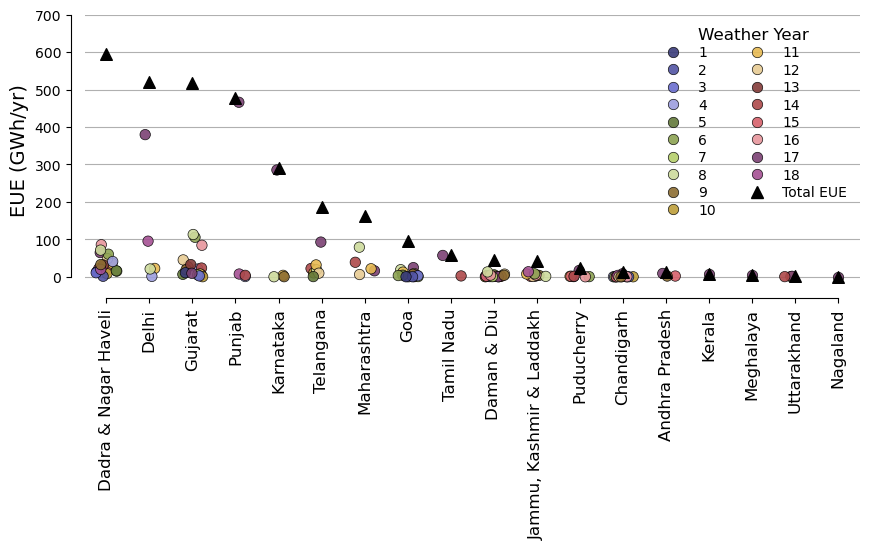

In [16]:
def plot_metrics(ax, df, metric, group_cols=('W'), ylim=1000): 
    df = df[df['load_zone'] != 'Bhutan'].copy()
    df = df.loc[df[metric] > 0.].copy()

    display_map = {'Jammu_Kashmir': 'Jammu, Kashmir & Laddakh',
                   'Dadra_Nagar_Haveli': 'Dadra & Nagar Haveli',
                   'Daman_Diu': 'Daman & Diu'}

    if 'iteration' in df.columns:
        unique_iters = sorted(df['iteration'].unique(), key=lambda x: int(x))
    else:
        unique_iters = None

    zones = df['load_zone'].unique()
    zone_pos = {zone: idx for idx, zone in enumerate(zones)}
    zone_labels = [display_map.get(z, z.replace('_', ' ')) for z in zones]

    x_ = np.arange(zones.shape[0])
    ax.set_xticks(x_, list(zone_pos.values()))

    sns.stripplot(
        data=df,
        x="load_zone",
        y=metric,
        hue="iteration",
        hue_order=unique_iters,
        s=7.5, alpha=0.9, edgecolor='k', linewidth=.5,
        jitter=.25, palette="tab20b", zorder=9
    )

    ax.set_ylabel(metric, fontsize=14)
    ax.set_ylim(-20, ylim)
    ax.set_xlabel('', fontsize=14)
    ax.legend(title='Weather Year', bbox_to_anchor=(1., 1),
              fontsize=10, labelspacing=.25, title_fontsize=12,
              frameon=False, ncol=2)
    ax.grid(axis='y')
    sns.despine(offset=10, trim=True)
    ax.set_xlim(-.5, len(list(zone_pos.values())) - .5)
    ax.set_xticklabels(zone_labels, rotation=90, ha='center', fontsize=12)




# ===== prepare data =====
metric = 'EUE (GWh/yr)'
df_plot = metrics_per_zone_df.copy()
df_plot['iteration'] = df_plot['W'].astype(int)
df_plot = df_plot.sort_values('iteration')
df_plot['iteration'] = df_plot['iteration'].astype(str)

zones_shown = df_plot.loc[
    (df_plot['load_zone'] != 'Bhutan') &
    (pd.to_numeric(df_plot[metric], errors='coerce') > 0),
    'load_zone'
].unique()

src = metrics_per_zone_df.loc[metrics_per_zone_df['load_zone'].isin(zones_shown),
                              ['load_zone', metric]].copy()
src[metric] = pd.to_numeric(src[metric], errors='coerce').fillna(0.0)
sum_tbl = (src.groupby('load_zone', as_index=False)[metric].sum()
              .rename(columns={metric: 'total_eue'}))

zone_order = sum_tbl.sort_values('total_eue', ascending=False)['load_zone'].tolist()

df_plot = df_plot[df_plot['load_zone'].isin(zone_order)].copy()
df_plot['load_zone'] = pd.Categorical(df_plot['load_zone'], categories=zone_order, ordered=True)
df_plot = df_plot.sort_values('load_zone')

y_tri = sum_tbl.set_index('load_zone').loc[zone_order, 'total_eue'].to_numpy()

# ===== plot =====
fig, ax = plt.subplots(figsize=(10., 3.5))
plot_metrics(ax, df_plot, metric=metric,ylim=700)

# overlay triangles
tri = ax.scatter(np.arange(len(zone_order)), y_tri,
                 marker='^', color='black', s=70, zorder=12)

# # --- adjust y-limits so triangles aren’t cropped ---
# ymin, ymax = ax.get_ylim()
# new_ymax = max(ymax, y_tri.max() * 1.05)  # add 5% headroom
# ax.set_ylim(ymin, new_ymax)

# single legend entry for triangles
handles, labels = ax.get_legend_handles_labels()
# order weather years numerically
ordered_pairs = sorted([(h, l) for h, l in zip(handles, labels)
                        if l.isdigit()], key=lambda x: int(x[1]))
handles = [p[0] for p in ordered_pairs]
labels = [p[1] for p in ordered_pairs]
# add triangle entry last
handles.append(plt.Line2D([0], [0], color='black', marker='^', linestyle='',
                          markersize=8, label='Total EUE'))
labels.append('Total EUE')
ax.legend(handles=handles, labels=labels,
          title='Weather Year',
          bbox_to_anchor=(1., 1),
          fontsize=10, labelspacing=.25,
          title_fontsize=12,
          frameon=False, ncol=2)

plt.show()

# Load and processing project timepoints

In [17]:
# Load and processing project timepoints
def _processing_project_timepoints(scenarios_):

    dfs_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, dirnames, filenames in os.walk(path_to_scenario):
            # Processing scenarios results folder only
            if dirpath.split('/')[-1] == 'results':
                print(scenario)

                df_ = pd.read_csv(os.path.join(dirpath, 'project_timepoint.csv'), low_memory = False)

                df_ = df_[['timepoint', 
                           'technology', 
                           'load_zone', 
                           'power_mw',
                           'capacity_mw',
                           'starting_energy_mwh', 
                           'charge_mw', 
                           'discharge_mw', 
                           'total_curtailment_mw',
                           'availability_derate']] # availability_derate

                df_ = df_.groupby(['timepoint',
                                   'technology', 
                                   'load_zone']).agg({'power_mw': 'sum',
                                                      'total_curtailment_mw': 'sum',
                                                      'starting_energy_mwh': 'sum',
                                                      'charge_mw': 'sum',
                                                      'discharge_mw': 'sum',
                                                      'capacity_mw' : 'sum',
                                                      'availability_derate': 'mean'}).reset_index(drop = False)

                df_ = df_.rename(columns = {'total_curtailment_mw': 'curtailment_mw',
                                            'starting_energy_mwh': 'energy_mwh'})

                # Add iteration descriptors to dataframe
                df_['W'] = dirpath.split('/')[-4].split('_')[-1]
                df_['H'] = dirpath.split('/')[-3].split('_')[-1]
                df_['A'] = dirpath.split('/')[-2].split('_')[-1]
                
                dfs_.append(df_)

    return pd.concat(dfs_).reset_index(drop = True)

# Group project timepoints by technology
def _group_technology_in_project_timepoints(df_, tech_labels_):

    for group in tech_labels_['group'].unique():
        df_.loc[df_['technology'].isin(tech_labels_.loc[tech_labels_['group'] == group, 'technology']), 'technology'] = group
        
    return df_.groupby(['timepoint',
                        'technology', 
                        'load_zone',
                        'W','H','A']).agg({'power_mw': 'sum',
                                           'capacity_mw' : 'sum',
                                           'curtailment_mw': 'sum',
                                           'energy_mwh': 'sum',
                                           'charge_mw': 'sum',
                                           'discharge_mw': 'sum',
                                           'availability_derate': 'mean'}).reset_index(drop = False)

# Load, process and group project timepoints
df_dispatch_ = _processing_project_timepoints(scenarios_)
df_dispatch_ = _group_technology_in_project_timepoints(df_dispatch_, tech_labels_)
print(df_dispatch_.head())

pier_no_prm_no_ccap_2040_1
pier_no_prm_no_ccap_2040_2
pier_no_prm_no_ccap_2040_3
pier_no_prm_no_ccap_2040_4
pier_no_prm_no_ccap_2040_5
pier_no_prm_no_ccap_2040_6
pier_no_prm_no_ccap_2040_7
pier_no_prm_no_ccap_2040_8
pier_no_prm_no_ccap_2040_9
pier_no_prm_no_ccap_2040_10
pier_no_prm_no_ccap_2040_11
pier_no_prm_no_ccap_2040_12
pier_no_prm_no_ccap_2040_13
pier_no_prm_no_ccap_2040_14
pier_no_prm_no_ccap_2040_15
pier_no_prm_no_ccap_2040_16
pier_no_prm_no_ccap_2040_17
pier_no_prm_no_ccap_2040_18
    timepoint technology       load_zone   W   H   A     power_mw  \
0  2040040101    Battery  Andhra_Pradesh   1   1   1  -495.379236   
1  2040040101    Battery  Andhra_Pradesh  10  10  10  -780.431606   
2  2040040101    Battery  Andhra_Pradesh  11  11  11     0.000000   
3  2040040101    Battery  Andhra_Pradesh  12  12  12 -1661.835078   
4  2040040101    Battery  Andhra_Pradesh  13  13  13     0.000000   

   capacity_mw  curtailment_mw   energy_mwh    charge_mw  discharge_mw  \
0  1678.621291  

In [18]:
print(df_dispatch_['technology'].unique())

['Battery' 'Coal' 'Diesel' 'Gas' 'Hydro ROR' 'Hydro Storage' 'Nuclear'
 'Other' 'Pumped Storage' 'Solar' 'Wind']


#import transmission

In [19]:
# Load and process transmission_timepoint.csv
def _processing_transmission_timepoints(scenarios_):
    dfs_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, _, filenames in os.walk(path_to_scenario):
            if dirpath.split('/')[-1] == 'results':
                print(f"Processing transmission_timepoint for {scenario}")

                df_ = pd.read_csv(os.path.join(dirpath, 'transmission_timepoint.csv'), low_memory=False)
                df_ = df_[[
                    'timepoint',
                    'load_zone_from',
                    'load_zone_to',
                    'transmission_flow_mw',
                    'transmission_losses_lz_from',
                    'transmission_losses_lz_to'
                ]]
                df_ = df_.groupby(
                    ['timepoint', 'load_zone_from', 'load_zone_to']
                ).agg({
                    'transmission_flow_mw': 'sum',
                    'transmission_losses_lz_from': 'sum', 
                    'transmission_losses_lz_to': 'sum'
                }).reset_index()

                # Make flow non-negative (use absolute values)
                df_['transmission_flow_mw'] = df_['transmission_flow_mw'].abs()

                # Add iteration descriptors
                df_['W'] = dirpath.split('/')[-4].split('_')[-1]
                df_['H'] = dirpath.split('/')[-3].split('_')[-1]
                df_['A'] = dirpath.split('/')[-2].split('_')[-1]

                dfs_.append(df_)

    return pd.concat(dfs_).reset_index(drop=True)


# Load and process transmission_period.csv
def _processing_transmission_period(scenarios_):
    dfz_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, _, filenames in os.walk(path_to_scenario):
            if dirpath.split('/')[-1] == 'results':
                print(f"Processing transmission_period for {scenario}")

                df_2 = pd.read_csv(os.path.join(dirpath, 'transmission_period.csv'), low_memory=False)
                df_2 = df_2[['load_zone_from', 'load_zone_to', 'max_mw']]
                df_2 = df_2.groupby(
                    ['load_zone_from', 'load_zone_to']
                ).agg({'max_mw': 'sum'}).reset_index()

                # Add iteration descriptors
                df_2['W'] = dirpath.split('/')[-4].split('_')[-1]
                df_2['H'] = dirpath.split('/')[-3].split('_')[-1]
                df_2['A'] = dirpath.split('/')[-2].split('_')[-1]

                dfz_.append(df_2)

    return pd.concat(dfz_).reset_index(drop=True)


def add_max_mw_to_timepoints(df_timepoints, df_period):
    """
    Left-join max_mw onto transmission timepoints using
    (load_zone_from, load_zone_to, W, H, A) as keys.
    """
    keys = ['load_zone_from', 'load_zone_to', 'W', 'H', 'A']

    # Ensure period table is unique per key; if not, sum max_mw across duplicates
    df_period_u = (
        df_period
        .groupby(keys, as_index=False, dropna=False)['max_mw']
        .sum()
    )

    # Left-join to keep all timepoints
    merged = df_timepoints.merge(
        df_period_u, on=keys, how='left', validate='many_to_one'
    )

    # Optional: if any routes didn’t find a match, set max_mw to 0 (or keep NaN)
    merged['max_mw'] = merged['max_mw'].fillna(0)

    return merged


# --- Run pipeline ---
df_transmission_timepoints = _processing_transmission_timepoints(scenarios_)
df_transmission_period    = _processing_transmission_period(scenarios_)
df_transmission_timepoints = add_max_mw_to_timepoints(
    df_transmission_timepoints, df_transmission_period
)

# Build zone-level table: sum absolute flow and max_mw of every line incident to a zone
_cols_ = ['timepoint', 'W', 'H', 'A', 'transmission_flow_mw', 'max_mw']

df_from = (
    df_transmission_timepoints[_cols_ + ['load_zone_from']]
    .rename(columns={'load_zone_from': 'load_zone'})
)

df_to = (
    df_transmission_timepoints[_cols_ + ['load_zone_to']]
    .rename(columns={'load_zone_to': 'load_zone'})
)

df_transmission_timepoints_zone = (
    pd.concat([df_from, df_to], ignore_index=True)
      .groupby(['timepoint', 'W', 'H', 'A', 'load_zone'], as_index=False)
      .agg({
          'transmission_flow_mw': 'sum',
          'max_mw': 'sum'
      })
      .rename(columns={
          'transmission_flow_mw': 'zone_transmission_flow_mw',
          'max_mw': 'zone_max_mw'
      })
)

# Add tx_cap_factor
df_transmission_timepoints_zone['tx_cap_factor'] = (
    df_transmission_timepoints_zone['zone_transmission_flow_mw'] /
    df_transmission_timepoints_zone['zone_max_mw'].replace({0: pd.NA})
)

# print(df_transmission_timepoints.head())
# print(df_transmission_timepoints_zone.head())

Processing transmission_timepoint for pier_no_prm_no_ccap_2040_1
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_2
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_3
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_4
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_5
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_6
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_7
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_8
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_9
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_10
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_11
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_12
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_13
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_14
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_15
Processing transmis

# Thermal Availability

In [ ]:
# filter only Coal, Diesel, Gas and Nuclear from df_dispatch_
df_thermal = df_dispatch_[df_dispatch_['technology'].isin(['Coal', 'Diesel', 'Gas', 'Nuclear'])]
# drop charge_mw, discharge_mw, energy_mwh, curtailement_mw
df_thermal = df_thermal.drop(columns = ['charge_mw', 'discharge_mw', 'energy_mwh', 'curtailment_mw'])
# make another column available_capacity_mw = capacity_mw * availability_derate
df_thermal['available_capacity_mw'] = df_thermal['capacity_mw'] * df_thermal['availability_derate']

df_thermal_state=df_thermal.copy()

# drop load load_zone and technology column
df_thermal_national = df_thermal.drop(columns = ['load_zone', 'technology', 'availability_derate'])

df_thermal_national = df_thermal_national.groupby(['timepoint', 'W', 'H', 'A']).agg({'capacity_mw': 'sum',
                                                               'available_capacity_mw': 'sum',
                                                               'power_mw': 'sum'}).reset_index(drop = False)
df_thermal_national['thermal_availability'] = df_thermal_national['available_capacity_mw']/df_thermal_national['capacity_mw']
df_thermal_national['plf']=df_thermal_national['power_mw']/df_thermal_national['available_capacity_mw']

# VRE Capacity Factor

In [ ]:
df_vre = df_dispatch_[df_dispatch_['technology'].isin(['Wind', 'Solar','Hydro ROR'])]
# drop charge_mw, discharge_mw, energy_mwh
df_vre = df_vre.drop(columns = ['charge_mw', 'discharge_mw', 'energy_mwh'])
# make another column available_capacity_mw = capacity_mw * availability_derate
df_vre['available_capacity_mw'] = df_vre['capacity_mw'] * df_vre['availability_derate']

df_vre_state=df_vre.copy()

df_vre_national = df_vre.drop(columns = ['load_zone', 'technology', 'availability_derate'])
df_vre_national = df_vre_national.groupby(['timepoint', 'W', 'H', 'A']).agg({'capacity_mw': 'sum',
                                                               'available_capacity_mw': 'sum',
                                                               'power_mw': 'sum'}).reset_index(drop = False)
df_vre_national['vre_cap_factor'] = df_vre_national['power_mw']/df_vre_national['capacity_mw']

# Net load 

In [75]:
df_net_load = df_load_.copy()
# drop bhutan
df_net_load = df_net_load[df_net_load['load_zone'] != 'Bhutan']

df_net_load_state = df_net_load.copy()

df_net_load_national = df_net_load.drop(columns = ['load_zone'])
df_net_load_national = df_net_load_national.groupby(['timepoint', 'W', 'H', 'A']).agg({'static_load': 'sum',
                                                               'unserved_energy': 'sum'}).reset_index(drop = False)
# add power_me column from df_vre_national to df_net_load_national
df_net_load_national = df_net_load_national.merge(df_vre_national[['timepoint', 'W', 'H', 'A', 'power_mw']], on = ['timepoint', 'W', 'H', 'A'], how = 'left')
df_net_load_national['net_load'] = df_net_load_national['static_load'] - df_net_load_national['power_mw']

# add a column for max static_load and net_load per W, H, A
df_net_load_national['max_static_load'] = df_net_load_national.groupby(['W', 'H', 'A'])['static_load'].transform('max')
df_net_load_national['max_net_load'] = df_net_load_national.groupby(['W', 'H', 'A'])['net_load'].transform('max')

# add column for percentages of max_static_load and max_net_load
df_net_load_national['static_load_pct'] = df_net_load_national['static_load']/df_net_load_national['max_static_load']
df_net_load_national['net_load_pct'] = df_net_load_national['net_load']/df_net_load_national['max_net_load']


# National level dataframe for projects [thermal+vre+net_load+unserved_energy]

In [78]:
df_national_project= df_thermal_national.merge(df_vre_national, on = ['timepoint', 'W', 'H', 'A'], how = 'left', suffixes=('_thermal', '_vre'))
df_national_project= df_national_project.merge(df_net_load_national, on = ['timepoint', 'W', 'H', 'A'], how = 'left')

# Wrap

In [20]:
# Add timestamp to df_transmission_timepoints
tp = df_transmission_timepoints['timepoint'].astype(str)

# First 8 chars are YYYYMMDD, rest are hour index
dates = tp.str[:8]
hours = tp.str[8:].astype(int)  # 1–24

df_transmission_timepoints['timestamp'] = (
    pd.to_datetime(dates, format='%Y%m%d')
    + pd.to_timedelta(hours, unit='h')
)

# Reorder so timestamp is the first column
cols = df_transmission_timepoints.columns.tolist()
cols.insert(0, cols.pop(cols.index('timestamp')))
df_transmission_timepoints = df_transmission_timepoints[cols]


In [21]:
# add tiemstamp to df_dispatch_
# Create a timestamp column from 'timepoint' field (YYYYMMDDHH)
tp = df_dispatch_['timepoint'].astype(str)
dates = tp.str[:8]
hours = tp.str[8:].astype(int)  #1-24

df_dispatch_['timestamp'] = (
    pd.to_datetime(dates, format='%Y%m%d')
    + pd.to_timedelta(hours, unit='h')
)
# Reorder so timestamp is first
cols = df_dispatch_.columns.tolist()
cols.insert(0, cols.pop(cols.index('timestamp')))
df_dispatch_ = df_dispatch_[cols]

In [22]:
# print technology groups
print(df_dispatch_['technology'].unique())

['Battery' 'Coal' 'Diesel' 'Gas' 'Hydro ROR' 'Hydro Storage' 'Nuclear'
 'Other' 'Pumped Storage' 'Solar' 'Wind']


#create dataframe with VRE dipatch and capacity

In [23]:
# Filter for Wind, Solar, and Hydro_ROR technologies
df_wind = df_dispatch_[df_dispatch_['technology'] == 'Wind']
df_solar = df_dispatch_[df_dispatch_['technology'] == 'Solar']
df_hydro_ror = df_dispatch_[df_dispatch_['technology'] == 'Hydro_ROR']

# Group and sum Wind power and capacity by load_zone and timestamp
wind_grouped = df_wind.groupby(['load_zone', 'timestamp','W','H','A'], as_index=False)[['power_mw', 'capacity_mw']].sum()

# Group and sum Solar power and capacity by load_zone and timestamp
solar_grouped = df_solar.groupby(['load_zone', 'timestamp','W','H','A'], as_index=False)[['power_mw', 'capacity_mw']].sum()

# Group and sum Hydro_ROR power and capacity by load_zone and timestamp
hydro_grouped = df_hydro_ror.groupby(['load_zone', 'timestamp','W','H','A'], as_index=False)[['power_mw', 'capacity_mw']].sum()

# Merge step-by-step (wind + solar first, then add hydro)
merged_df = pd.merge(
    wind_grouped, 
    solar_grouped,
    on=['load_zone', 'timestamp','W','H','A'], 
    how='outer',
    suffixes=('_wind', '_solar')
)

merged_df = pd.merge(
    merged_df, 
    hydro_grouped,
    on=['load_zone', 'timestamp','W','H','A'], 
    how='outer'
)

# Rename hydro columns for consistency
merged_df.rename(columns={'power_mw': 'power_mw_hydro', 'capacity_mw': 'capacity_mw_hydro'}, inplace=True)

# Sum the Wind, Solar, and Hydro power and capacity
merged_df['total_renewable_mwh'] = (
    merged_df['power_mw_wind'].fillna(0) +
    merged_df['power_mw_solar'].fillna(0) +
    merged_df['power_mw_hydro'].fillna(0)
)

merged_df['total_renewable_capacity_mw'] = (
    merged_df['capacity_mw_wind'].fillna(0) +
    merged_df['capacity_mw_solar'].fillna(0) +
    merged_df['capacity_mw_hydro'].fillna(0)
)

# Select the final columns
renewable_dispatch = merged_df[['load_zone', 'timestamp', 'W','H','A','total_renewable_mwh', 'total_renewable_capacity_mw']]

# Optional: capacity factor filtering
# net_cf = renewable_dispatch.copy()
# net_cf['capacity_factor'] = net_cf['total_renewable_mwh'] / net_cf['total_renewable_capacity_mw']
# net_cf = net_cf[(net_cf['timestamp'].dt.hour >= 9) & (net_cf['timestamp'].dt.hour < 17)]
# net_cf = net_cf[net_cf['capacity_factor'] < 0.025]


#Create capacity factor (VRE=solar+wind+hydro_ror) dataframe

In [24]:
cap_factor_ = renewable_dispatch.copy()
cap_factor_['capacity_factor'] = cap_factor_['total_renewable_mwh'] / cap_factor_['total_renewable_capacity_mw']

#Create the thermal availability factors (coal+gas+diesel+nuclear) for each timepoint and each load zone 

In [25]:
# =============================================================================
#   ZONE-LEVEL THERMAL AVAILABILITY FACTOR CALCULATION
# =============================================================================
# Definition:
#   available_power_mw  = capacity_mw * availability_derate
#   availability_factor = power_mw / available_power_mw
#   Zone-level AF = Σ(AF_i × available_power_i) / Σ(available_power_i)
# Technologies included: Coal, Gas, Diesel, Nuclear
# =============================================================================


# ---- 1. Filter for thermal technologies ----
thermal_techs = ['Coal', 'Gas', 'Diesel', 'Nuclear']
df_th = df_dispatch_[df_dispatch_['technology'].isin(thermal_techs)].copy()

# ---- 2. Clean data and compute available power ----
# Ensure numeric values and drop zero-capacity rows
df_th = df_th[df_th['capacity_mw'] > 0].copy()
df_th['availability_derate'] = df_th['availability_derate'].fillna(1.0)

# Available capacity adjusted by derate factor
df_th['available_power_mw'] = df_th['capacity_mw'] * df_th['availability_derate']

# ---- 3. Safety correction for solver tolerance ----
# Cap power_mw to not exceed installed capacity
df_th['power_mw'] = np.minimum(df_th['power_mw'], df_th['capacity_mw'])

# ---- 4. Compute per-technology availability factor ----
df_th['availability_factor_tech'] = (
    df_th['power_mw'] / df_th['available_power_mw'].replace({0: pd.NA})
)

# Clip any floating-point overshoot beyond 1.0
df_th['availability_factor_tech'] = df_th['availability_factor_tech'].clip(lower=0.0, upper=1.0)

# ---- 5. Compute weighted average per load_zone, timestamp, and iteration (W, H, A) ----
group_keys = ['load_zone', 'timestamp', 'W', 'H', 'A']

zone_hourly_af = (
    df_th
    .assign(weight=df_th['available_power_mw'])
    .assign(wx=lambda d: d['availability_factor_tech'] * d['weight'])
    .groupby(group_keys, as_index=False)
    .agg(
        weighted_sum=('wx', 'sum'),
        total_weight=('weight', 'sum')
    )
)

zone_hourly_af['thermal_availability_factor'] = (
    zone_hourly_af['weighted_sum'] / zone_hourly_af['total_weight'].replace({0: pd.NA})
)

zone_hourly_af.drop(columns=['weighted_sum', 'total_weight'], inplace=True)

# ---- 6. Optional: daily resample for visualization ----
# zone_daily_af = (
#     zone_hourly_af
#     .set_index('timestamp')
#     .groupby(['load_zone','W','H','A'])
#     .resample('D')
#     .agg(thermal_availability_factor=('thermal_availability_factor','mean'))
#     .reset_index()
# )

#Create a consolidated dataframe with all variables (timepoint/hourly)

In [26]:
# merge df_load_ and cap_factor_ and transmission_timepoints_zone

merged_df_ = pd.merge(df_load_, cap_factor_, on = ['load_zone', 'timestamp','W','H','A'], how = 'left')
merged_df_ = pd.merge(merged_df_, df_transmission_timepoints_zone, on = ['load_zone', 'timepoint','W','H','A'], how = 'left')
merged_df_['net_load'] = merged_df_['static_load'] - merged_df_['total_renewable_mwh']

# === Add net_load and net_load_pct columns to merged_df_ ===
df = merged_df_.copy()

# 1. Compute hourly net load (if not already in dataframe)
df['net_load'] = df['static_load'] - df['total_renewable_mwh']

# 2. Find annual (iteration-wise, zone-wise) peak net load
peak_net_load = (
    df.groupby(['W','H','A','load_zone'], as_index=False)['net_load']
      .max()
      .rename(columns={'net_load': 'annual_peak_net_load'})
)

# 3. Merge peak value back
df = df.merge(peak_net_load, on=['W','H','A','load_zone'], how='left')

# 4. Compute hourly net load as % of that iteration’s annual peak
df['net_load_pct'] = np.where(
    df['annual_peak_net_load'] > 0,
    100.0 * df['net_load'] / df['annual_peak_net_load'],
    np.nan
)
df['lost_load_pct'] = 100*df['unserved_energy']/df['static_load']

# 5. Assign back to merged_df_
merged_df_ = df.copy()


In [27]:
merged_df_ = merged_df_.merge(
    zone_hourly_af[['load_zone', 'timestamp', 'W', 'H', 'A', 'thermal_availability_factor']],
    on=['load_zone', 'timestamp', 'W', 'H', 'A'],
    how='left',
    validate='many_to_one'  # sanity: each merged_df_ row matches ≤1 AF entry
)

#resample the above dataframe at daily resolution

In [28]:
# resample merged_df_ to daily frequency
merged_df_ = merged_df_.set_index('timestamp')
daily_df = merged_df_.groupby(['load_zone','W','H','A']).resample('D').agg({
    'static_load': 'mean',
    'load_pct': 'mean',
    'net_imports': 'mean',
    'overgeneration': 'mean',
    'lost_load_pct': 'mean',
    'unserved_energy': 'mean',
    'total_renewable_mwh': 'mean',
    'total_renewable_capacity_mw': 'mean',
    'capacity_factor': 'mean',
    'zone_transmission_flow_mw': 'mean',
    'zone_max_mw': 'mean',
    'tx_cap_factor': 'mean',
    'net_load': 'mean',
    'net_load_pct': 'mean',
    'thermal_availability_factor': 'mean'
}).reset_index()

# national level dataframe

In [29]:
# ================================================================
# Step 1: Compute total installed capacity (MW) per zone & iteration
# ================================================================
cap_zone = (
    df_dispatch_.groupby(['load_zone','W','H','A'], as_index=False)['capacity_mw']
    .sum()
    .rename(columns={'capacity_mw': 'total_capacity_mw'})
)

# ================================================================
# Step 2: Merge the zone capacity into daily_df
# ================================================================
df = daily_df.merge(cap_zone, on=['load_zone','W','H','A'], how='left')

# ================================================================
# Step 3: Compute national daily totals across zones
# ================================================================

# --- 3.1 additive (summed) variables ---
sum_cols = [
    'static_load','net_imports','overgeneration','unserved_energy',
    'total_renewable_mwh','total_renewable_capacity_mw',
    'zone_transmission_flow_mw','zone_max_mw','net_load'
]

national_df = (
    df.groupby(['timestamp','W','H','A'], as_index=False)[sum_cols]
    .sum()
)

# ================================================================
# Step 4: Compute capacity-weighted averages for factor-type columns
# ================================================================
factor_cols = ['capacity_factor','tx_cap_factor','thermal_availability_factor']

for col in factor_cols:
    weighted_sum = (df[col] * df['total_capacity_mw']).groupby(
        [df['timestamp'], df['W'], df['H'], df['A']]
    ).sum()
    total_cap = df['total_capacity_mw'].groupby(
        [df['timestamp'], df['W'], df['H'], df['A']]
    ).sum()
    national_df[col] = np.where(total_cap > 0, weighted_sum / total_cap, np.nan)

# ================================================================
# Step 5: Compute percentage metrics from totals
# ================================================================
# load_pct relative to the max static_load in the iteration
peak_load = (
    national_df.groupby(['W','H','A'], as_index=False)['static_load']
    .max()
    .rename(columns={'static_load': 'annual_peak_static_load'})
)
national_df = national_df.merge(peak_load, on=['W','H','A'], how='left')

national_df['load_pct'] = np.where(
    national_df['annual_peak_static_load'] > 0,
    100 * national_df['static_load'] / national_df['annual_peak_static_load'],
    np.nan
)

national_df['lost_load_pct'] = np.where(
    national_df['static_load'] > 0,
    100 * national_df['unserved_energy'] / national_df['static_load'],
    np.nan
)

peak_net_load = (
    national_df.groupby(['W','H','A'], as_index=False)['net_load']
    .max()
    .rename(columns={'net_load': 'annual_peak_net_load'})
)
national_df = national_df.merge(peak_net_load, on=['W','H','A'], how='left')

national_df['net_load_pct'] = np.where(
    national_df['annual_peak_net_load'] > 0,
    100 * national_df['net_load'] / national_df['annual_peak_net_load'],
    np.nan
)

# ================================================================
# Step 6: Sort chronologically and finalize
# ================================================================
national_df = national_df.sort_values('timestamp').reset_index(drop=True)

print(national_df.head())

   timestamp  W  H  A    static_load   net_imports  overgeneration  \
0 2040-04-01  1  1  1  489688.131396  -9387.243018             0.0   
1 2040-04-01  9  9  9  476611.323870 -12101.327650             0.0   
2 2040-04-01  8  8  8  444503.040366 -13163.589568             0.0   
3 2040-04-01  7  7  7  472287.699327 -10683.147469             0.0   
4 2040-04-01  6  6  6  447361.539814  -4416.379091             0.0   

   unserved_energy  total_renewable_mwh  total_renewable_capacity_mw  ...  \
0              0.0        370669.191864                 1.394143e+06  ...   
1              0.0        362067.979781                 1.394143e+06  ...   
2              0.0        362457.462910                 1.394143e+06  ...   
3              0.0        325147.899407                 1.394143e+06  ...   
4              0.0        315889.161757                 1.394143e+06  ...   

     zone_max_mw       net_load  capacity_factor  tx_cap_factor  \
0  917692.690834  119018.939532         0.264803 

# national level plots

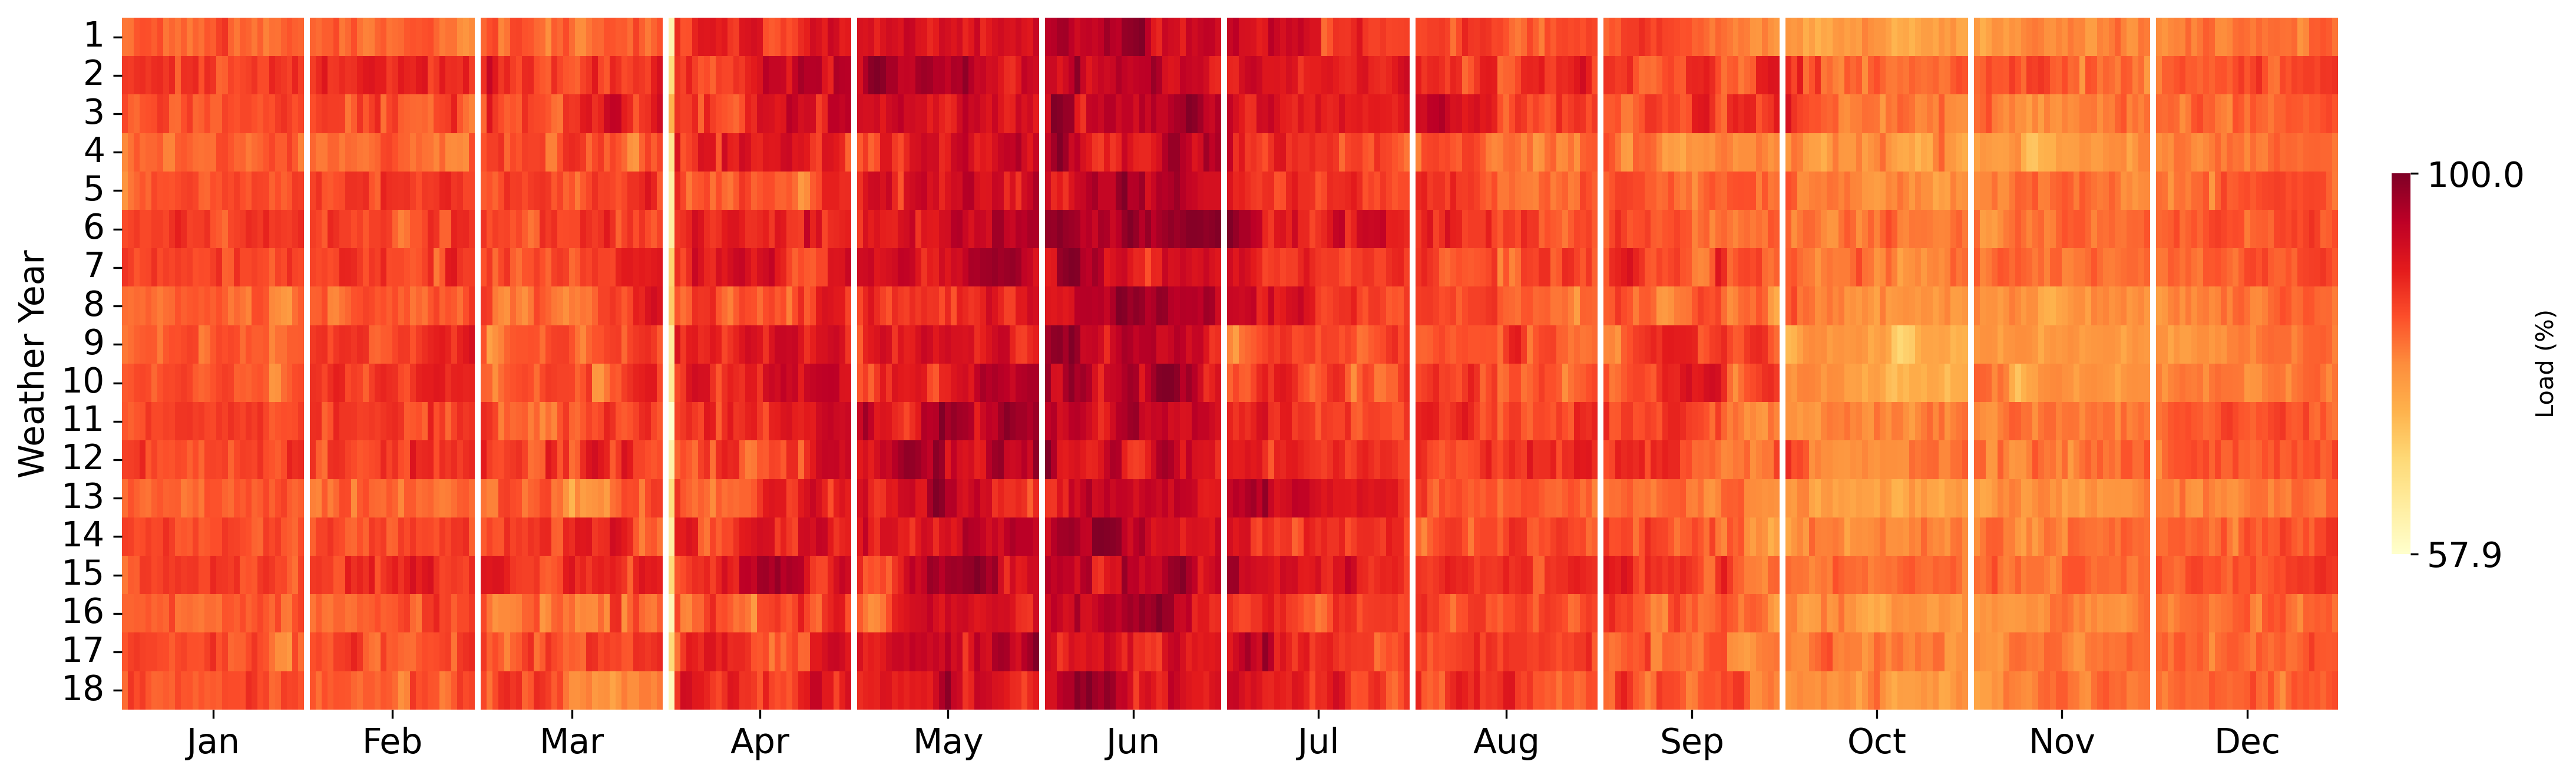

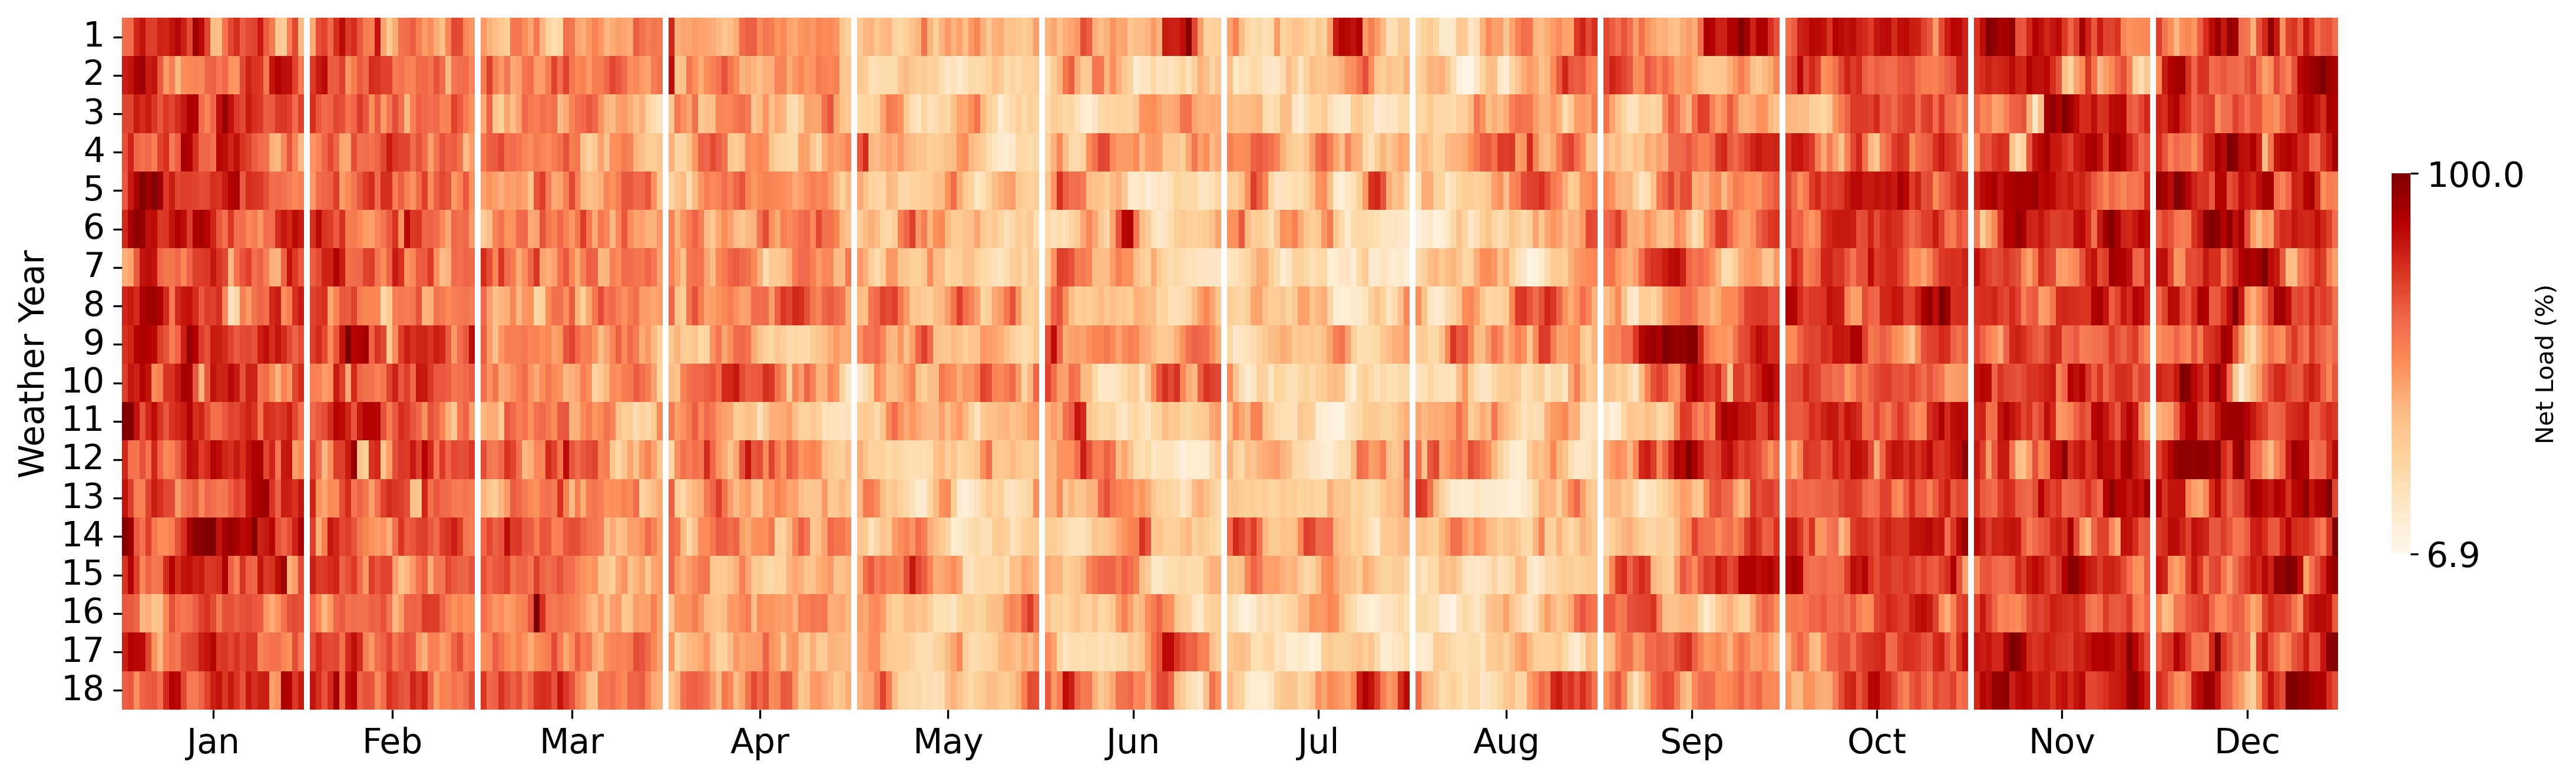

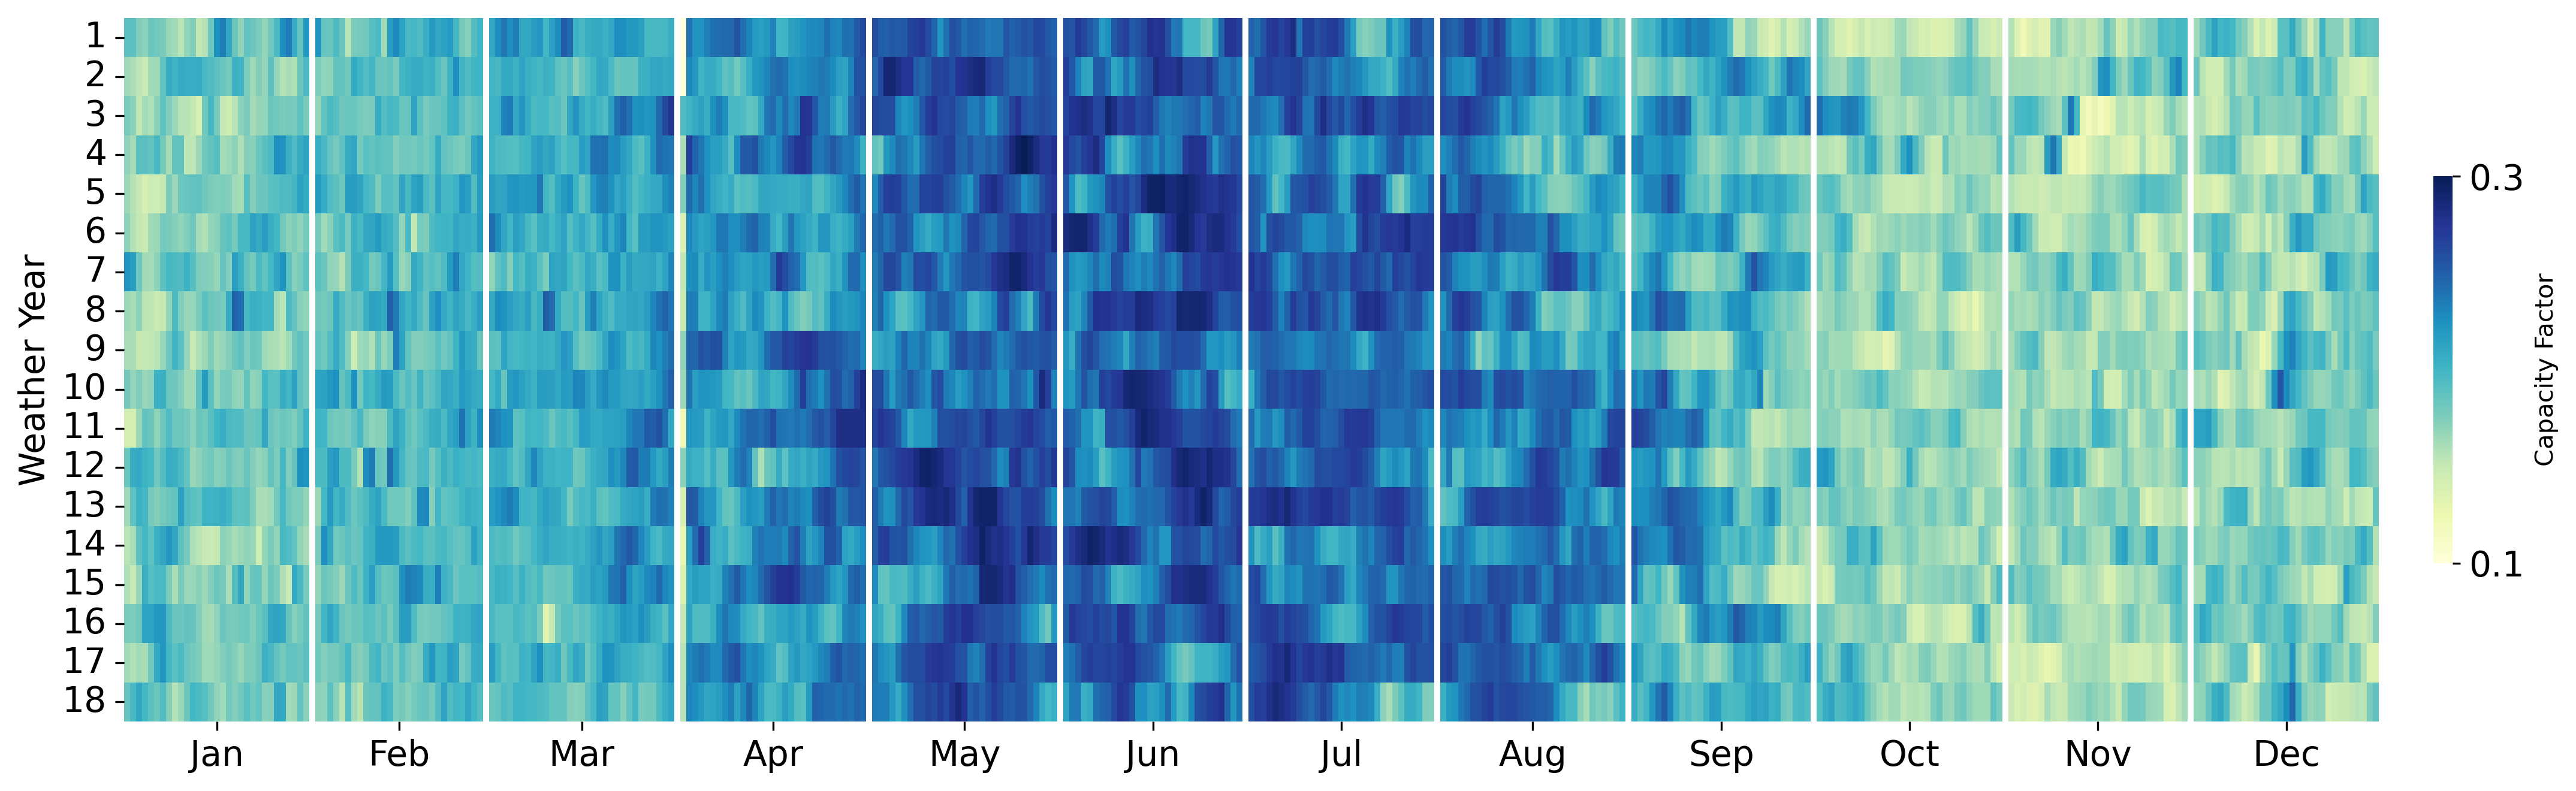

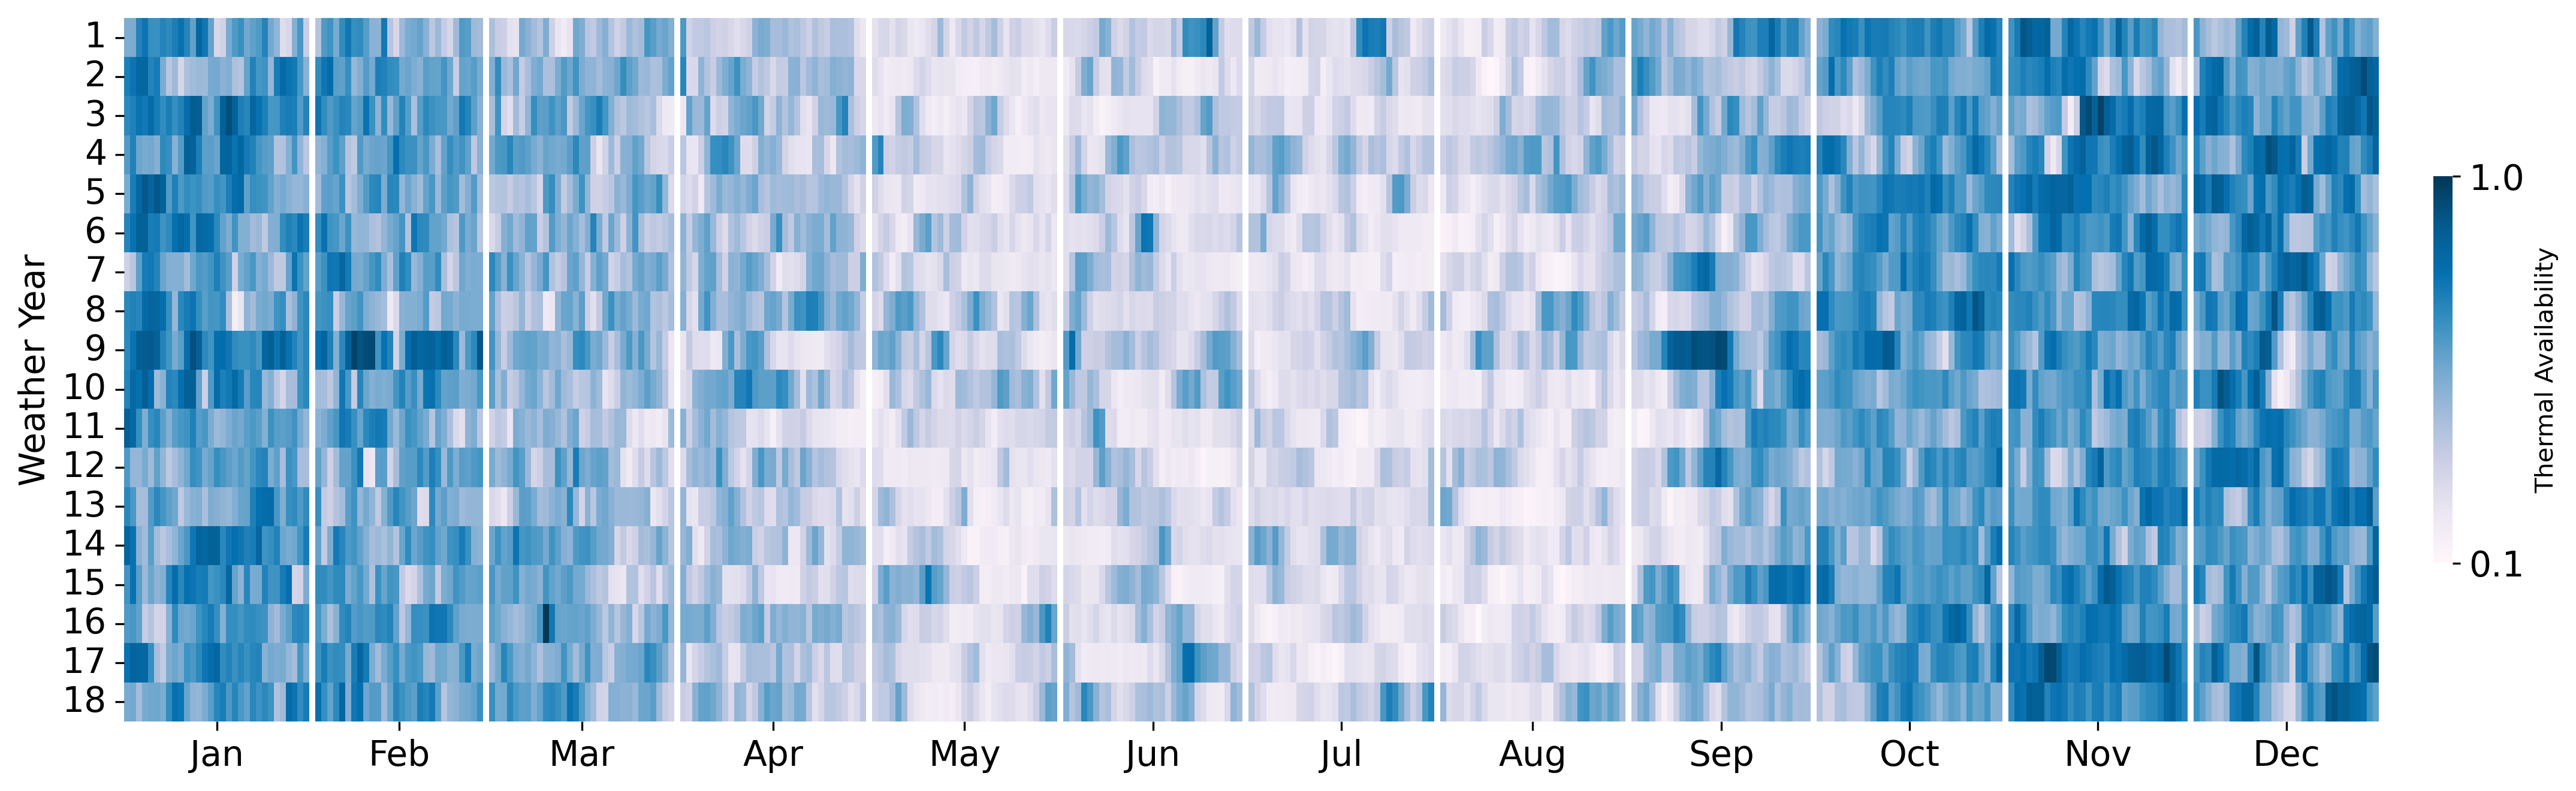

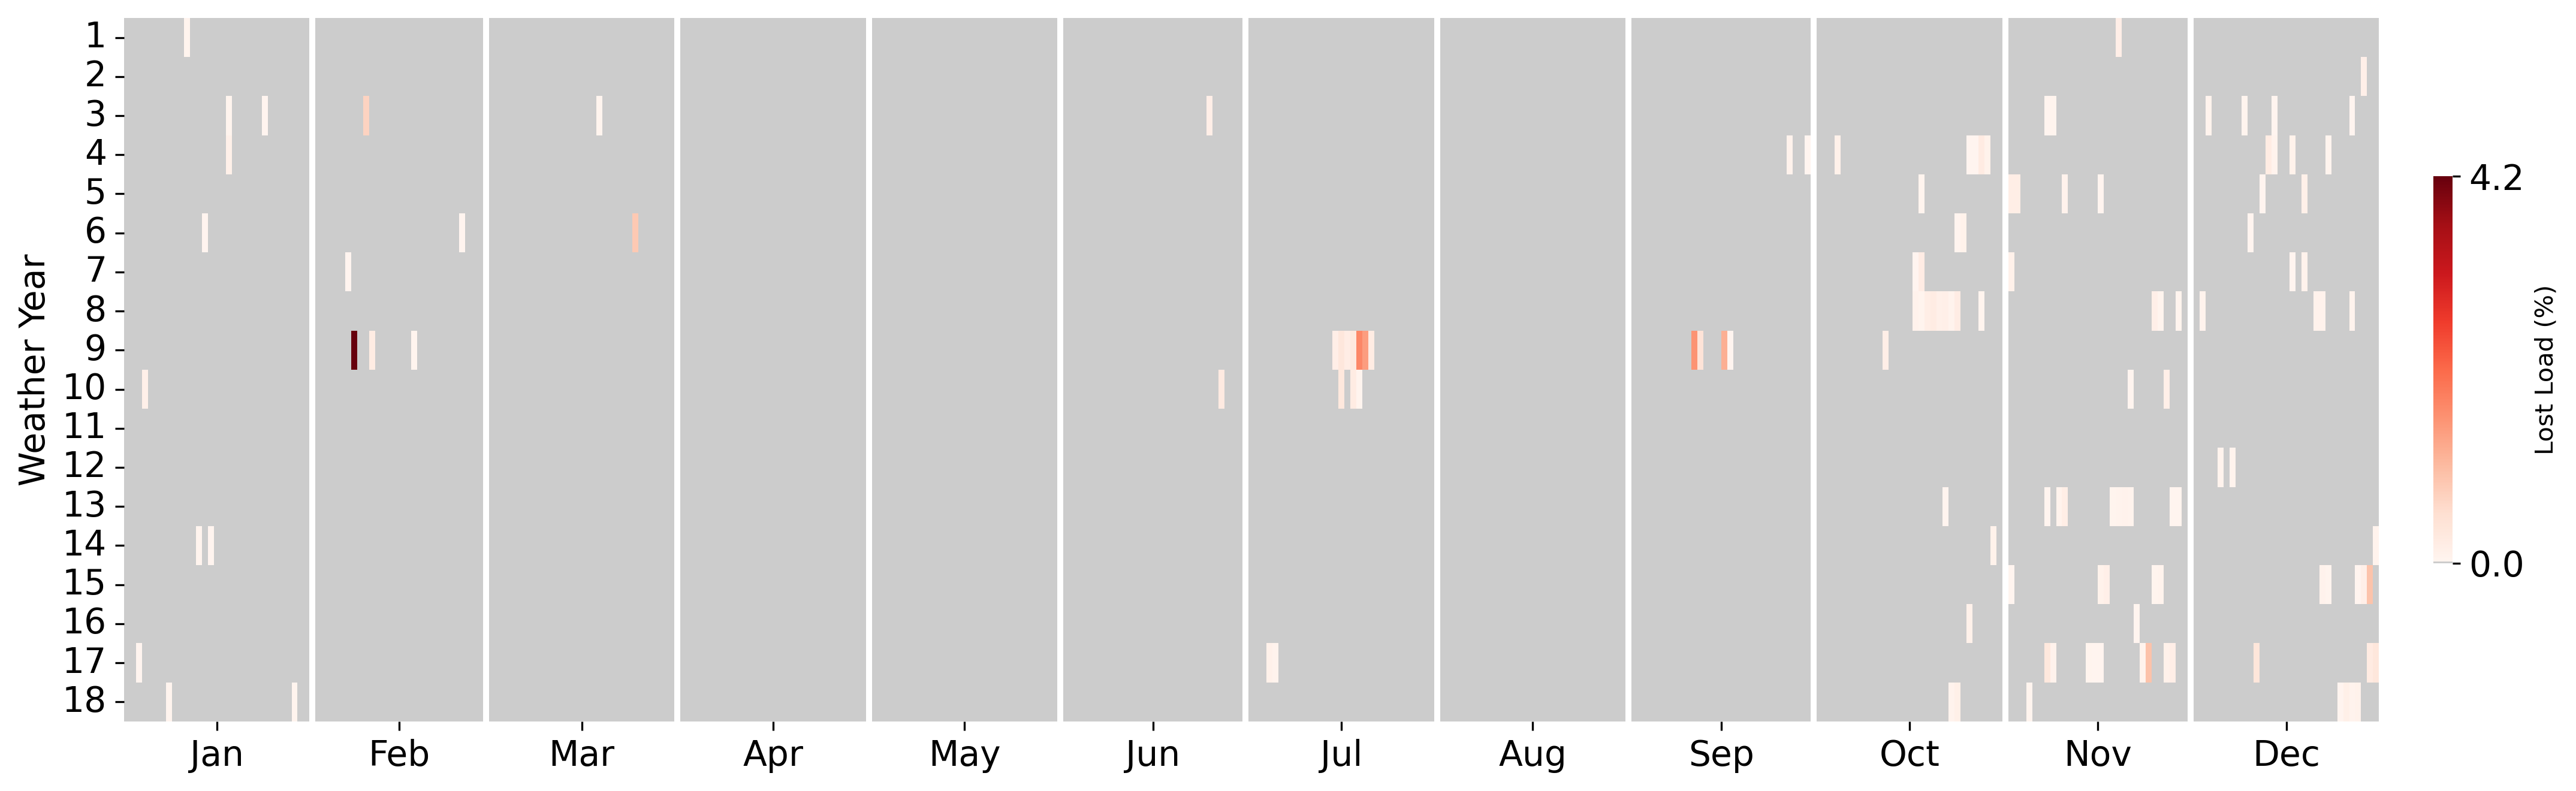

In [30]:
def _insert_month_gaps(arr, starts, gap_width=1):
    """Insert NaN gaps between months and return gapped array + tick positions at month centers."""
    parts = []
    nrows, ncols = arr.shape
    centers = []  # month centers for label placement
    offset = 0
    for i, s in enumerate(starts):
        e = starts[i + 1] if i + 1 < len(starts) else ncols
        parts.append(arr[:, s:e])
        centers.append(offset + (e - s) / 2)
        if i < len(starts) - 1:
            parts.append(np.full((nrows, gap_width), np.nan))
            offset += (e - s) + gap_width
        else:
            offset += (e - s)
    arr_gapped = np.concatenate(parts, axis=1)
    return arr_gapped, centers


def plot_national_heatmap(metric, cmap="YlOrRd", label=None):
    """
    Plot national daily metric heatmap (Jan–Dec, month gaps, centered labels, colorbar right, only min/max ticks).
    Adds gray background for zero values when plotting Lost Load %.
    """

    # --- Build iteration × day matrix (national) ---
    df = national_df.copy()
    df["iteration"] = (
        df[["W", "H", "A"]].astype(str).agg("-".join, axis=1)
        .astype("category").cat.codes + 1
    )
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    data = df.pivot_table(index="iteration", columns="timestamp", values=metric, aggfunc="mean")
    data = data.sort_index(axis=1)
    dates = pd.to_datetime(data.columns).to_pydatetime()
    ncols = data.shape[1]

    # --- Rotate so the first January appears first ---
    jan_idx = next((i for i, d in enumerate(dates) if d.month == 1 and d.day == 1),
                   next((i for i, d in enumerate(dates) if d.month == 1), 0))
    order = np.r_[np.arange(jan_idx, ncols), np.arange(0, jan_idx)]
    data = data.iloc[:, order]
    dates = np.array(dates)[order]

    # --- Month starts and labels ---
    month_starts = [0]
    for i in range(1, len(dates)):
        if dates[i].month != dates[i - 1].month:
            month_starts.append(i)
    month_labels = [pd.Timestamp(dates[i]).strftime("%b") for i in month_starts]

    # --- Convert to numeric array ---
    data = data.apply(pd.to_numeric, errors="coerce")
    arr = data.to_numpy()

    # --- Insert NaN gap columns and compute tick positions ---
    arr_gapped, tick_positions = _insert_month_gaps(arr, month_starts, gap_width=1)

    # === Plot ===
    fig, ax = plt.subplots(figsize=(16, 4.5), dpi=300)
    vmin, vmax = np.nanmin(arr_gapped), np.nanmax(arr_gapped)

    # --- Custom colormap for lost_load_pct (gray background for zero) ---
    if metric == "lost_load_pct":
        # Build a colormap where 0→gray and positive→Reds
        base = plt.cm.Reds(np.linspace(0, 1, 256))
        gray_rgb = np.array([0.8, 0.8, 0.8, 1.0])  # light gray
        base[0] = gray_rgb
        cmap = ListedColormap(base)

    hm = sns.heatmap(
        arr_gapped,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        linewidths=0,
        linecolor=None,
        cbar=True,
        cbar_kws={
            "orientation": "vertical",
            "pad": 0.02,
            "shrink": 0.55,
            "label": label if label else metric
        },
    )

    # --- Colorbar: show only min & max ---
    cbar = hm.collections[0].colorbar
    cbar.set_ticks([vmin, vmax])
    cbar.set_ticklabels([f"{vmin:.1f}", f"{vmax:.1f}"])
    cbar.ax.tick_params(labelsize=14, length=3)

    # --- Axis labels and ticks ---
    ax.set_ylabel("Weather Year", fontsize=14)
    ax.set_xlabel("")
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(month_labels, rotation=0, fontsize=14)
    ax.set_yticks(np.arange(arr_gapped.shape[0]) + 0.5)
    ax.set_yticklabels(np.arange(1, arr_gapped.shape[0] + 1),
                       fontsize=14, rotation=0, ha="right")

    plt.tight_layout()
    plt.show()
# 1️⃣ Load Percentage
plot_national_heatmap(metric="load_pct", cmap="YlOrRd", label="Load (%)")

# 2️⃣ Net Load Percentage
plot_national_heatmap(metric="net_load_pct", cmap="OrRd", label="Net Load (%)")

# 3️⃣ Renewable Capacity Factor
plot_national_heatmap(metric="capacity_factor", cmap="YlGnBu", label="Capacity Factor")

# 4️⃣ Transmission Capacity Factor
# plot_national_heatmap(metric="tx_cap_factor", cmap="YlOrBr", label="Transmission CF")

# 5️⃣ Thermal Availability Factor
plot_national_heatmap(metric="thermal_availability_factor", cmap="PuBu", label="Thermal Availability")

plot_national_heatmap(metric="lost_load_pct", cmap="Reds", label="Lost Load (%)")


# state level plots

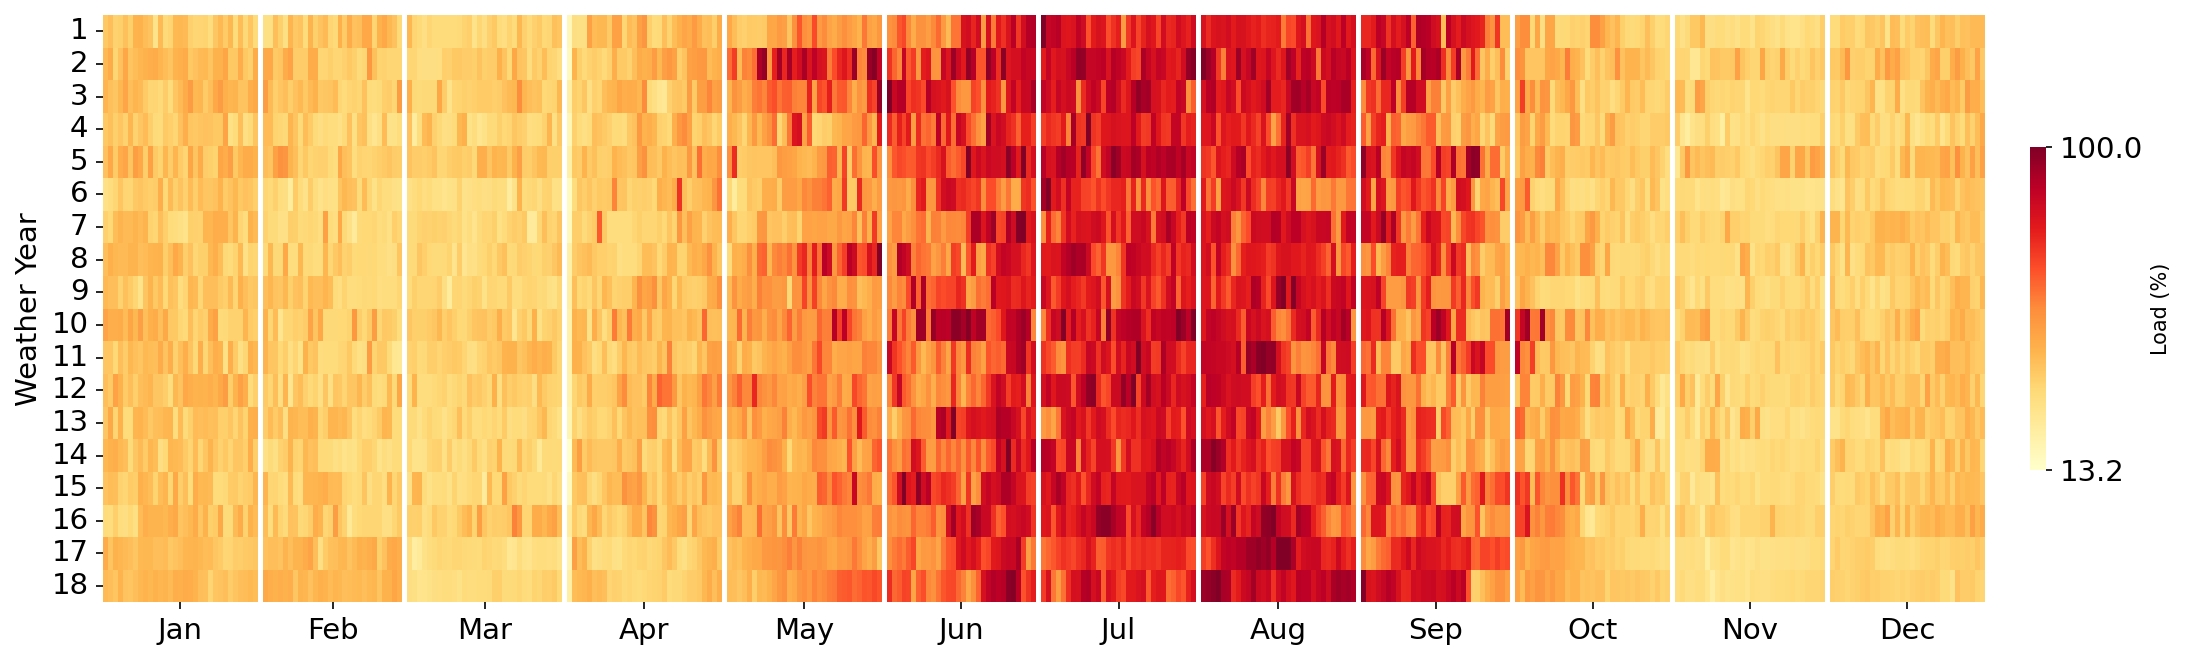

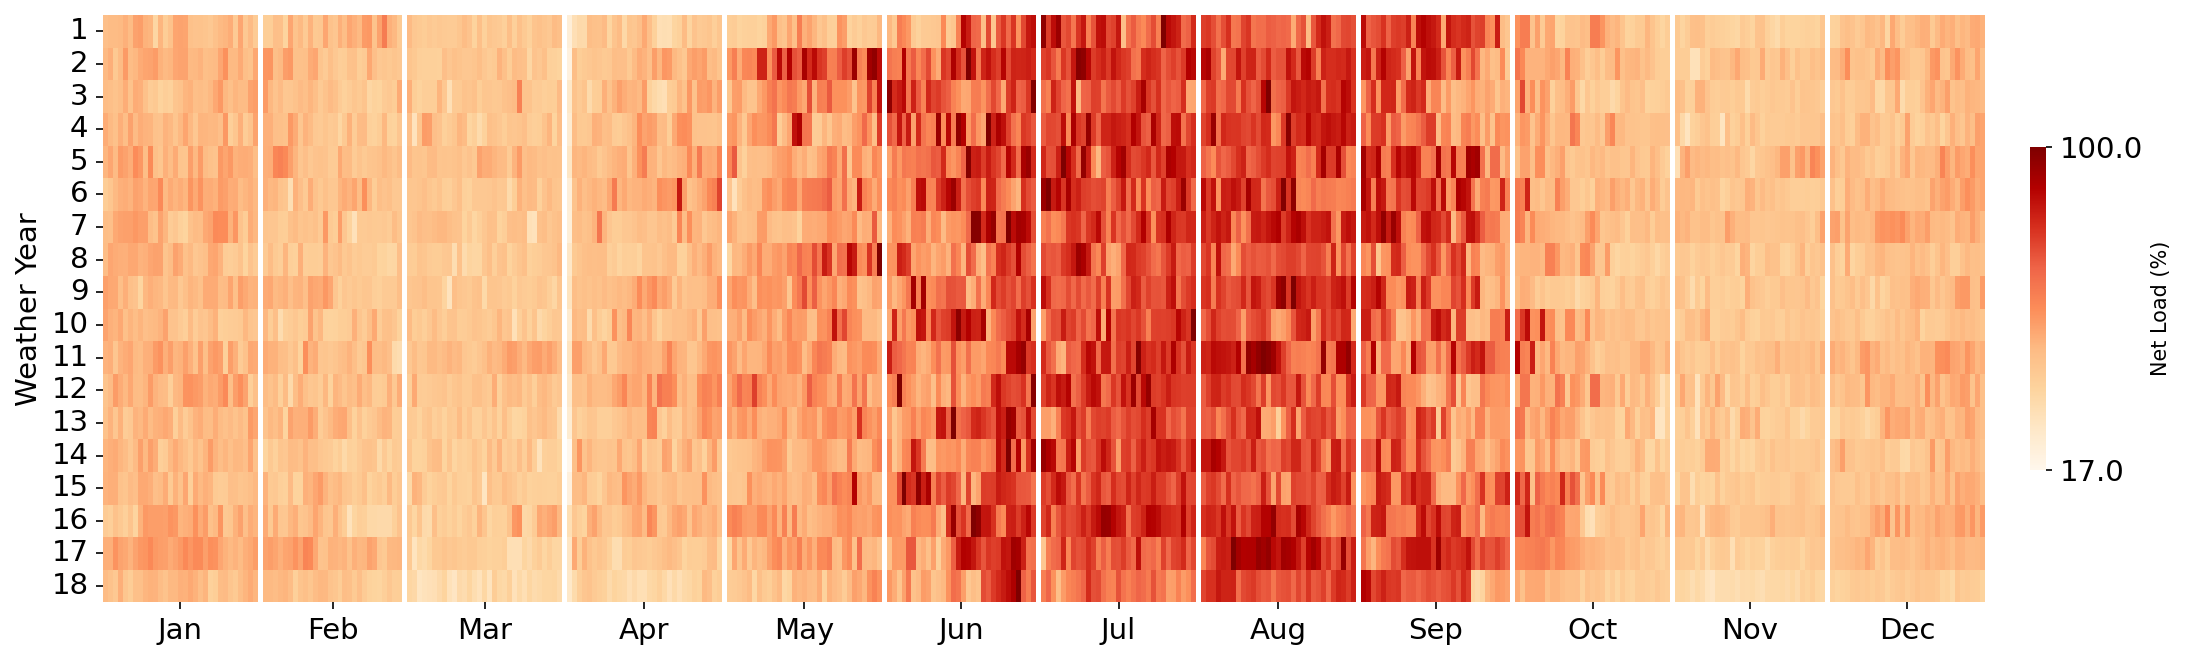

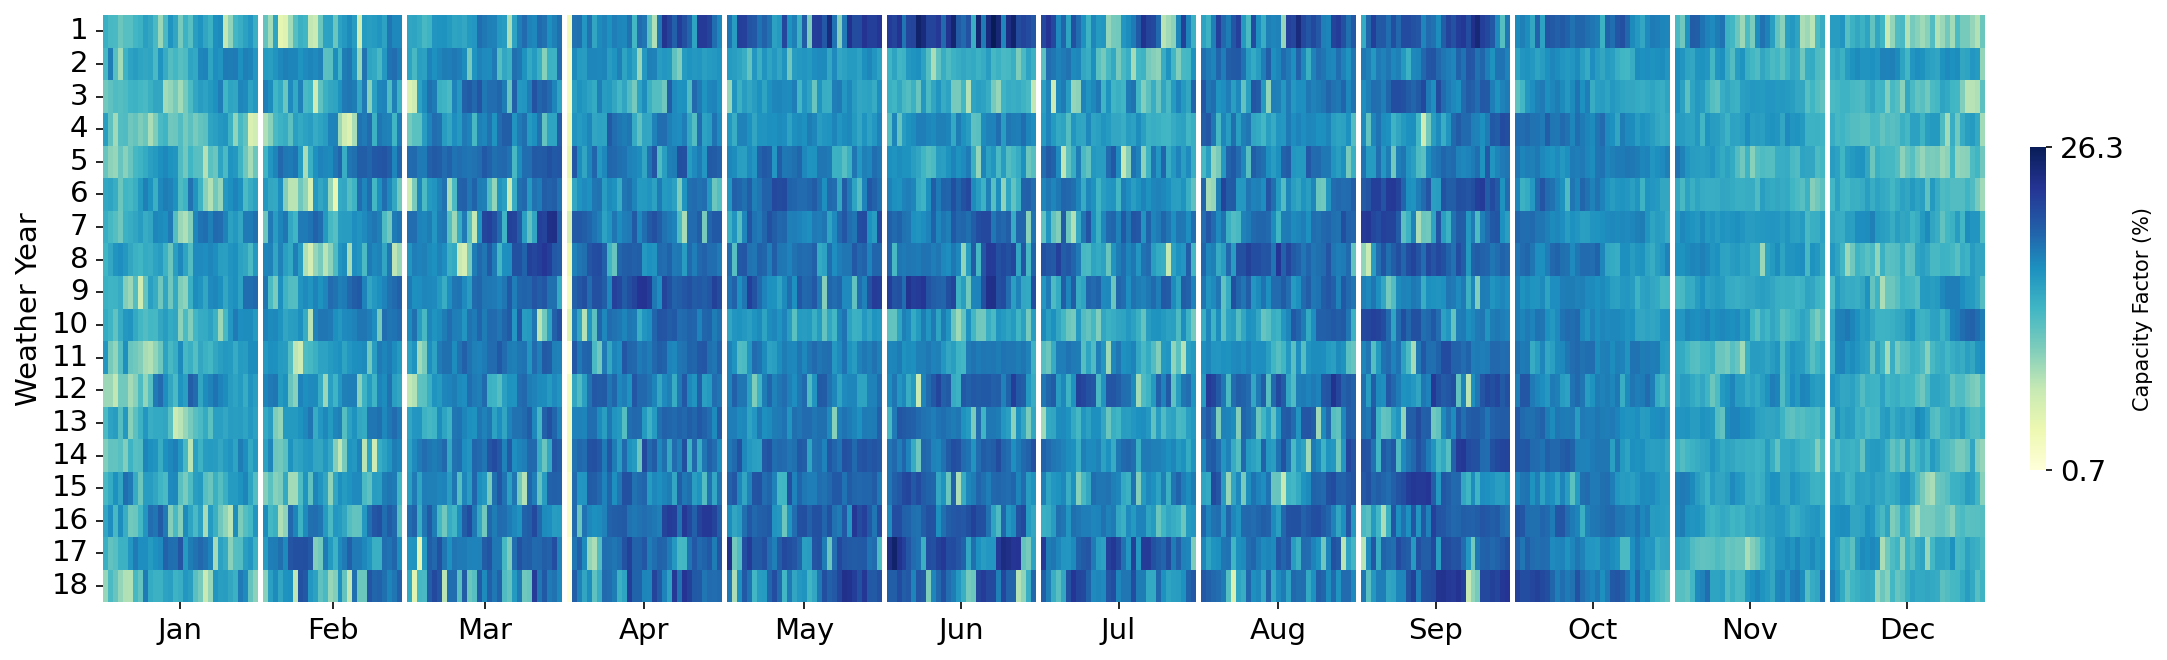

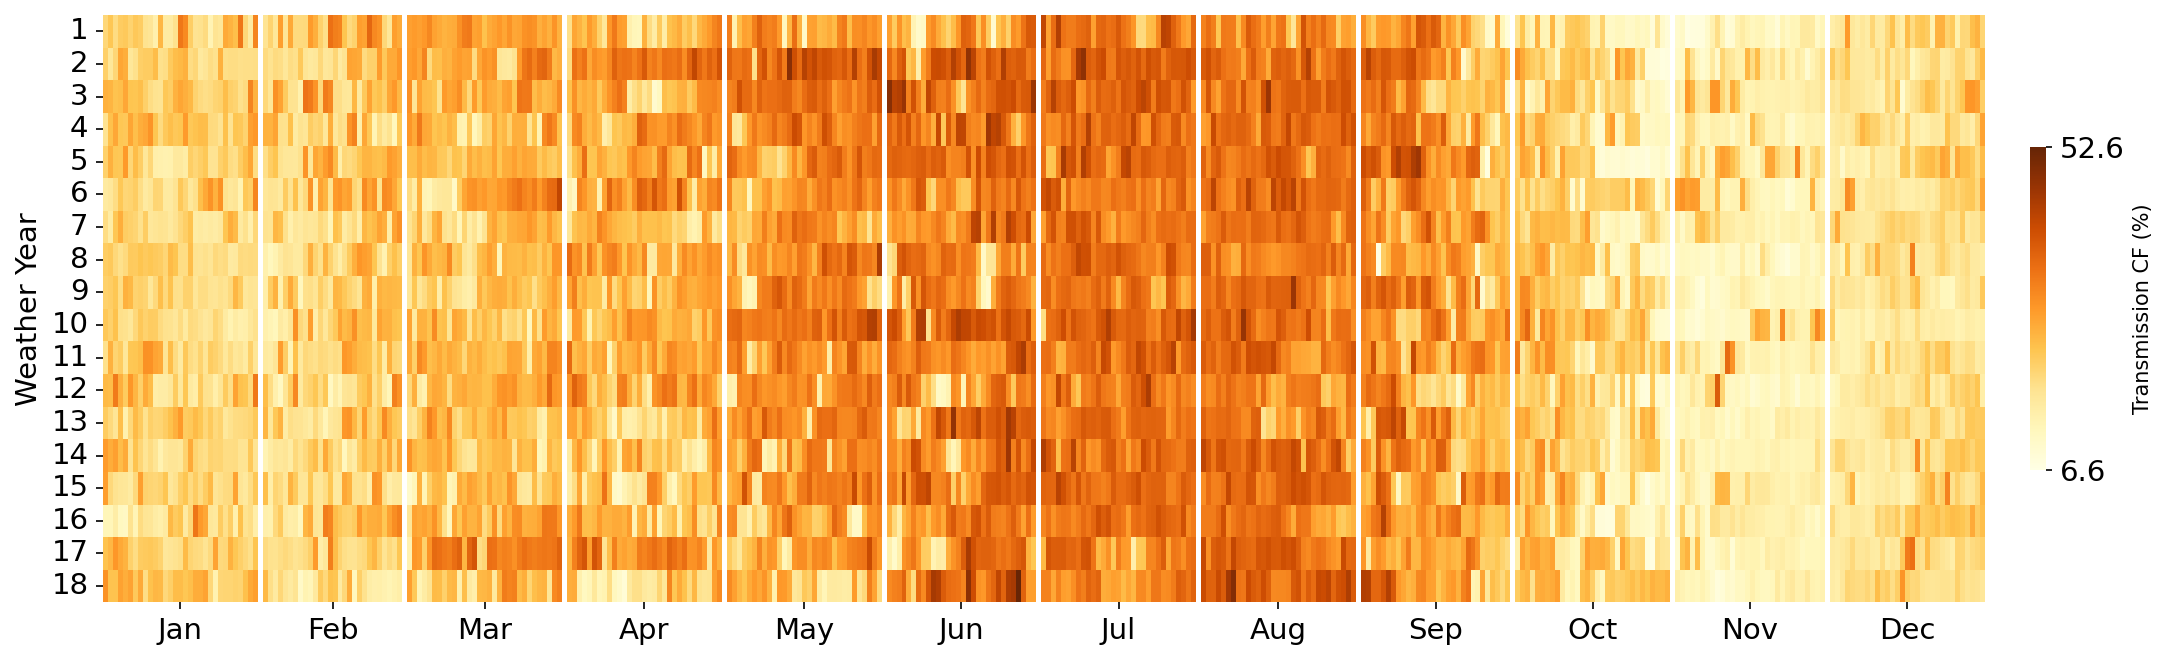

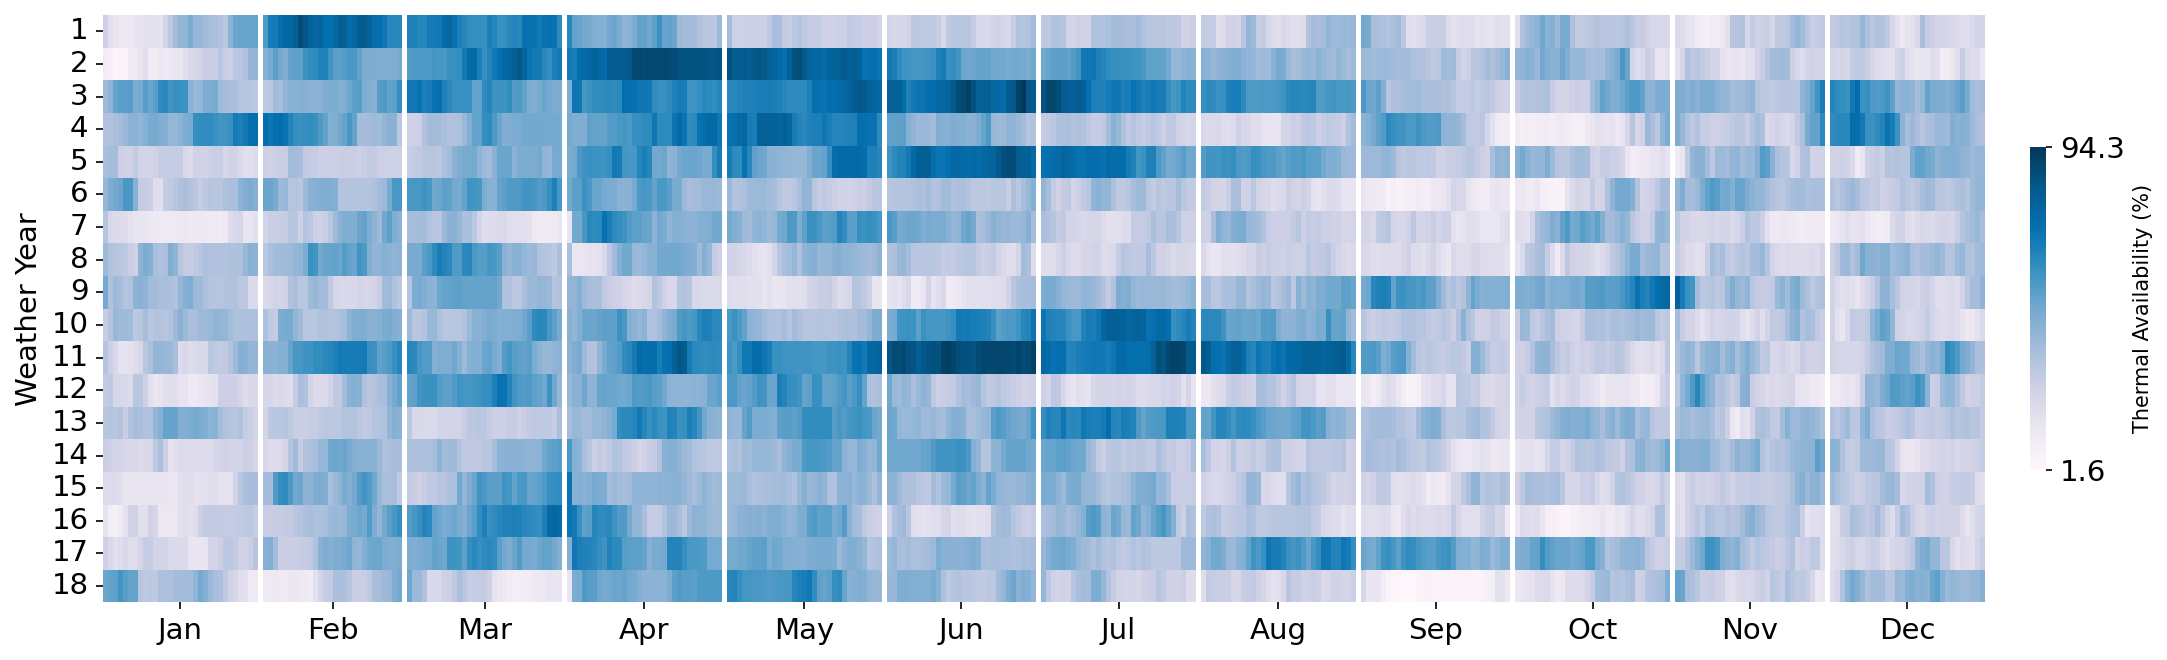

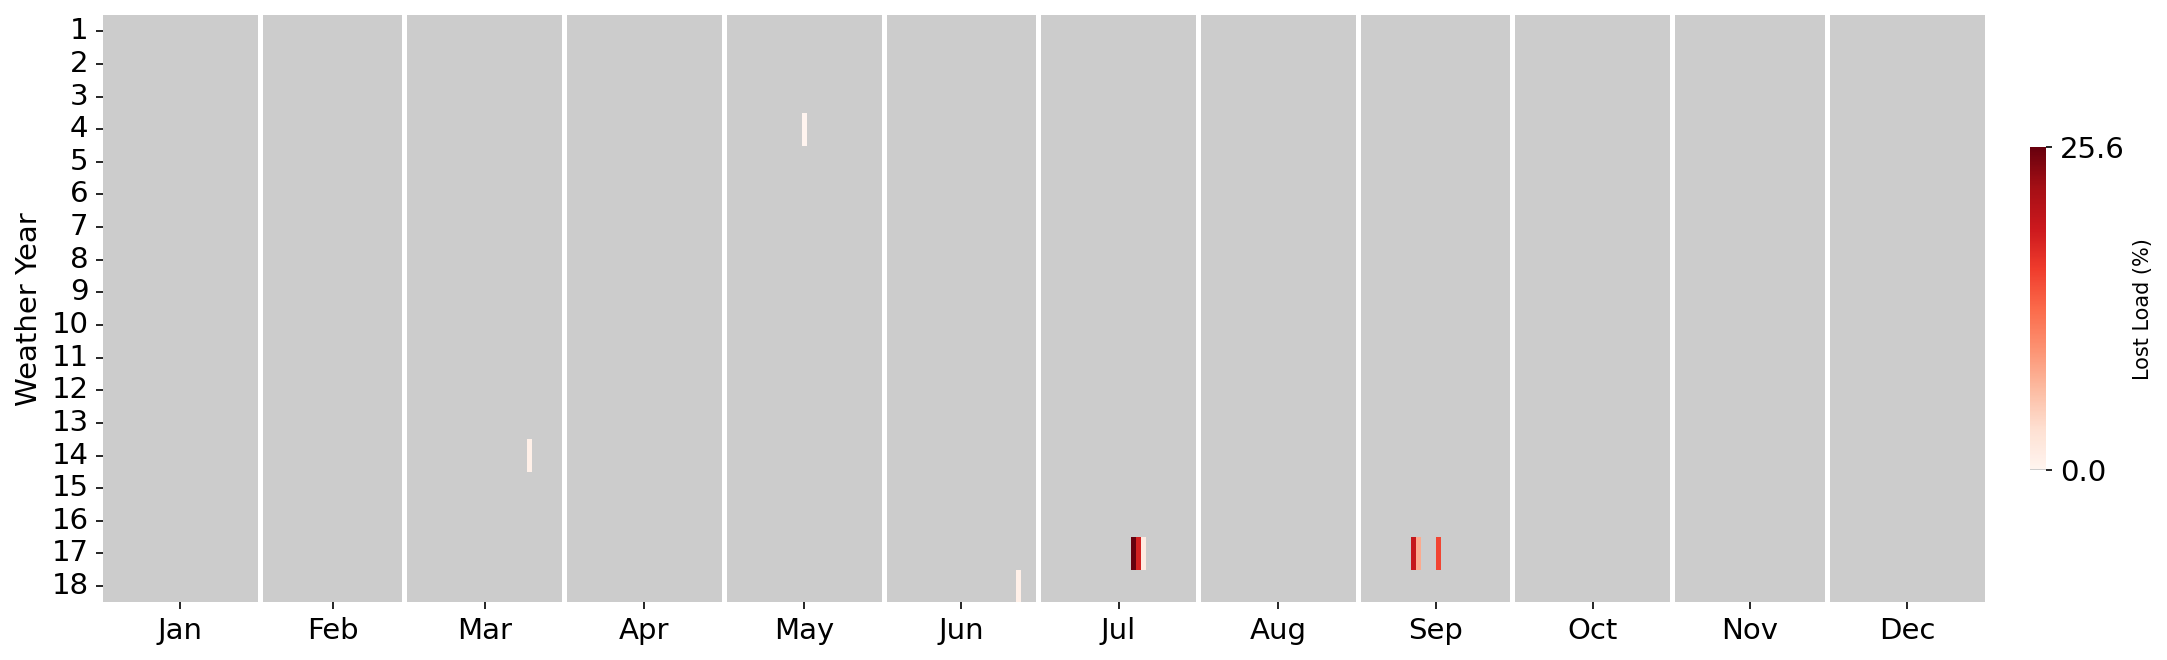

In [31]:
state = "Punjab"


# ---------------------------------------------------------------------
# Helper: insert NaN gaps between months (for visual separation)
# ---------------------------------------------------------------------
def _insert_month_gaps(arr, starts, gap_width=1):
    parts, centers = [], []
    nrows, ncols = arr.shape
    offset = 0
    for i, s in enumerate(starts):
        e = starts[i + 1] if i + 1 < len(starts) else ncols
        parts.append(arr[:, s:e])
        centers.append(offset + (e - s) / 2)
        if i < len(starts) - 1:
            parts.append(np.full((nrows, gap_width), np.nan))
            offset += (e - s) + gap_width
        else:
            offset += (e - s)
    return np.concatenate(parts, axis=1), centers


# ---------------------------------------------------------------------
# Heatmap plotting function (identical to national, safe for missing data)
# ---------------------------------------------------------------------
def plot_state_heatmap(df_state_daily, metric, cmap="YlOrRd", label=None):
    df = df_state_daily.copy()

    # Skip missing or empty metric
    if metric not in df.columns or df[metric].dropna().empty:
        print(f"⚠️  No data found for '{metric}' — skipping plot.")
        return

    # Diagonal runs only
    df = df.loc[(df["W"] == df["H"]) & (df["H"] == df["A"])].copy()
    df["iteration"] = df["W"].astype(int)
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # Pivot iteration × day
    data = df.pivot_table(index="iteration", columns="timestamp", values=metric, aggfunc="mean")
    if data.empty:
        print(f"⚠️  No valid data for '{metric}' — skipping plot.")
        return

    data = data.sort_index(axis=1)
    dates = pd.to_datetime(data.columns).to_pydatetime()
    if len(dates) == 0:
        print(f"⚠️  No valid dates for '{metric}' — skipping plot.")
        return

    # Rotate so January appears first
    jan_idx = next((i for i, d in enumerate(dates) if d.month == 1 and d.day == 1),
                   next((i for i, d in enumerate(dates) if d.month == 1), 0))
    order = np.r_[np.arange(jan_idx, len(dates)), np.arange(0, jan_idx)]
    data = data.iloc[:, order]
    dates = np.array(dates)[order]

    # Month starts & labels
    month_starts = [0]
    for i in range(1, len(dates)):
        if dates[i].month != dates[i - 1].month:
            month_starts.append(i)
    month_labels = [pd.Timestamp(dates[i]).strftime("%b") for i in month_starts]

    # Numeric array + month gaps
    data = data.apply(pd.to_numeric, errors="coerce")
    arr = data.to_numpy()
    arr_gapped, tick_positions = _insert_month_gaps(arr, month_starts, gap_width=1)

    # === Plot ===
    fig, ax = plt.subplots(figsize=(16, 4.5), dpi=150)
    vmin, vmax = np.nanmin(arr_gapped), np.nanmax(arr_gapped)

    # Gray background for 0 lost load
    if metric == "lost_load_pct":
        base = plt.cm.Reds(np.linspace(0, 1, 256))
        base[0] = [0.8, 0.8, 0.8, 1.0]
        cmap = ListedColormap(base)

    hm = sns.heatmap(
        arr_gapped,
        ax=ax,
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        linewidths=0, linecolor=None,
        cbar=True,
        cbar_kws={
            "orientation": "vertical",
            "pad": 0.02,
            "shrink": 0.55,
            "label": label if label else metric
        },
    )

    cbar = hm.collections[0].colorbar
    cbar.set_ticks([vmin, vmax])
    cbar.set_ticklabels([f"{vmin:.1f}", f"{vmax:.1f}"])
    cbar.ax.tick_params(labelsize=14, length=3)

    # ax.set_title(label if label else metric, loc="left", fontsize=14)
    ax.set_ylabel("Weather Year", fontsize=14)
    ax.set_xlabel("")
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(month_labels, rotation=0, fontsize=14)
    ax.set_yticks(np.arange(arr_gapped.shape[0]) + 0.5)
    ax.set_yticklabels(np.arange(1, arr_gapped.shape[0] + 1),
                       fontsize=14, rotation=0, ha="right")

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------
# STEP 1: Build correct MW-level base dataframe
# ---------------------------------------------------------------------
vre = df_dispatch_[df_dispatch_['technology'].isin(['Wind','Solar','Hydro_ROR'])].copy()
vre_power = (
    vre.groupby(['load_zone','timepoint','W','H','A'],as_index=False)['power_mw']
       .sum()
       .rename(columns={'power_mw':'vre_power_mw'})
)

df = pd.merge(df_load_.copy(), vre_power,
              on=['load_zone','timepoint','W','H','A'], how='left')
df['vre_power_mw'] = df['vre_power_mw'].fillna(0.0)
df['net_load'] = df['static_load'] - df['vre_power_mw']

if 'timestamp' not in df.columns:
    tp = df['timepoint'].astype(str)
    dates = tp.str[:8]
    hours = tp.str[8:].astype(int) - 1
    df['timestamp'] = pd.to_datetime(dates, format='%Y%m%d') + pd.to_timedelta(hours, unit='h')


# ---------------------------------------------------------------------
# STEP 2: Select zone and recompute all metrics in %
# ---------------------------------------------------------------------

df_state = df[df['load_zone'] == state].copy().drop(columns=['load_zone'])
df_state['timestamp'] = pd.to_datetime(df_state['timestamp'])

# Iteration-wise peaks
peak_static = df_state.groupby(['W','H','A'])['static_load'].transform('max')
peak_net    = df_state.groupby(['W','H','A'])['net_load'].transform('max')

# Load/NetLoad/LostLoad %
df_state['load_pct']      = 100.0 * df_state['static_load'] / peak_static
df_state['net_load_pct']  = 100.0 * df_state['net_load'] / peak_net
df_state['lost_load_pct'] = 100.0 * df_state['unserved_energy'] / df_state['static_load']
df_state['load_pct']      = df_state['load_pct'].clip(0,100)
df_state['net_load_pct']  = df_state['net_load_pct'].clip(0,100)

# ---------------------------------------------------------------------
# STEP 3: Rebuild factors for this zone (in %)
# ---------------------------------------------------------------------
# --- Capacity factor ---
cap_zone = (df_dispatch_[df_dispatch_['load_zone']==state]
            .groupby(['timepoint','W','H','A'],as_index=False)
            .agg({'power_mw':'sum','capacity_mw':'sum'}))
cap_zone['capacity_factor'] = 100 * cap_zone['power_mw']/cap_zone['capacity_mw']

# --- Transmission CF ---
tx_zone = (df_transmission_timepoints_zone[df_transmission_timepoints_zone['load_zone']==state]
           .groupby(['timepoint','W','H','A'],as_index=False)
           .agg({'zone_transmission_flow_mw':'mean','zone_max_mw':'mean'}))
tx_zone['tx_cap_factor'] = 100 * tx_zone['zone_transmission_flow_mw']/tx_zone['zone_max_mw']

# --- Thermal availability (% available) ---
therm_zone = (df_dispatch_[df_dispatch_['load_zone']==state]
              .query("technology in ['Coal','Gas','Diesel','Nuclear']")
              .groupby(['timepoint','W','H','A'],as_index=False)
              .agg({'availability_derate':'mean'}))
therm_zone['thermal_availability_factor'] = 100 * (1 - therm_zone['availability_derate'])

# --- Merge them into df_state ---
for merge_df in [cap_zone, tx_zone, therm_zone]:
    cols = ['timepoint','W','H','A'] + [c for c in merge_df.columns if c.endswith('_factor')]
    df_state = pd.merge(df_state, merge_df[cols],
                        on=['timepoint','W','H','A'], how='left')

# ---------------------------------------------------------------------
# STEP 4: Daily aggregation
# ---------------------------------------------------------------------
agg_dict = {
    'load_pct':'max',
    'net_load_pct':'max',
    'lost_load_pct':'mean',
    'capacity_factor':'mean',
    'tx_cap_factor':'mean',
    'thermal_availability_factor':'mean'
}
df_state_daily = (
    df_state.set_index('timestamp')
             .groupby(['W','H','A'])
             .resample('D')
             .agg(agg_dict)
             .reset_index()
)

# ---------------------------------------------------------------------
# STEP 5: Generate all heatmaps
# ---------------------------------------------------------------------
plot_state_heatmap(df_state_daily,'load_pct',cmap='YlOrRd',label='Load (%)')
plot_state_heatmap(df_state_daily,'net_load_pct',cmap='OrRd',label='Net Load (%)')
plot_state_heatmap(df_state_daily,'capacity_factor',cmap='YlGnBu',label='Capacity Factor (%)')
plot_state_heatmap(df_state_daily,'tx_cap_factor',cmap='YlOrBr',label='Transmission CF (%)')
plot_state_heatmap(df_state_daily,'thermal_availability_factor',cmap='PuBu',label='Thermal Availability (%)')
plot_state_heatmap(df_state_daily,'lost_load_pct',cmap='Reds',label='Lost Load (%)')

#now we start event based analysis of unserved energy

#1. after identifying the severest year 
2. top 5-10 extreme events when we see the most USE for all states
3. for each of the above timepoints plot all the heatmaps

In [32]:
df = merged_df_.copy()

tau=1.0 # 1 MW threshold for LOL event

# 1. Remove Bhutan
df = df[df['load_zone'] != 'Bhutan'].copy()

# 2. Reset index if timestamp is an index
if 'timestamp' in df.index.names:
    df = df.reset_index()

# 3. If timestamp doesn’t exist, create it from timepoint
if 'timestamp' not in df.columns:
    tp = df['timepoint'].astype(str)
    dates = tp.str[:8]
    hours = tp.str[8:].astype(int)
    df['timestamp'] = pd.to_datetime(dates, format='%Y%m%d') + pd.to_timedelta(hours, unit='h')
# 
#filter all the rows where unserved_energy is greater than 1 MW
df_lol = df[df['unserved_energy'] > tau].copy()
df_lol['lost_load_pct']= 100*df_lol['unserved_energy']/df_lol['static_load']

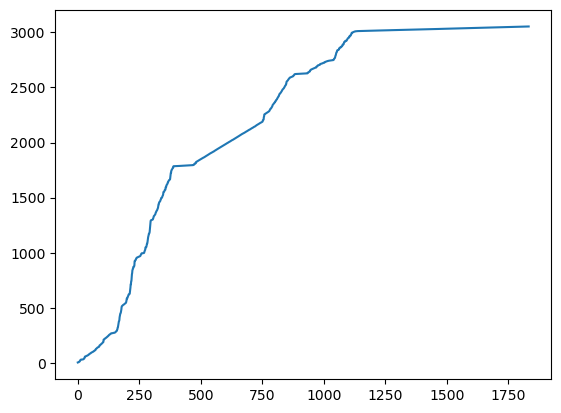

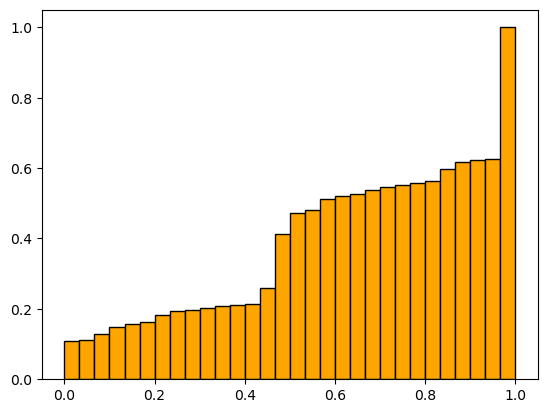

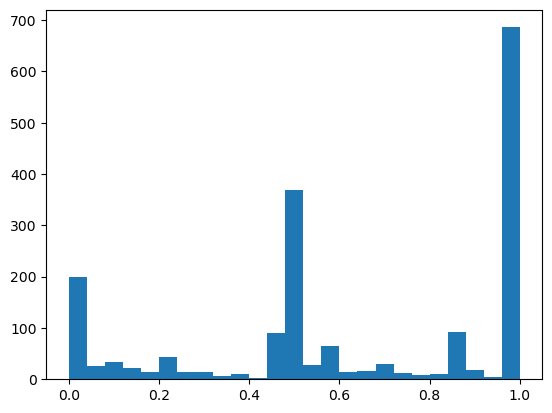

In [33]:

ue_ = df_lol['unserved_energy'].values
tx_ = df_lol['tx_cap_factor'].values

idx_ = np.argsort(df_lol['tx_cap_factor'])

plt.figure()
plt.plot(np.cumsum(ue_[idx_])/1000)
plt.show()

plt.figure()
plt.hist(df_lol['tx_cap_factor'], bins=30, cumulative=True, density=True, color='orange', edgecolor='black')
plt.show()

plt.figure()
plt.hist(df_lol['tx_cap_factor'], range = (0,1), bins = 25)
plt.show()

In [34]:
# find the coincident timestamps for all states where the unserved energy is greater than 1 MW
coincident_timestamps = df_lol['timestamp'].unique()
df_coincident = df[df['timestamp'].isin(coincident_timestamps)].copy()

#lets's analysis LOL state by state

In [35]:
# filter only Gujarat from top_events
events_zone = df_lol[df_lol['load_zone'] == 'Punjab']
#sort by unserved_energy descending
events_zone = events_zone.sort_values(by='unserved_energy', ascending=False)

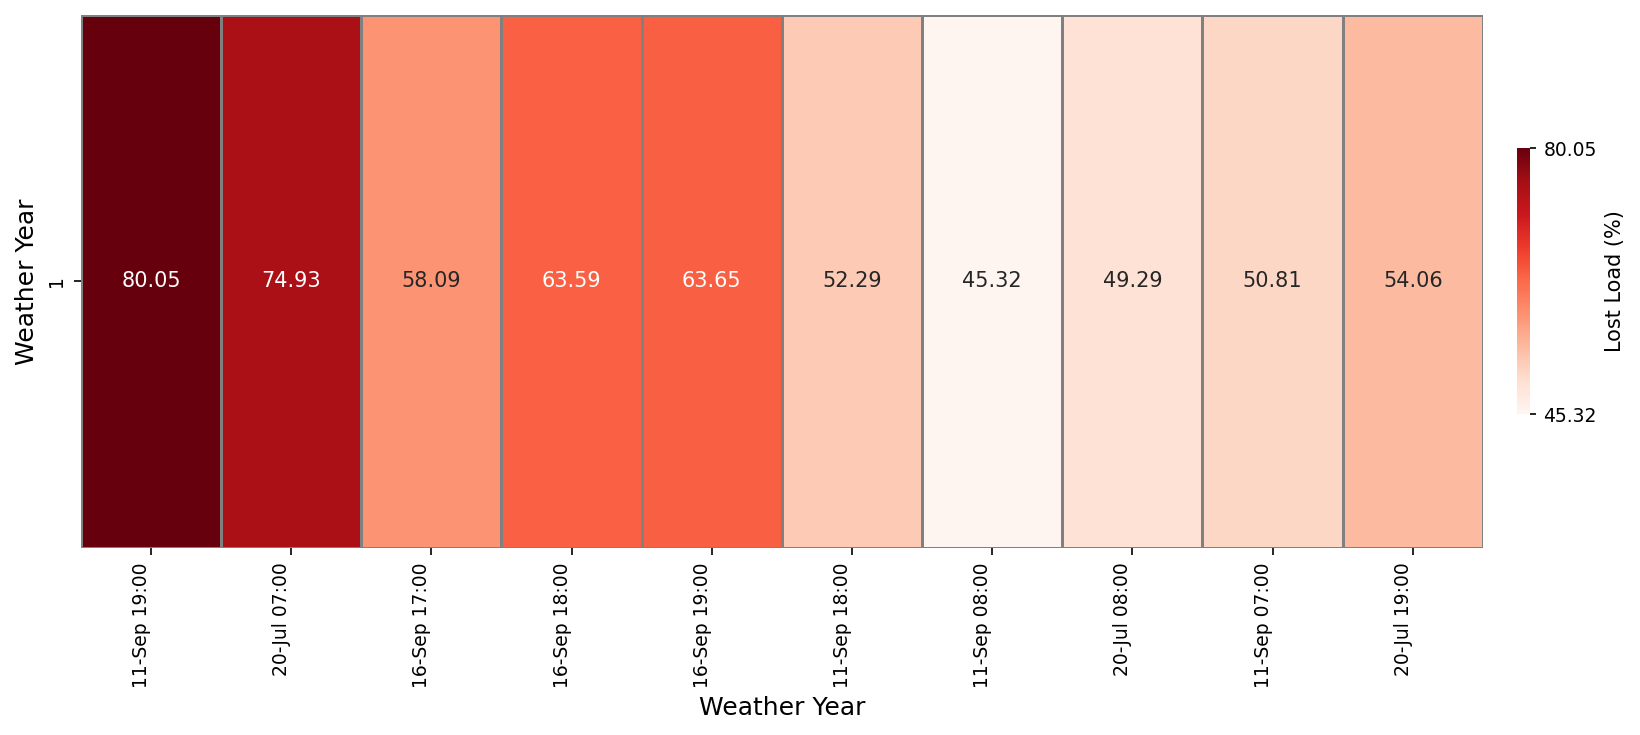

In [36]:

# --- Select top 10 timestamps with highest unserved energy ---
top10_timestamps = (
    events_zone.groupby('timestamp')['unserved_energy']
    .sum()
    .nlargest(10)
    .index
)

# --- Filter to those timestamps ---
df_top = events_zone[events_zone['timestamp'].isin(top10_timestamps)].copy()

# --- Create numeric iteration index (for W==H==A combinations) ---
unique_iters = (
    df_top[['W', 'H', 'A']]
    .drop_duplicates()
    .sort_values(['W', 'H', 'A'])
    .reset_index(drop=True)
)
unique_iters['iteration'] = range(1, len(unique_iters) + 1)
df_top = pd.merge(df_top, unique_iters, on=['W', 'H', 'A'], how='left')

# --- Format timestamps for display (dd-mmm HH:MM) ---
df_top['timestamp_label'] = df_top['timestamp'].dt.strftime("%d-%b %H:%M")

# --- Pivot: iteration × timestamp (lost_load_pct) ---
heat_data = df_top.pivot_table(
    index='iteration',
    columns='timestamp_label',
    values='lost_load_pct',
    aggfunc='mean'
)

# --- Order columns by total unserved_energy descending ---
order = (
    df_top.groupby('timestamp_label')['unserved_energy']
    .sum()
    .sort_values(ascending=False)
    .index
)
heat_data = heat_data[order]

# --- Plot heatmap ---
fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

# Determine vmin/vmax
vmin, vmax = np.nanmin(heat_data.values), np.nanmax(heat_data.values)

# Create heatmap
hm = sns.heatmap(
    heat_data,
    cmap="Reds",
    annot=True, fmt=".2f",
    linewidths=0.5, linecolor='grey',
    cbar=True,
    cbar_kws={"orientation": "vertical", "pad": 0.02, "shrink": 0.5}
)

# --- Compact colorbar (min/max only) ---
cbar = hm.collections[0].colorbar
cbar.set_ticks([vmin, vmax])
cbar.set_ticklabels([f"{vmin:.2f}", f"{vmax:.2f}"])
cbar.ax.tick_params(labelsize=9, length=3)
cbar.set_label("Lost Load (%)", fontsize=10)

# --- Axis labels only (no title) ---
ax.set_xlabel("Weather Year", fontsize=12)
ax.set_ylabel("Weather Year", fontsize=12)

plt.xticks(rotation=90, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

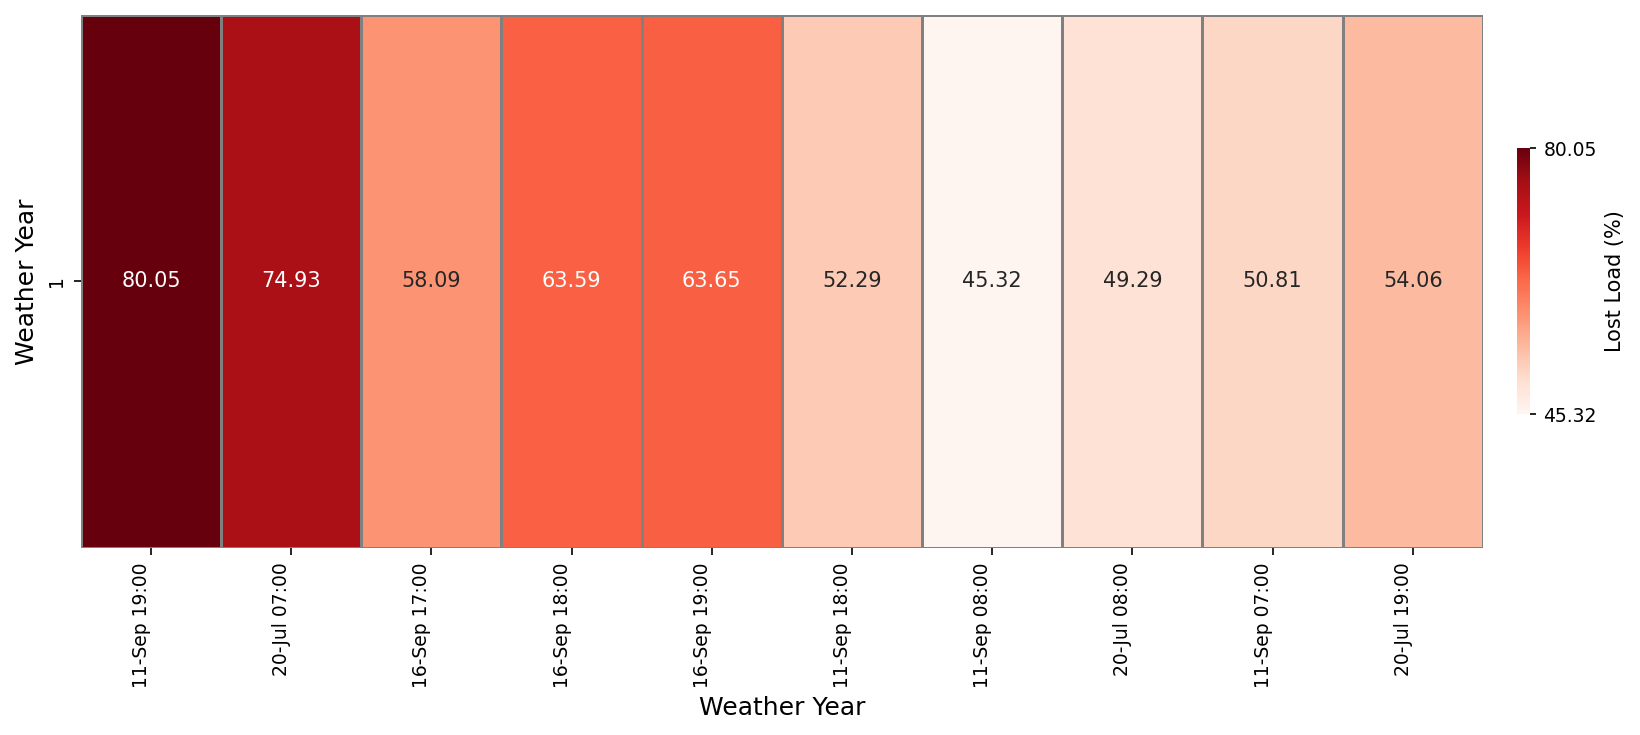

In [37]:
# ===============================================================
# FULL WORKING SCRIPT TO PLOT LOST LOAD (%) HEATMAP
# ===============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 0️⃣  Make sure you already have your 'events_zone' DataFrame
#      It must include at least:
#      ['timestamp','W','H','A','lost_load_pct','unserved_energy']
# ---------------------------------------------------------------------

# --- 1️⃣  Select Top 10 timestamps with highest total unserved energy ---
top10_timestamps = (
    events_zone.groupby('timestamp')['unserved_energy']
    .sum()
    .nlargest(10)
    .index
)

# Filter to those timestamps only
df_top = events_zone[events_zone['timestamp'].isin(top10_timestamps)].copy()

# --- 2️⃣  Create numeric iteration index (Weather Year) ---
unique_iters = (
    df_top[['W', 'H', 'A']]
    .drop_duplicates()
    .sort_values(['W', 'H', 'A'])
    .reset_index(drop=True)
)
unique_iters['iteration'] = range(1, len(unique_iters) + 1)

df_top = pd.merge(df_top, unique_iters, on=['W', 'H', 'A'], how='left')

# --- 3️⃣  Format timestamps for display (dd-mmm HH:MM) ---
df_top['timestamp_label'] = df_top['timestamp'].dt.strftime("%d-%b %H:%M")

# --- Order timestamps by total unserved_energy descending ---
timestamp_order = (
    df_top.groupby('timestamp_label')['unserved_energy']
    .sum()
    .sort_values(ascending=False)
    .index
)

# --- 4️⃣  Pivot table (iteration × timestamp) for lost_load_pct ---
heat_data = df_top.pivot_table(
    index='iteration',
    columns='timestamp_label',
    values='lost_load_pct',
    aggfunc='mean'
)

# Reorder columns by descending unserved energy
heat_data = heat_data[timestamp_order]

# --- 5️⃣  Mask zeros and negatives (show only positive Lost Load %) ---
mask = (heat_data <= 0) | (heat_data.isna())

# --- 6️⃣  Plot heatmap ---
fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

vmin, vmax = np.nanmin(heat_data.values), np.nanmax(heat_data.values)

hm = sns.heatmap(
    heat_data,
    mask=mask,                    # hide 0 or negative cells
    cmap="Reds",
    annot=True, fmt=".2f",
    linewidths=0.5, linecolor='grey',
    cbar=True,
    cbar_kws={"orientation": "vertical", "pad": 0.02, "shrink": 0.5}
)

# --- Compact colorbar (min & max only) ---
cbar = hm.collections[0].colorbar
cbar.set_ticks([vmin, vmax])
cbar.set_ticklabels([f"{vmin:.2f}", f"{vmax:.2f}"])
cbar.ax.tick_params(labelsize=9, length=3)
cbar.set_label("Lost Load (%)", fontsize=10)

# --- 7️⃣  Axis labels (no title) ---
ax.set_xlabel("Weather Year", fontsize=12)
ax.set_ylabel("Weather Year", fontsize=12)

plt.xticks(rotation=90, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# ===============================================================
# END OF SCRIPT
# ===============================================================

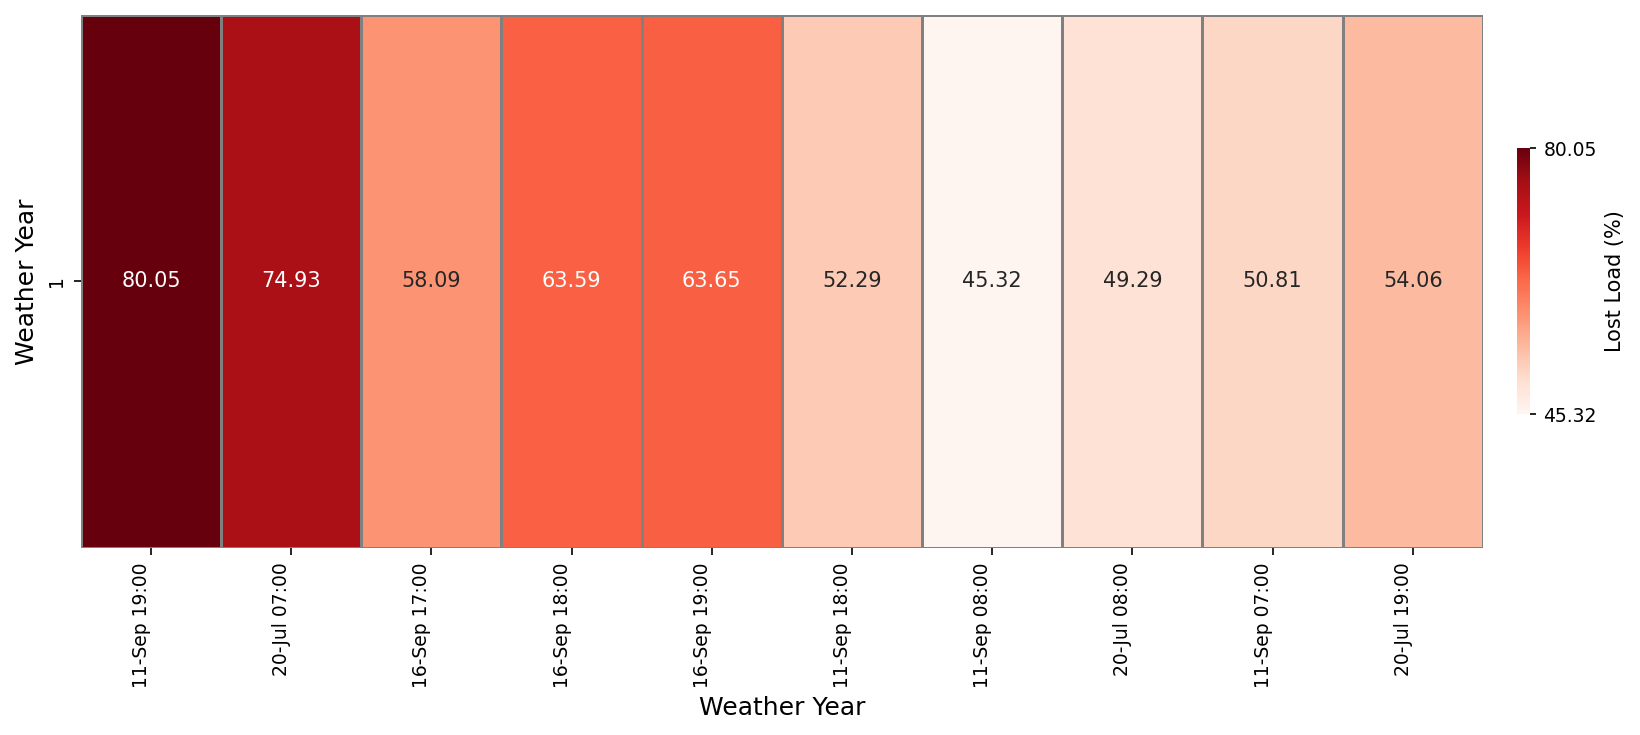

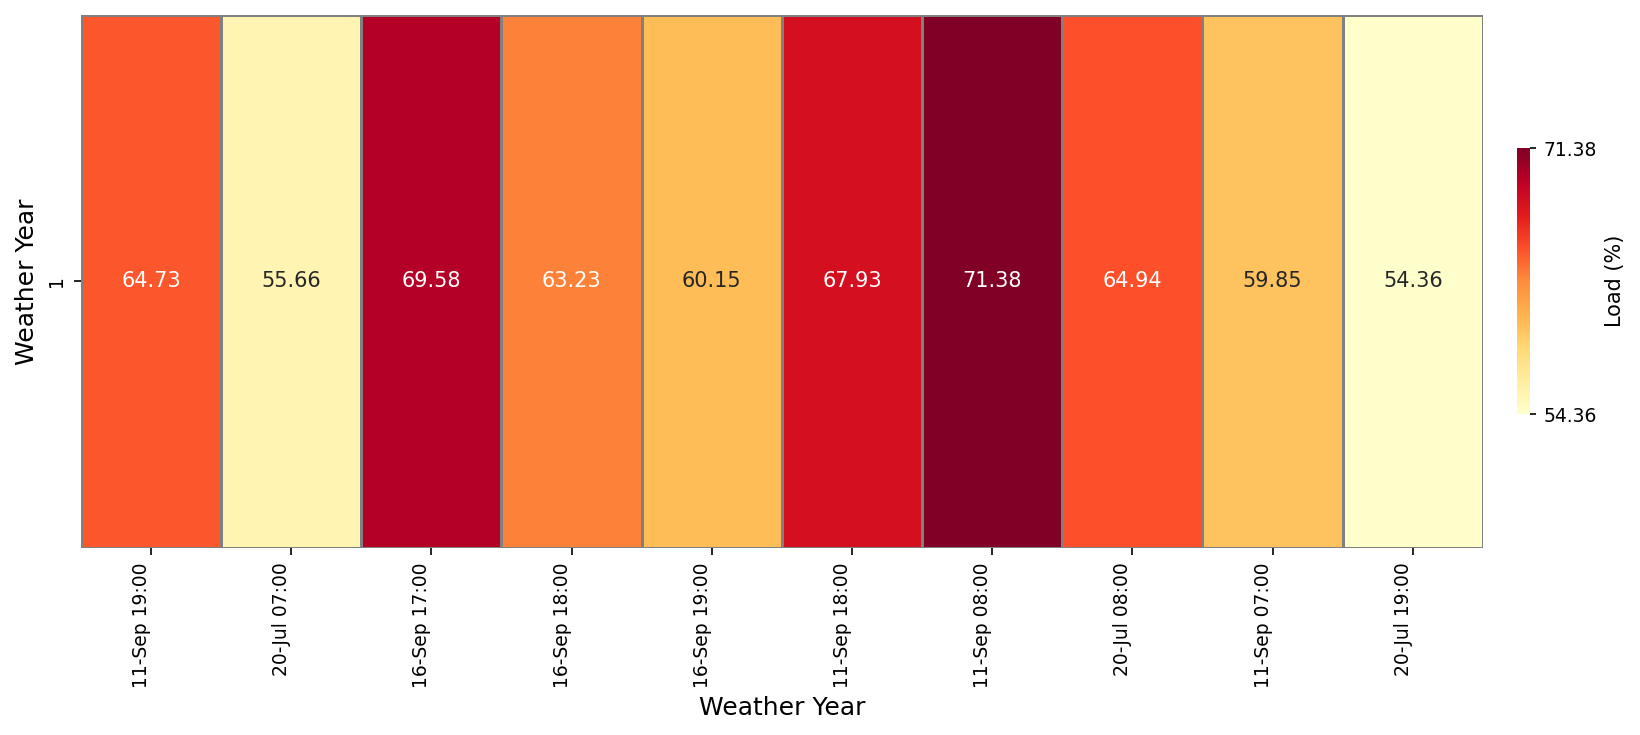

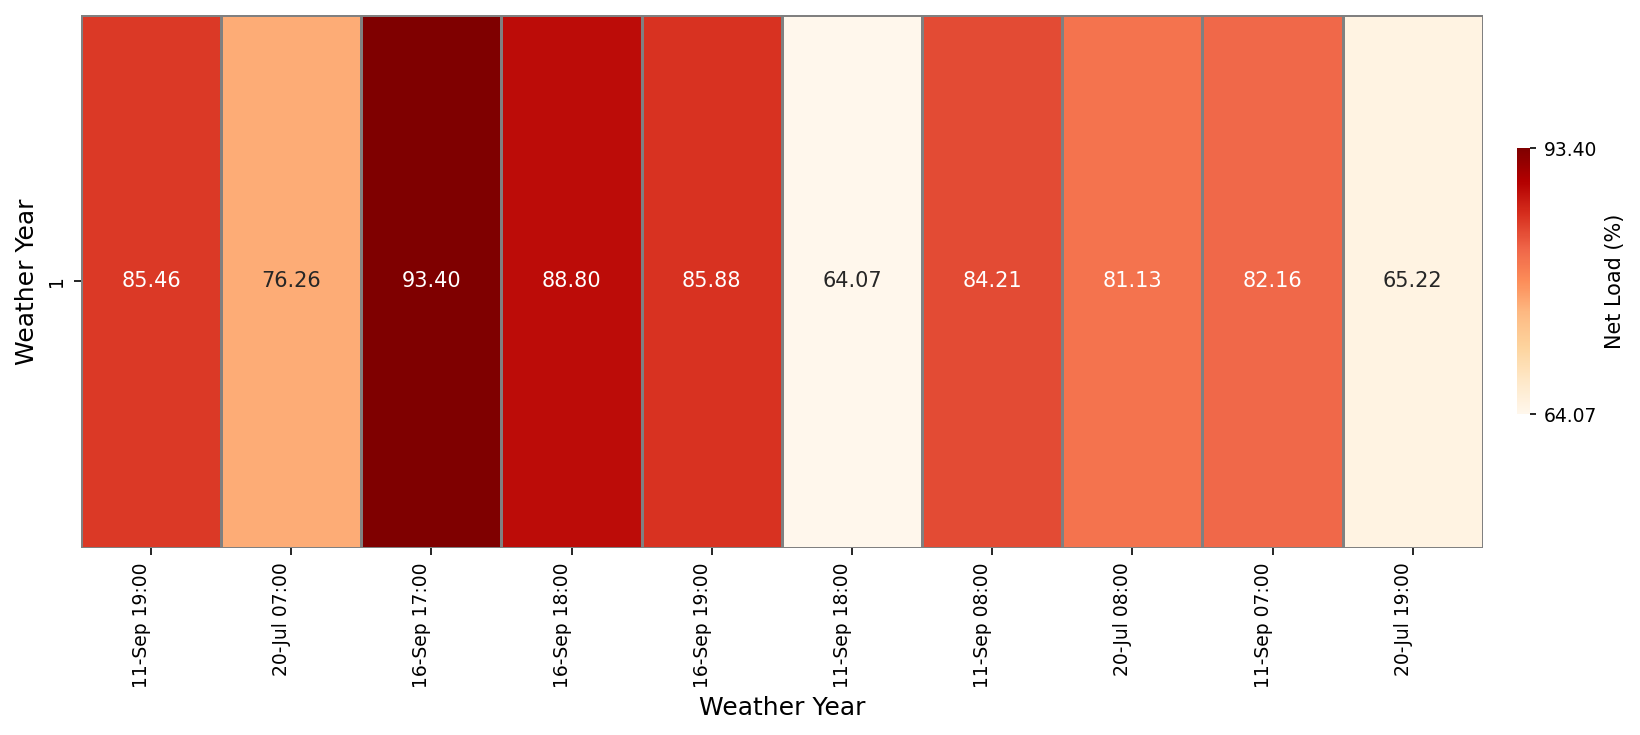

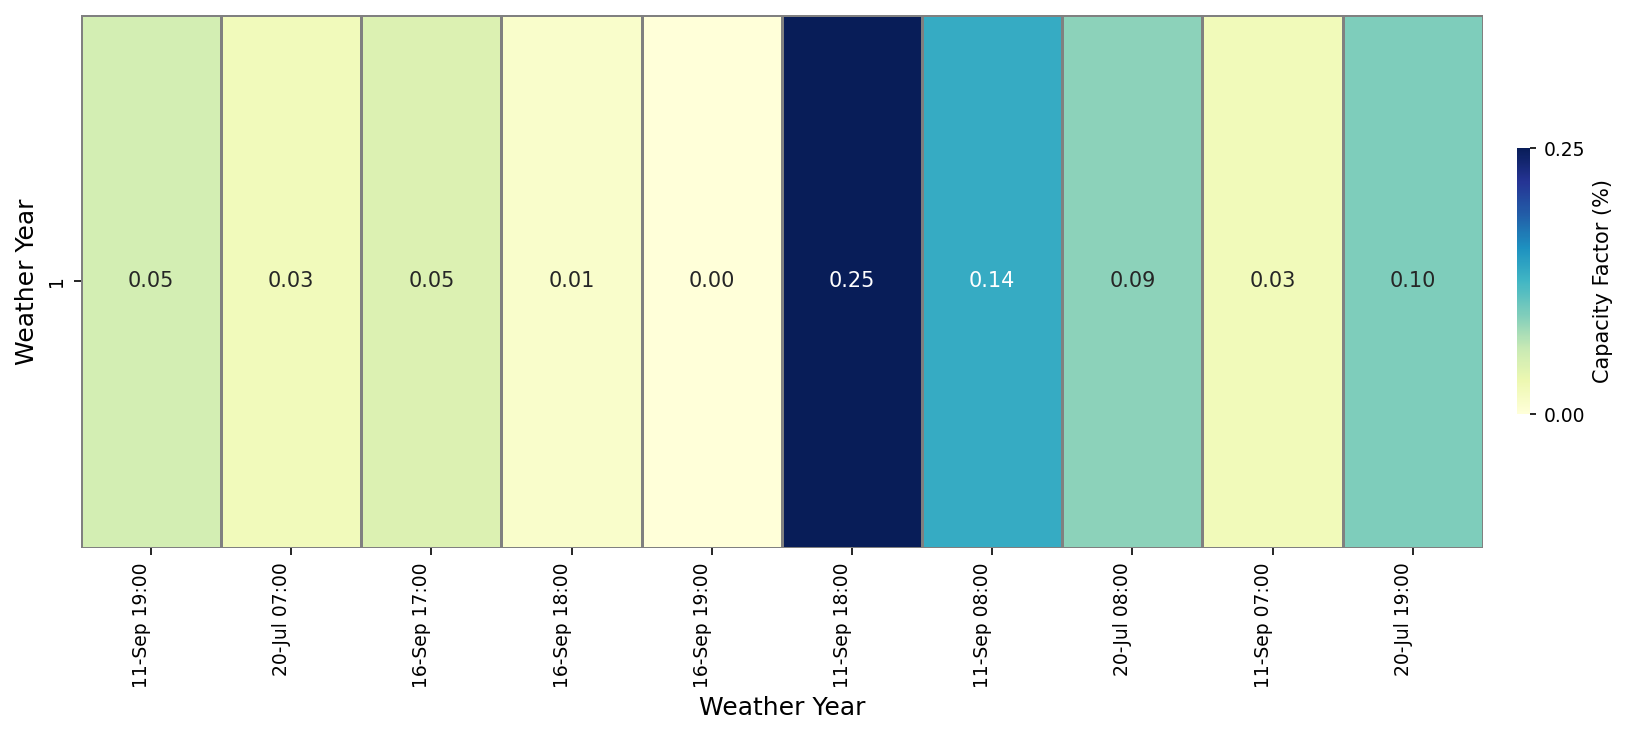

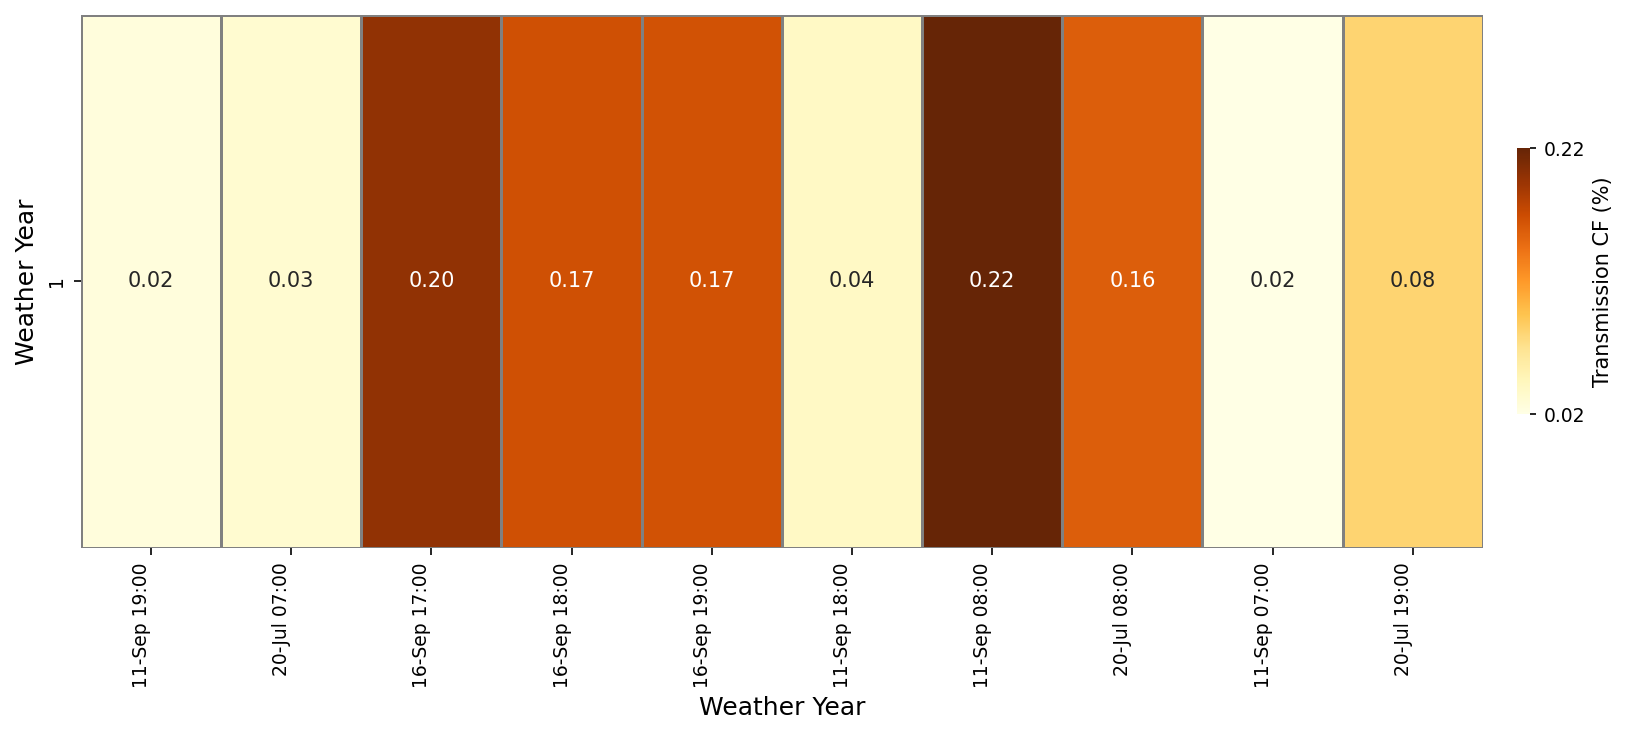

TypeError: Image data of dtype object cannot be converted to float

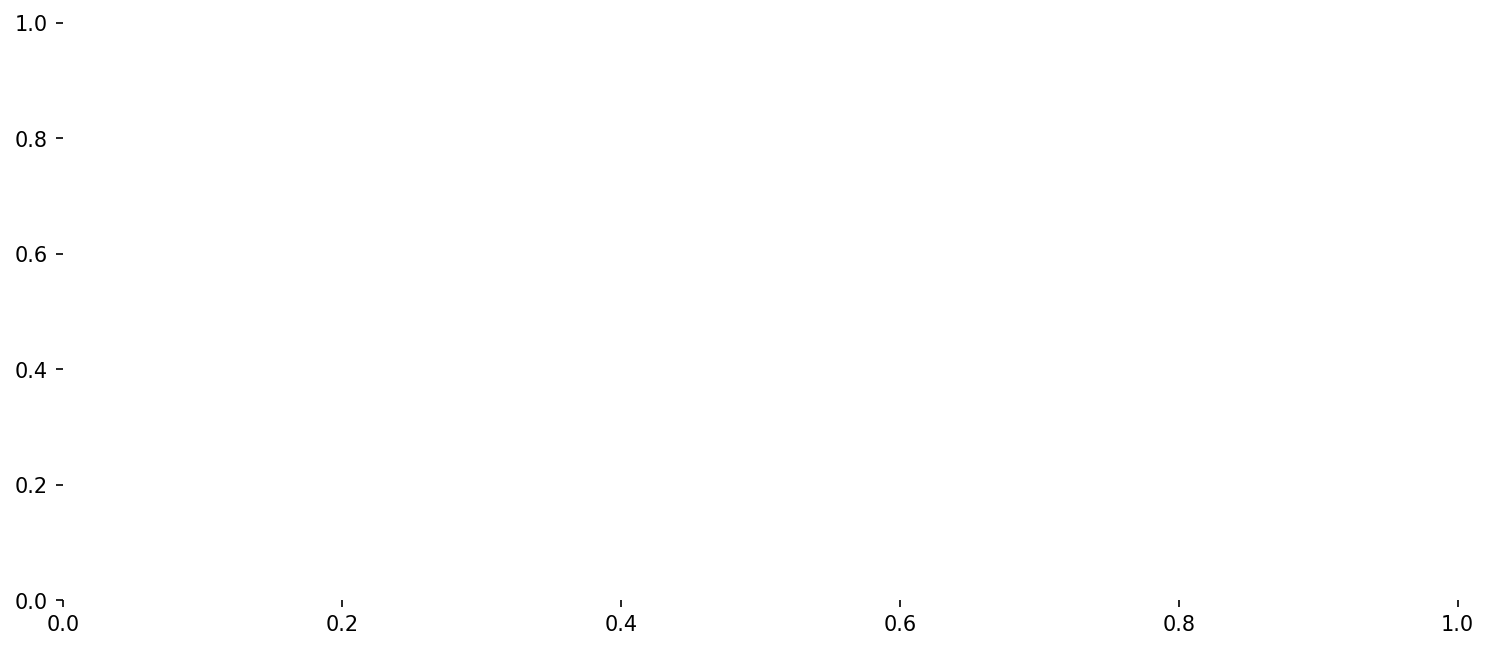

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ===============================================================
# 1️⃣  Select Top 10 timestamps with highest total unserved energy
# ===============================================================
top10_timestamps = (
    events_zone.groupby('timestamp')['unserved_energy']
    .sum()
    .nlargest(10)
    .index
)

df_top = events_zone[events_zone['timestamp'].isin(top10_timestamps)].copy()

# ===============================================================
# 2️⃣  Assign Iteration Numbers (Weather Year)
# ===============================================================
unique_iters = (
    df_top[['W', 'H', 'A']]
    .drop_duplicates()
    .sort_values(['W', 'H', 'A'])
    .reset_index(drop=True)
)
unique_iters['iteration'] = range(1, len(unique_iters) + 1)
df_top = pd.merge(df_top, unique_iters, on=['W', 'H', 'A'], how='left')

# ===============================================================
# 3️⃣  Format Timestamp Labels (dd-mmm HH:MM)
# ===============================================================
df_top['timestamp_label'] = df_top['timestamp'].dt.strftime("%d-%b %H:%M")

# Consistent column order
timestamp_order = (
    df_top.groupby('timestamp_label')['unserved_energy']
    .sum()
    .sort_values(ascending=False)
    .index
)

# ===============================================================
# 4️⃣  Generic plotting function using the same lost-load mask
# ===============================================================
def plot_metric_heatmap(df, metric, cmap, label):
    """Plot metric heatmap; mask out all cells with no lost load."""
    if metric not in df.columns:
        print(f"⚠️  '{metric}' not found — skipping.")
        return

    # pivot for metric
    heat_data = df.pivot_table(
        index='iteration',
        columns='timestamp_label',
        values=metric,
        aggfunc='mean'
    )

    # pivot for lost_load mask
    mask_data = df.pivot_table(
        index='iteration',
        columns='timestamp_label',
        values='lost_load_pct',
        aggfunc='mean'
    )

    # same order of columns
    heat_data = heat_data.reindex(columns=timestamp_order)
    mask_data = mask_data.reindex(columns=timestamp_order)

    # mask everywhere lost_load_pct <= 0 or NaN
    mask = (mask_data <= 0) | (mask_data.isna())

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(12, 5), dpi=150)
    vmin, vmax = np.nanmin(heat_data.values), np.nanmax(heat_data.values)

    hm = sns.heatmap(
        heat_data,
        mask=mask,
        cmap=cmap,
        annot=True, fmt=".2f",
        linewidths=0.5, linecolor='grey',
        cbar=True,
        cbar_kws={"orientation": "vertical", "pad": 0.02, "shrink": 0.5}
    )

    # compact colorbar
    cbar = hm.collections[0].colorbar
    cbar.set_ticks([vmin, vmax])
    cbar.set_ticklabels([f"{vmin:.2f}", f"{vmax:.2f}"])
    cbar.ax.tick_params(labelsize=9, length=3)
    cbar.set_label(label, fontsize=10)

    ax.set_xlabel("Weather Year", fontsize=12)
    ax.set_ylabel("Weather Year", fontsize=12)
    plt.xticks(rotation=90, ha='right', fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.show()


# ===============================================================
# 5️⃣  Generate all heatmaps — all masked by lost_load_pct
# ===============================================================
plot_metric_heatmap(df_top, 'lost_load_pct', 'Reds', 'Lost Load (%)')
plot_metric_heatmap(df_top, 'load_pct', 'YlOrRd', 'Load (%)')
plot_metric_heatmap(df_top, 'net_load_pct', 'OrRd', 'Net Load (%)')
plot_metric_heatmap(df_top, 'capacity_factor', 'YlGnBu', 'Capacity Factor (%)')
plot_metric_heatmap(df_top, 'tx_cap_factor', 'YlOrBr', 'Transmission CF (%)')
plot_metric_heatmap(df_top, 'thermal_availability_factor', 'PuBu', 'Thermal Availability (%)')

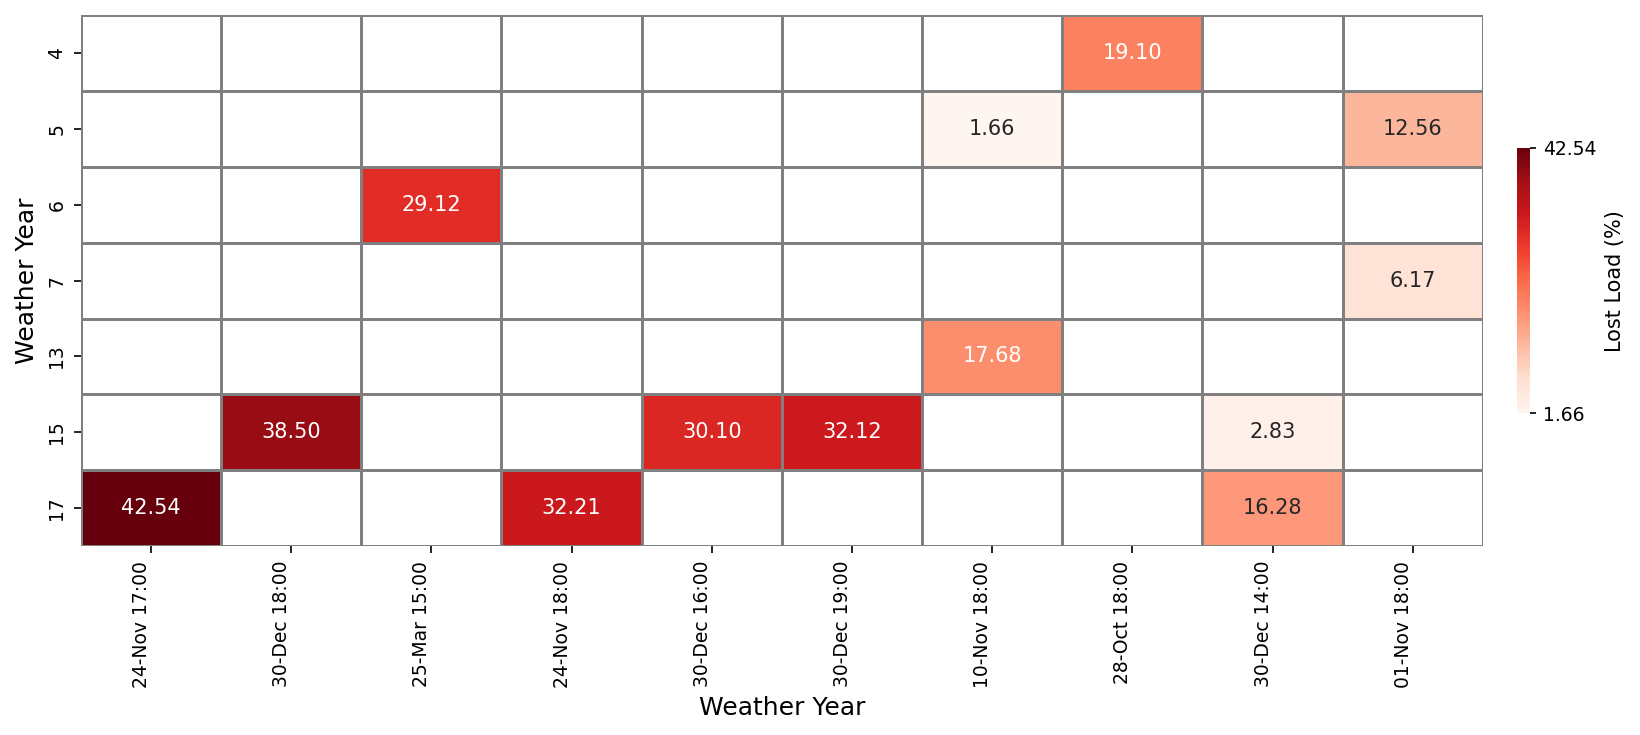

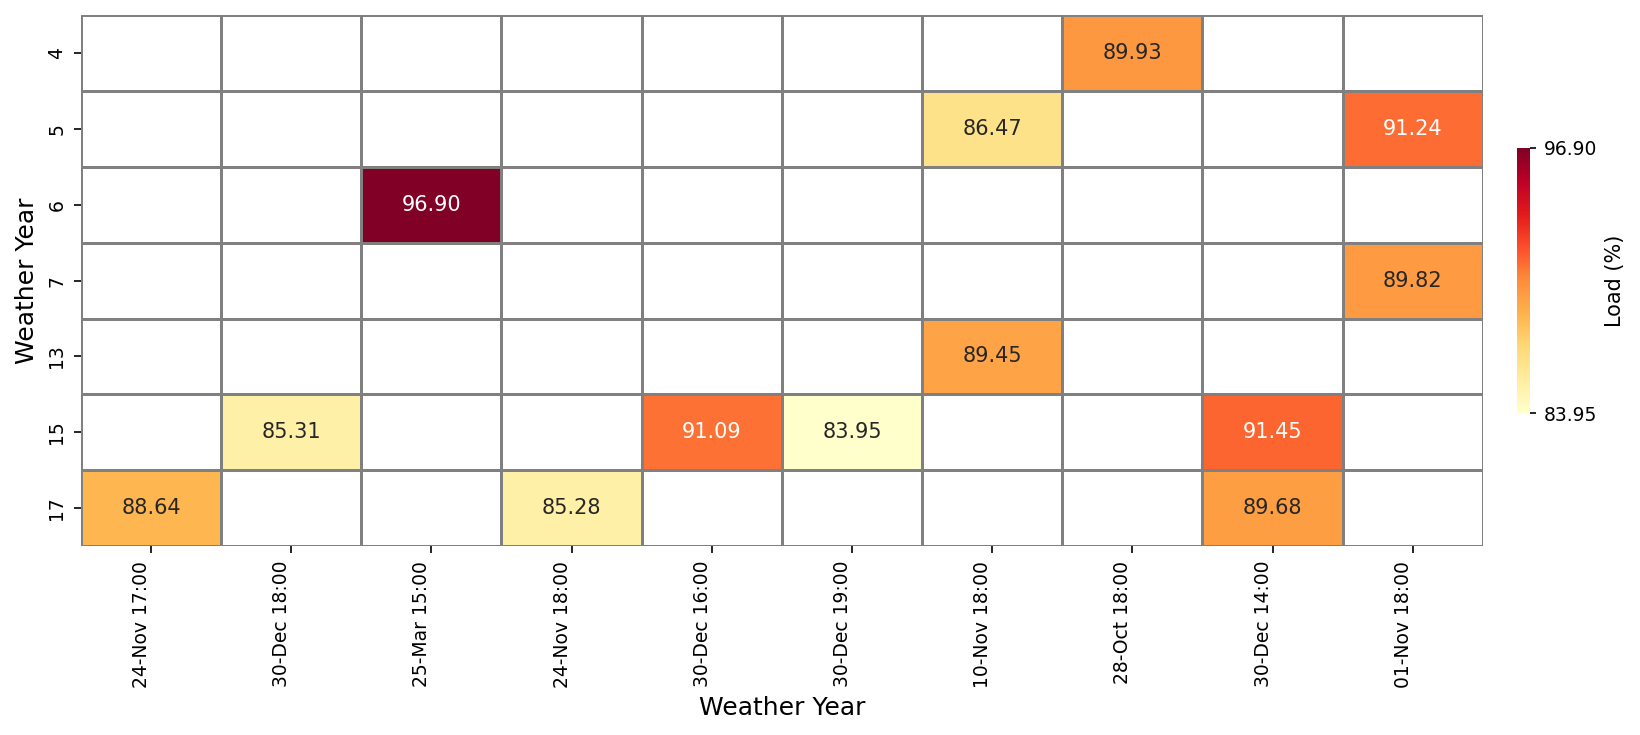

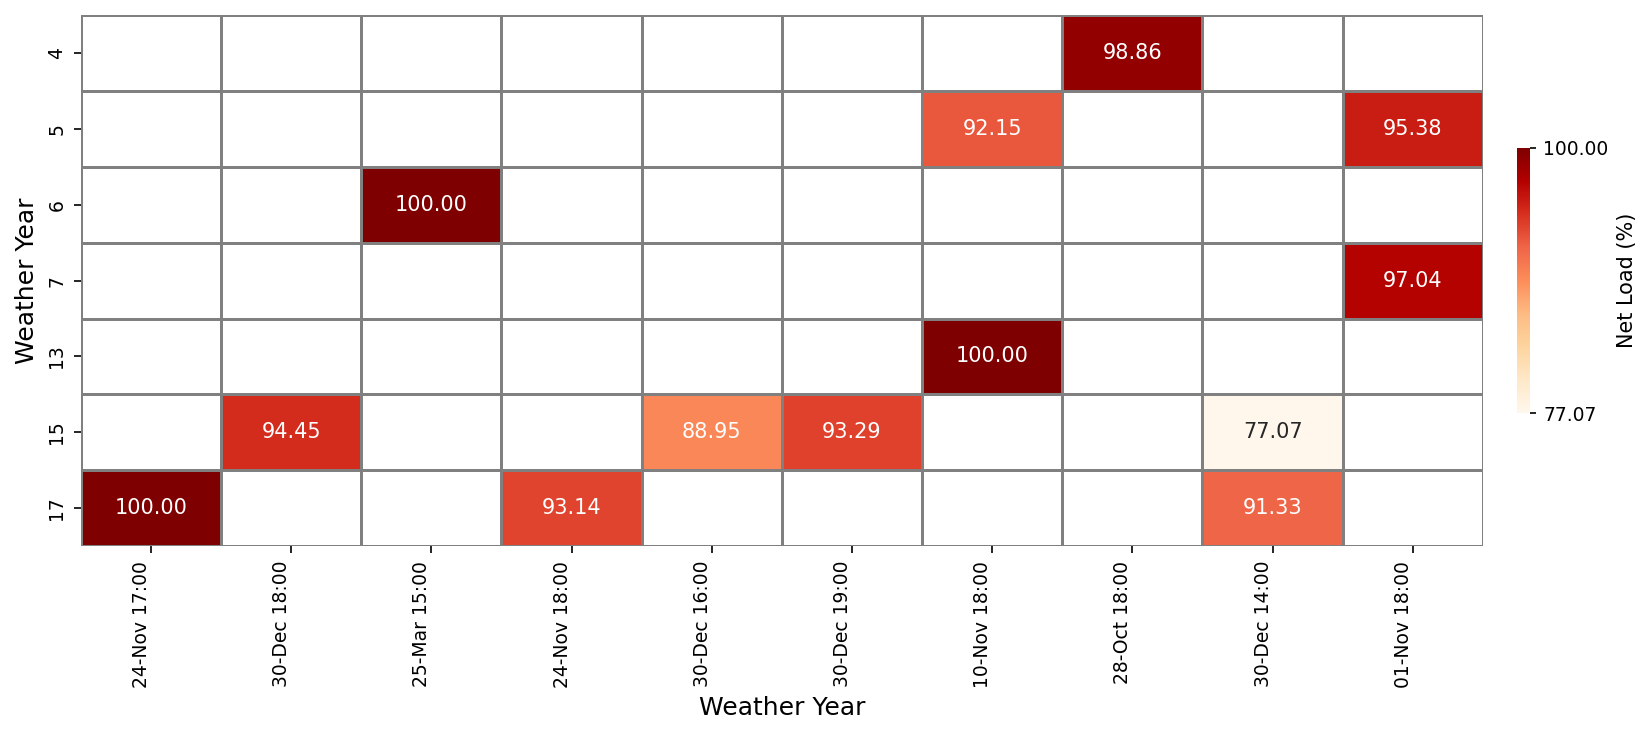

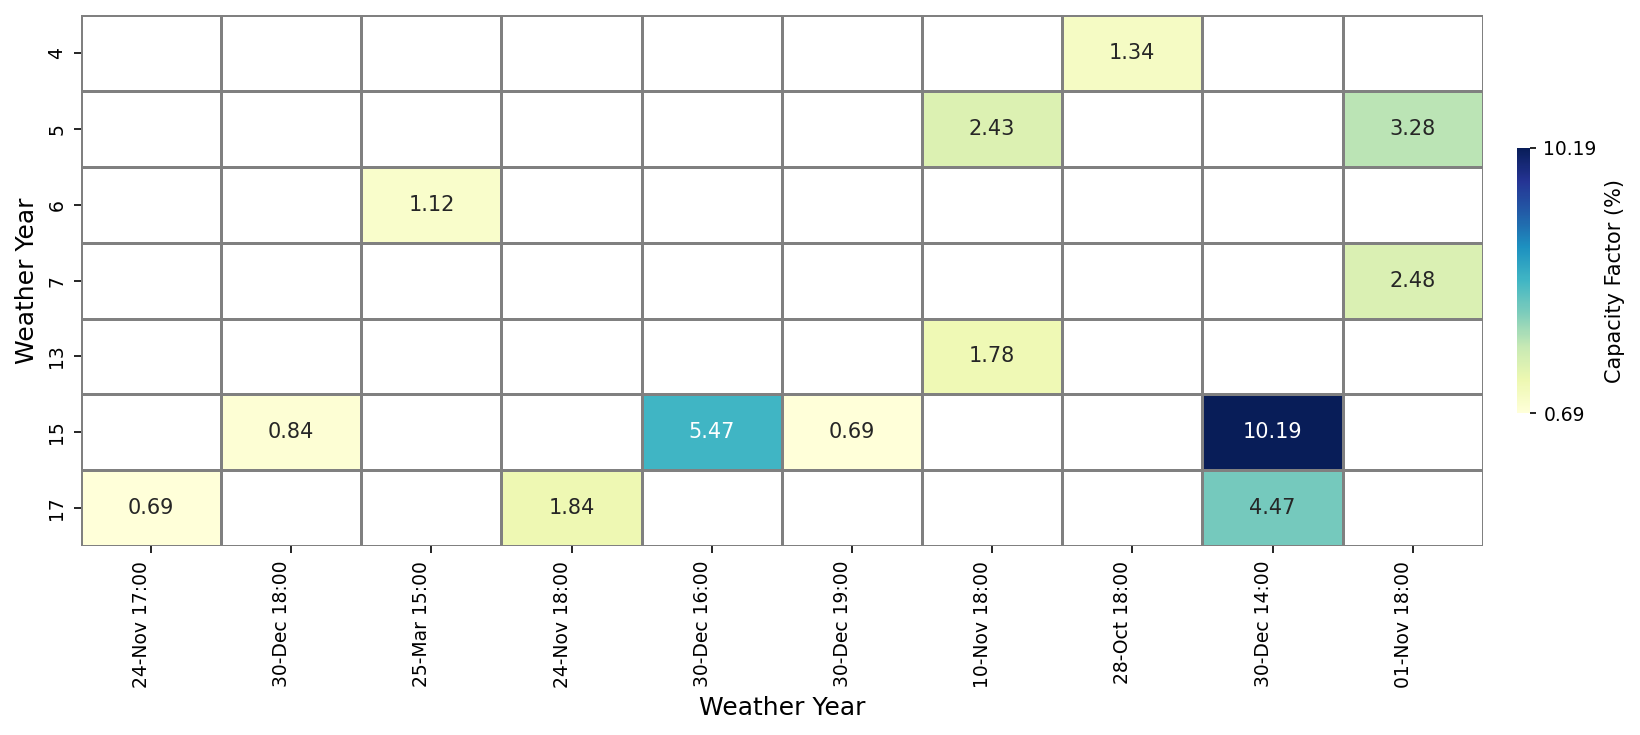

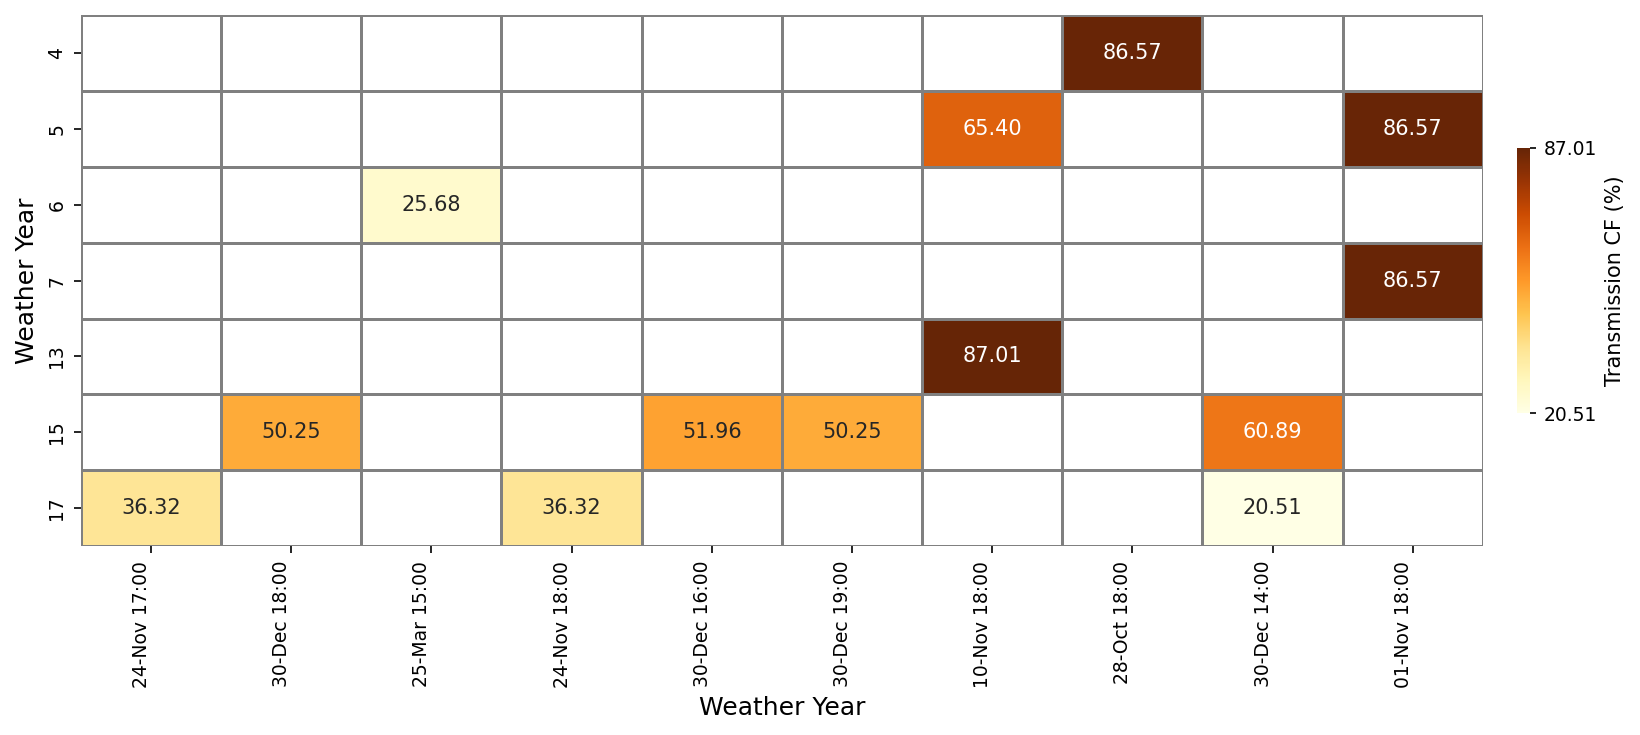

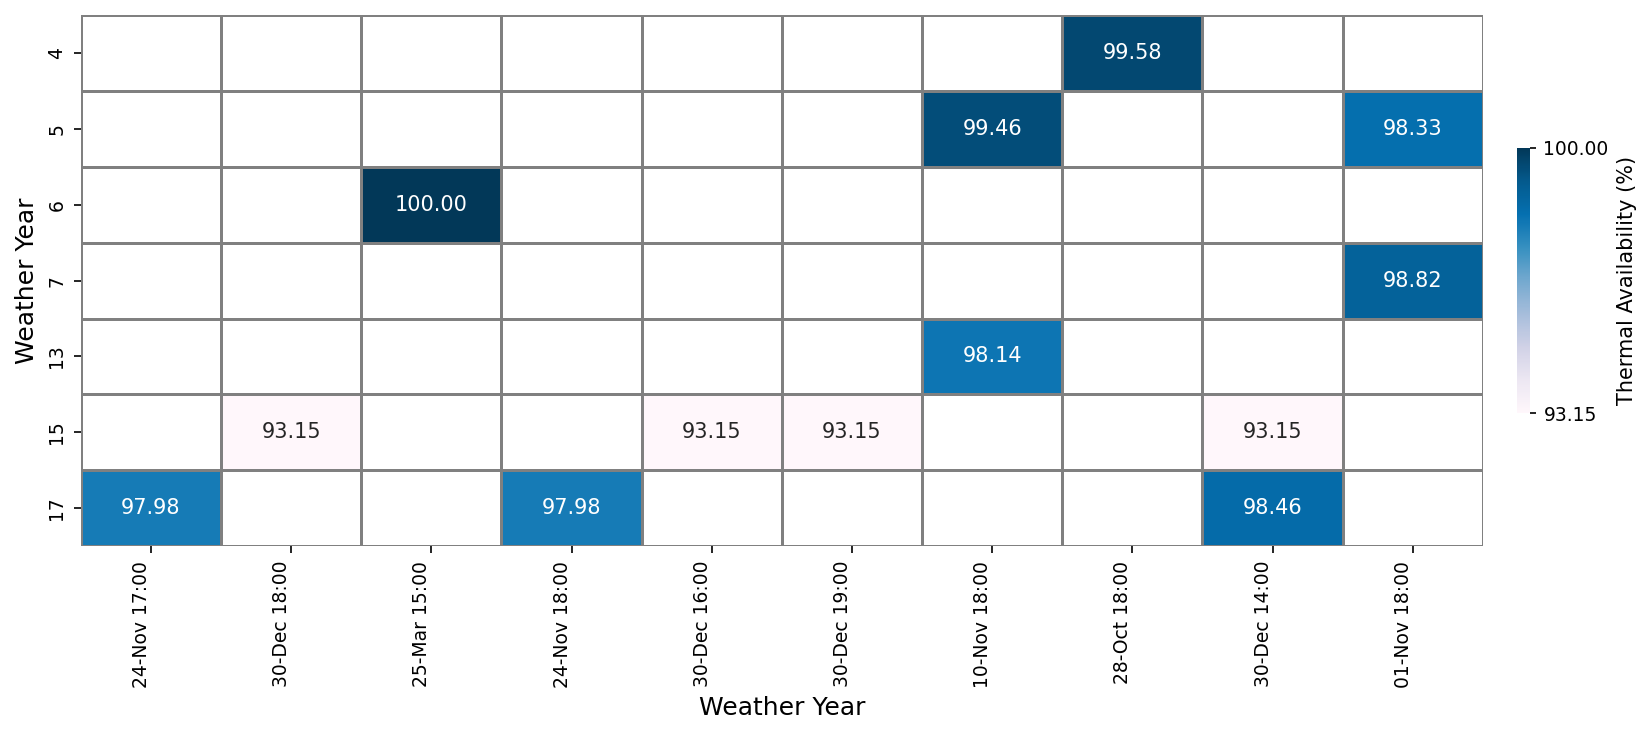

: 

: 

In [ ]:

# ===============================================================
# 1️⃣  Select Top 10 timestamps with highest total unserved energy
# ===============================================================
top10_timestamps = (
    events_zone.groupby('timestamp')['unserved_energy']
    .sum()
    .nlargest(10)
    .index
)

df_top = events_zone[events_zone['timestamp'].isin(top10_timestamps)].copy()

# ===============================================================
# 2️⃣  Assign Iteration Numbers (Weather Year)
# ===============================================================
unique_iters = (
    df_top[['W', 'H', 'A']]
    .drop_duplicates()
    .sort_values(['W', 'H', 'A'])
    .reset_index(drop=True)
)
unique_iters['iteration'] = range(1, len(unique_iters) + 1)
df_top = pd.merge(df_top, unique_iters, on=['W', 'H', 'A'], how='left')

# ===============================================================
# 3️⃣  Format Timestamp Labels (dd-mmm HH:MM)
# ===============================================================
df_top['timestamp_label'] = df_top['timestamp'].dt.strftime("%d-%b %H:%M")

# Order timestamps by total unserved_energy descending
timestamp_order = (
    df_top.groupby('timestamp_label')['unserved_energy']
    .sum()
    .sort_values(ascending=False)
    .index
)

# ===============================================================
# 4️⃣  Scale factor columns to percentages (if present)
# ===============================================================
for col in ['capacity_factor', 'tx_cap_factor', 'thermal_availability_factor']:
    if col in df_top.columns:
        df_top[col] = df_top[col] * 100.0

# ===============================================================
# 5️⃣  Generic plotting function (clean colorbar & correct masking)
# ===============================================================
def plot_metric_heatmap(df, metric, cmap, label):
    """Plot metric heatmap; drop no-lost-load iterations, scale factors, fix colorbar."""
    if metric not in df.columns:
        print(f"⚠️  '{metric}' not found — skipping.")
        return

    # --- Pivot tables for metric and lost_load mask ---
    heat_data = df.pivot_table(
        index='iteration',
        columns='timestamp_label',
        values=metric,
        aggfunc='mean'
    )
    lost_data = df.pivot_table(
        index='iteration',
        columns='timestamp_label',
        values='lost_load_pct',
        aggfunc='mean'
    )

    # Reorder columns
    heat_data = heat_data.reindex(columns=timestamp_order)
    lost_data = lost_data.reindex(columns=timestamp_order)

    # --- Keep only iterations with any lost load ---
    keep_iters = (lost_data > 0).any(axis=1)
    heat_data = heat_data.loc[keep_iters]
    lost_data = lost_data.loc[keep_iters]

    # --- Mask cells where lost_load_pct ≤ 0 ---
    mask = (lost_data <= 0) | (lost_data.isna())

    # --- Compute vmin/vmax based only on visible (unmasked) data ---
    visible_values = heat_data.mask(mask)
    if visible_values.notna().sum().sum() == 0:
        print(f"⚠️  No valid (positive lost load) data for '{metric}' — skipping.")
        return
    vmin, vmax = visible_values.min().min(), visible_values.max().max()

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

    hm = sns.heatmap(
        heat_data,
        mask=mask,
        cmap=cmap,
        annot=True, fmt=".2f",
        linewidths=0.5, linecolor='grey',
        cbar=True,
        vmin=vmin, vmax=vmax,
        cbar_kws={"orientation": "vertical", "pad": 0.02, "shrink": 0.5}
    )

    # Compact colorbar (min/max only of visible data)
    cbar = hm.collections[0].colorbar
    cbar.set_ticks([vmin, vmax])
    cbar.set_ticklabels([f"{vmin:.2f}", f"{vmax:.2f}"])
    cbar.ax.tick_params(labelsize=9, length=3)
    cbar.set_label(label, fontsize=10)

    # --- Axis labels ---
    ax.set_xlabel("Weather Year", fontsize=12)
    ax.set_ylabel("Weather Year", fontsize=12)
    plt.xticks(rotation=90, ha='right', fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.show()


# ===============================================================
# 6️⃣  Generate all heatmaps (only for iterations with lost load)
# ===============================================================
plot_metric_heatmap(df_top, 'lost_load_pct', 'Reds', 'Lost Load (%)')
plot_metric_heatmap(df_top, 'load_pct', 'YlOrRd', 'Load (%)')
plot_metric_heatmap(df_top, 'net_load_pct', 'OrRd', 'Net Load (%)')
plot_metric_heatmap(df_top, 'capacity_factor', 'YlGnBu', 'Capacity Factor (%)')
plot_metric_heatmap(df_top, 'tx_cap_factor', 'YlOrBr', 'Transmission CF (%)')
plot_metric_heatmap(df_top, 'thermal_availability_factor', 'PuBu', 'Thermal Availability (%)')

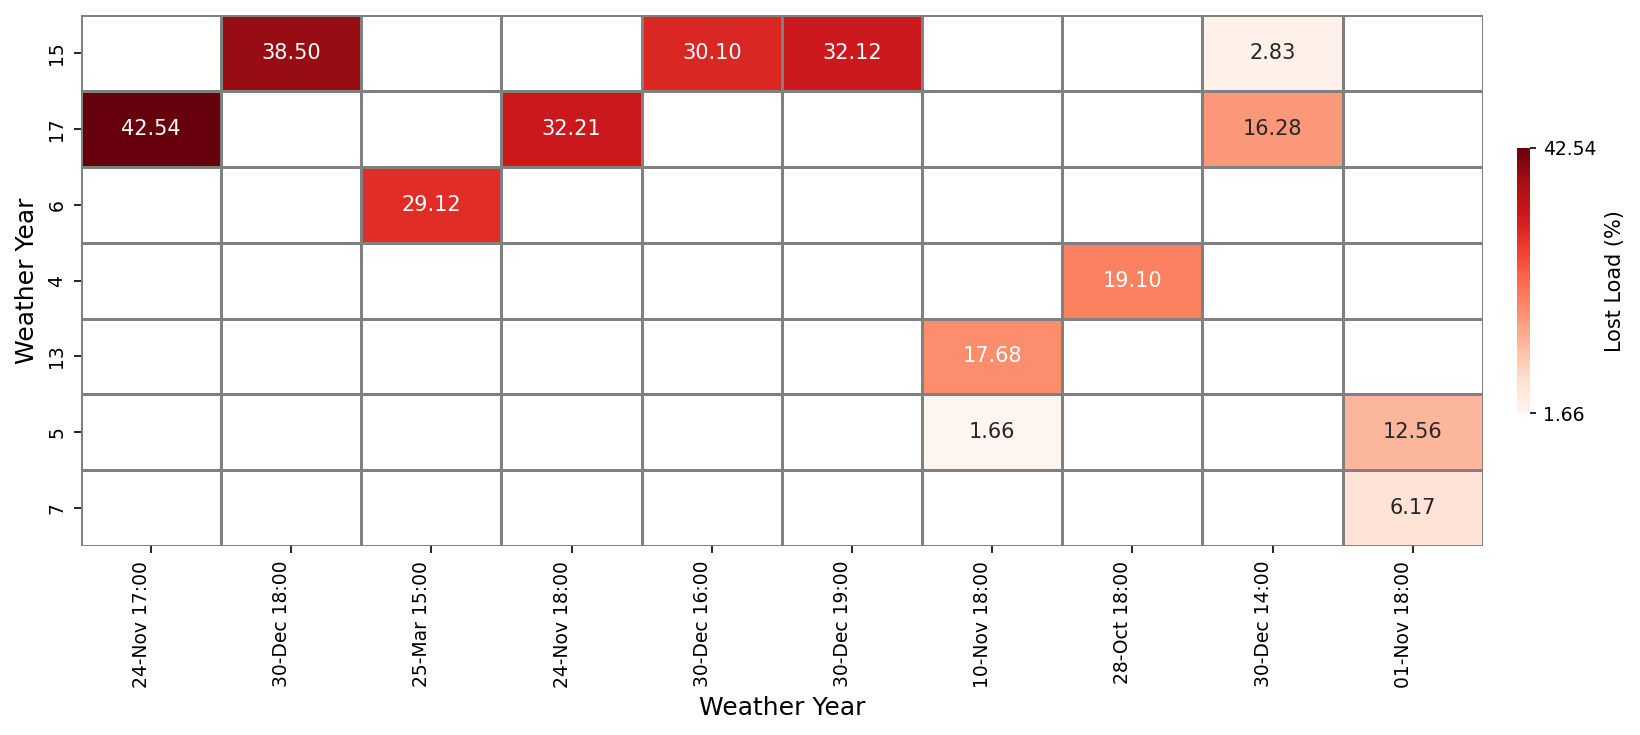

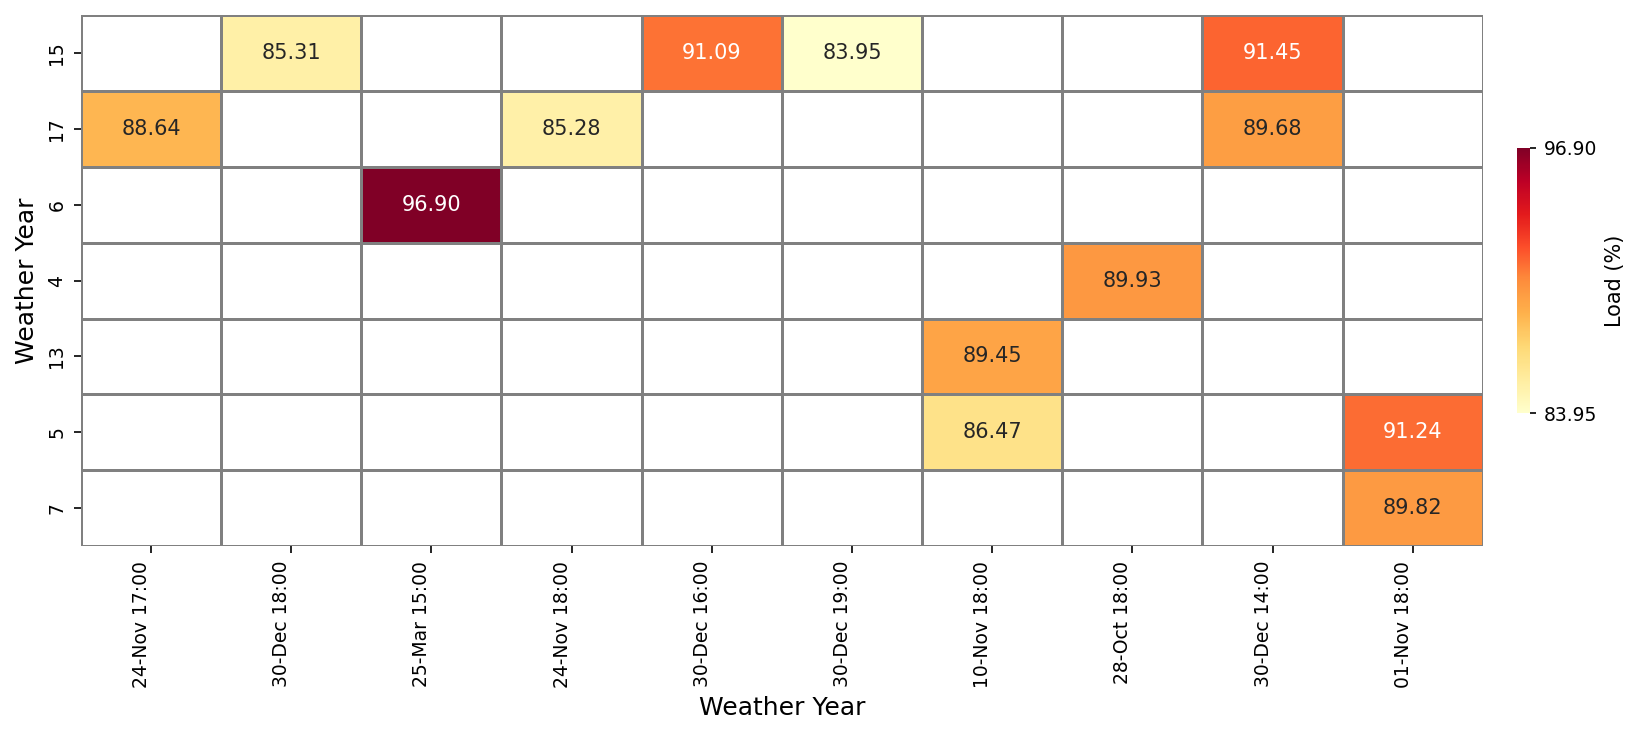

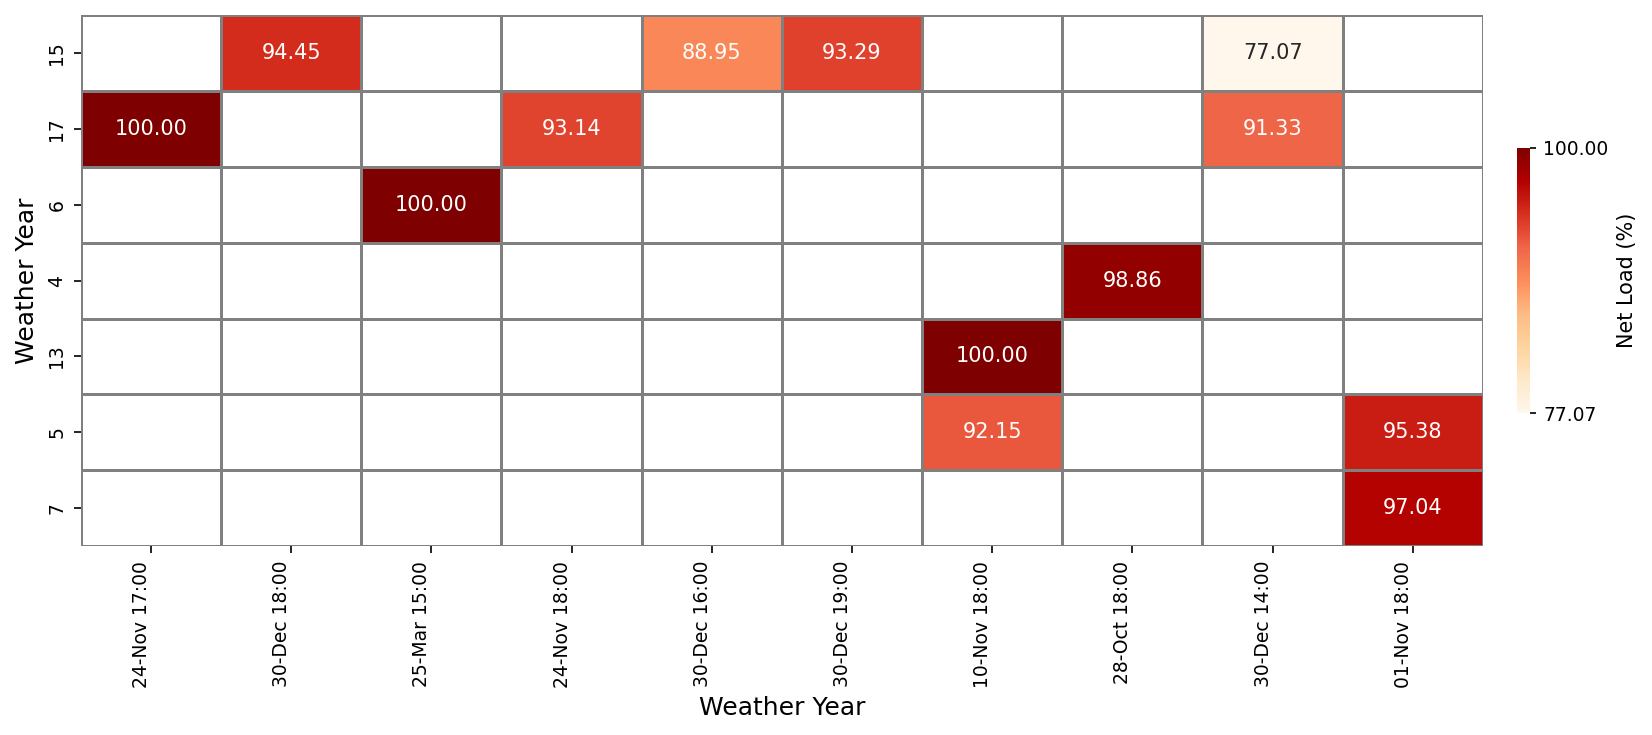

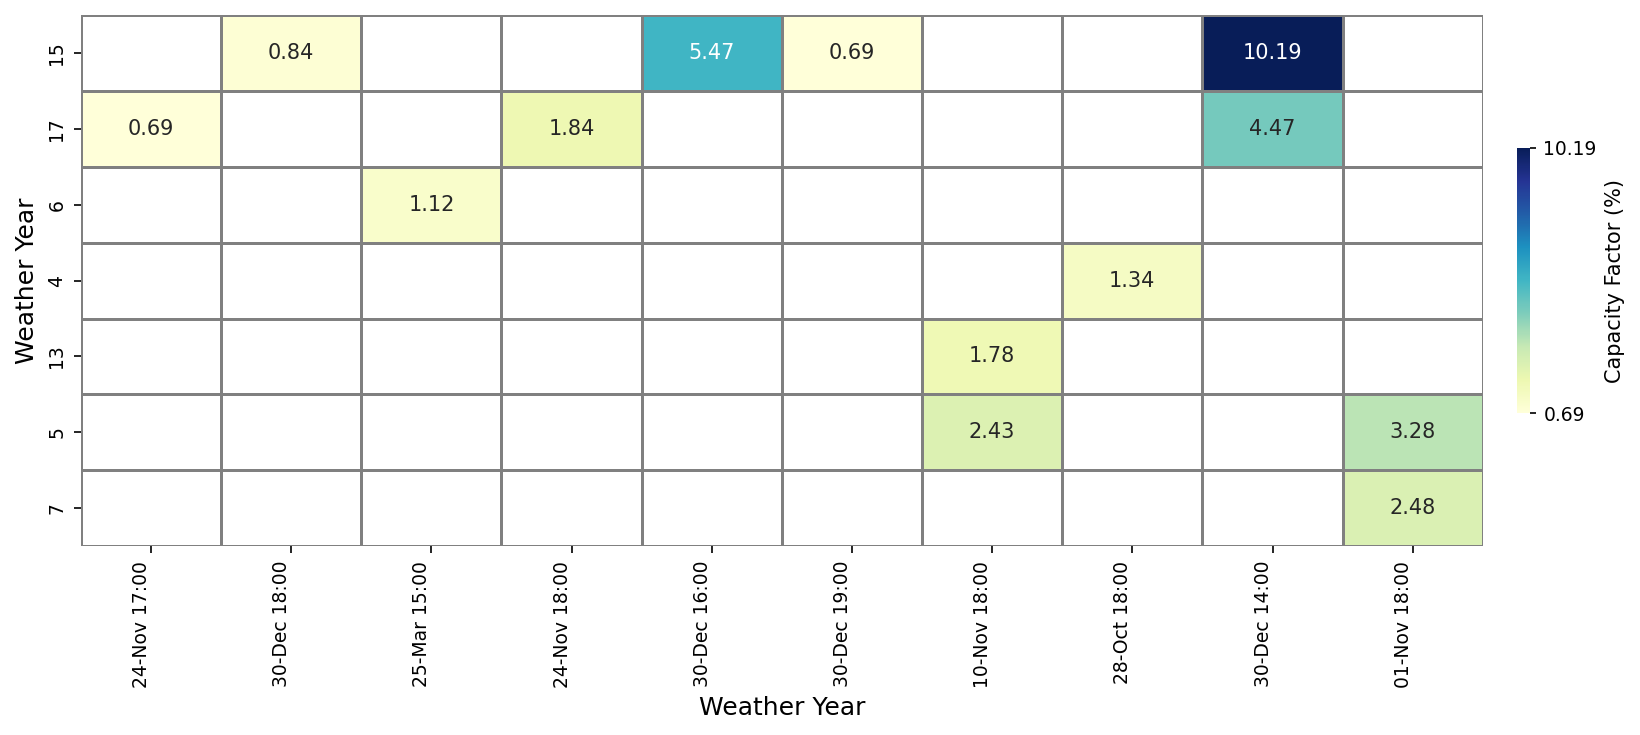

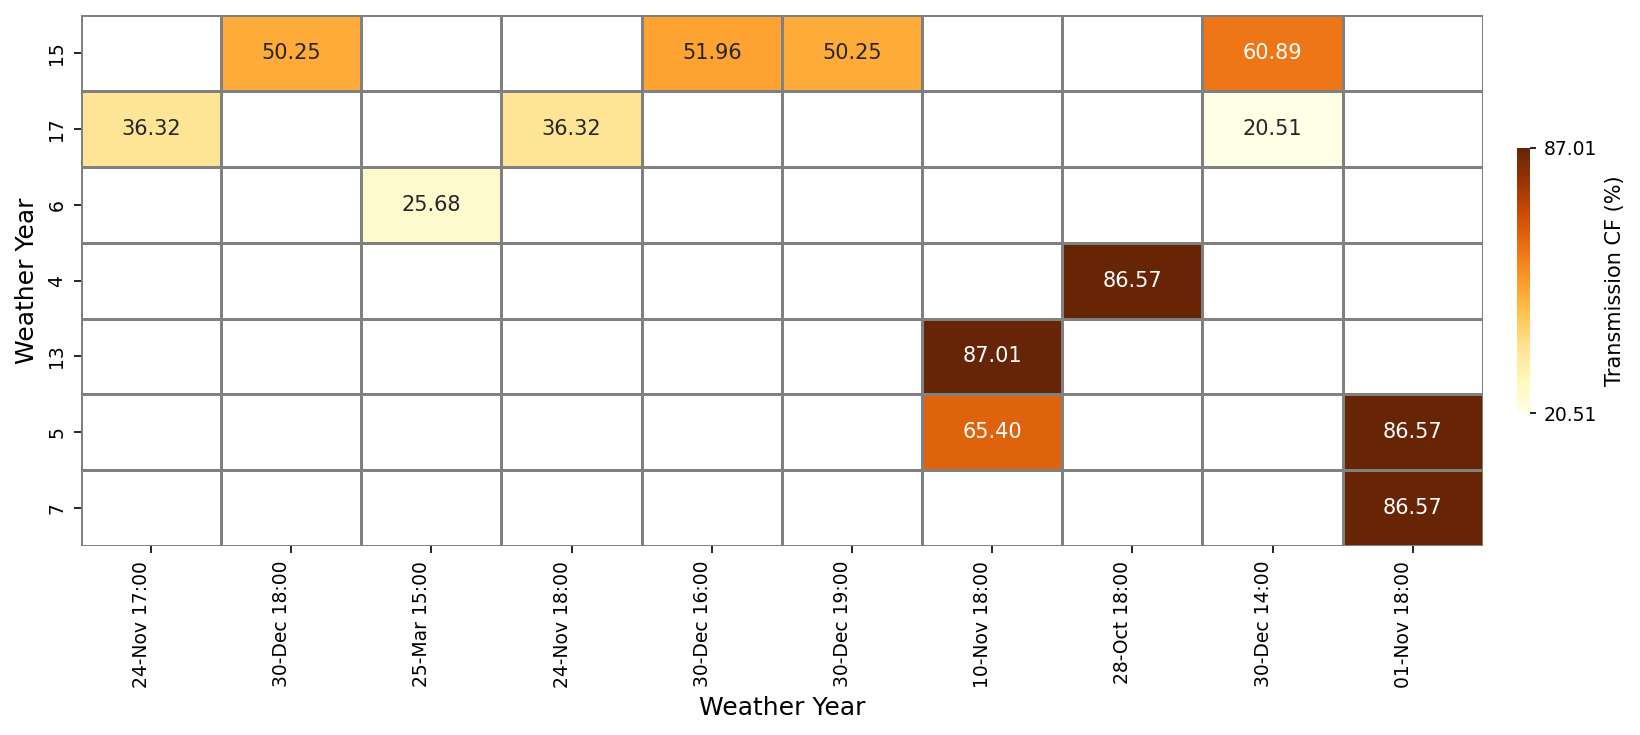

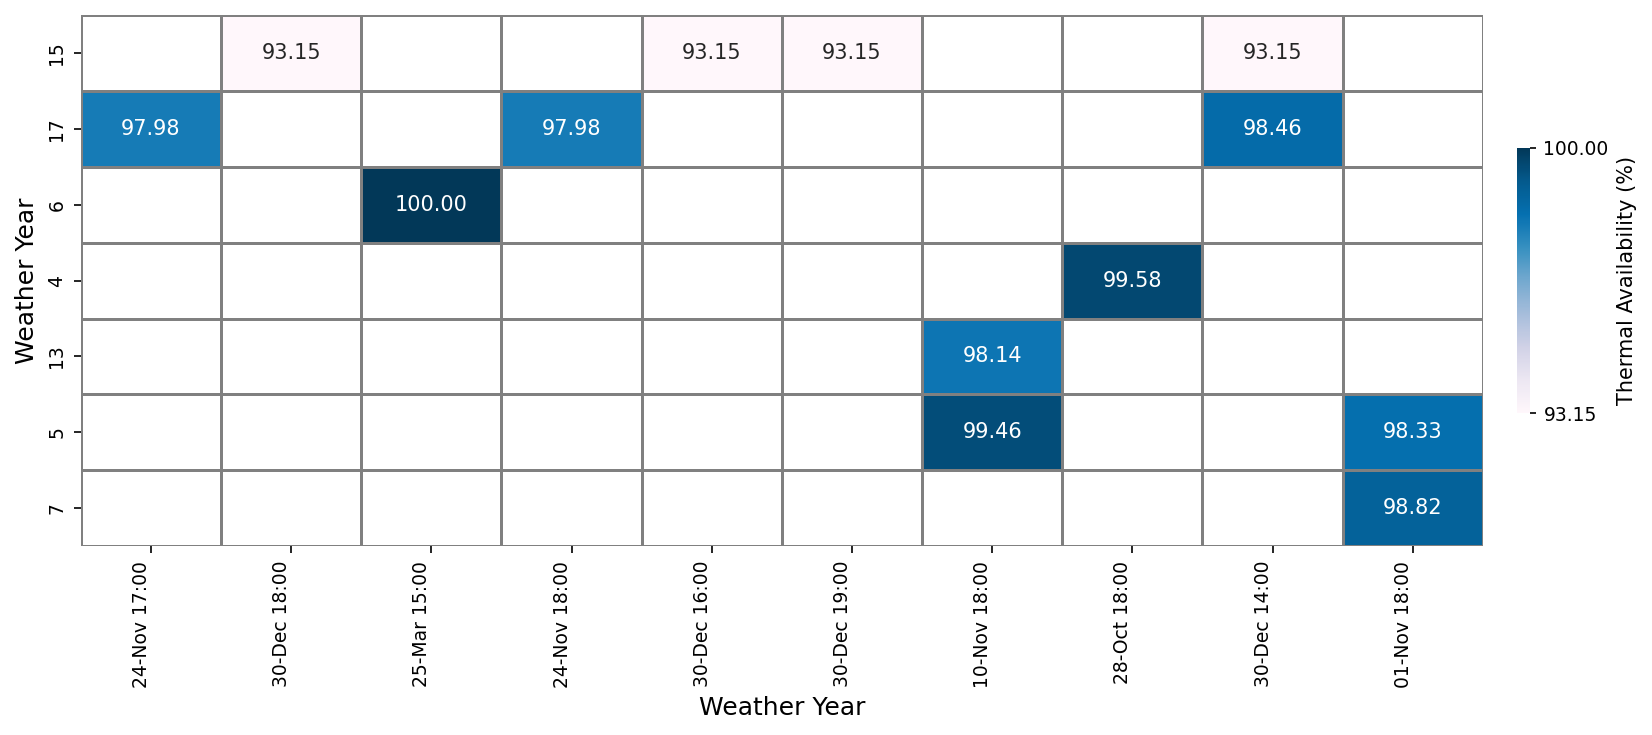

: 

: 

In [ ]:


# ===============================================================
# 1️⃣  Select Top 10 timestamps with highest total unserved energy
# ===============================================================
top10_timestamps = (
    events_zone.groupby('timestamp')['unserved_energy']
    .sum()
    .nlargest(10)
    .index
)

df_top = events_zone[events_zone['timestamp'].isin(top10_timestamps)].copy()

# ===============================================================
# 2️⃣  Assign Iteration Numbers (Weather Year)
# ===============================================================
unique_iters = (
    df_top[['W', 'H', 'A']]
    .drop_duplicates()
    .sort_values(['W', 'H', 'A'])
    .reset_index(drop=True)
)
unique_iters['iteration'] = range(1, len(unique_iters) + 1)
df_top = pd.merge(df_top, unique_iters, on=['W', 'H', 'A'], how='left')

# ===============================================================
# 3️⃣  Format Timestamp Labels (dd-mmm HH:MM)
# ===============================================================
df_top['timestamp_label'] = df_top['timestamp'].dt.strftime("%d-%b %H:%M")

# Order timestamps by total unserved_energy descending
timestamp_order = (
    df_top.groupby('timestamp_label')['unserved_energy']
    .sum()
    .sort_values(ascending=False)
    .index
)

# ===============================================================
# 4️⃣  Scale factor columns to percentages (if present)
# ===============================================================
for col in ['capacity_factor', 'tx_cap_factor', 'thermal_availability_factor']:
    if col in df_top.columns:
        df_top[col] = df_top[col] * 100.0

# ===============================================================
# 5️⃣  Generic plotting function (sorted by total Lost Load)
# ===============================================================
def plot_metric_heatmap(df, metric, cmap, label):
    """Plot metric heatmap; drop no-lost iterations, sort by total lost load, clean colorbar."""
    if metric not in df.columns:
        print(f"⚠️  '{metric}' not found — skipping.")
        return

    # --- Pivot tables for metric and lost_load mask ---
    heat_data = df.pivot_table(
        index='iteration',
        columns='timestamp_label',
        values=metric,
        aggfunc='mean'
    )
    lost_data = df.pivot_table(
        index='iteration',
        columns='timestamp_label',
        values='lost_load_pct',
        aggfunc='mean'
    )

    # Reorder columns
    heat_data = heat_data.reindex(columns=timestamp_order)
    lost_data = lost_data.reindex(columns=timestamp_order)

    # --- Drop iterations with no lost load ---
    keep_iters = (lost_data > 0).any(axis=1)
    heat_data = heat_data.loc[keep_iters]
    lost_data = lost_data.loc[keep_iters]

    # --- Sort iterations (rows) by total Lost Load (%) descending ---
    total_lost = lost_data.sum(axis=1)
    sorted_iters = total_lost.sort_values(ascending=False).index
    heat_data = heat_data.loc[sorted_iters]
    lost_data = lost_data.loc[sorted_iters]

    # --- Mask cells where lost_load_pct ≤ 0 ---
    mask = (lost_data <= 0) | (lost_data.isna())

    # --- Compute vmin/vmax based on visible data only ---
    visible_values = heat_data.mask(mask)
    if visible_values.notna().sum().sum() == 0:
        print(f"⚠️  No valid (positive lost load) data for '{metric}' — skipping.")
        return
    vmin, vmax = visible_values.min().min(), visible_values.max().max()

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

    hm = sns.heatmap(
        heat_data,
        mask=mask,
        cmap=cmap,
        annot=True, fmt=".2f",
        linewidths=0.5, linecolor='grey',
        cbar=True,
        vmin=vmin, vmax=vmax,
        cbar_kws={"orientation": "vertical", "pad": 0.02, "shrink": 0.5}
    )

    # --- Compact colorbar (min/max only of visible data) ---
    cbar = hm.collections[0].colorbar
    cbar.set_ticks([vmin, vmax])
    cbar.set_ticklabels([f"{vmin:.2f}", f"{vmax:.2f}"])
    cbar.ax.tick_params(labelsize=9, length=3)
    cbar.set_label(label, fontsize=10)

    # --- Axis labels ---
    ax.set_xlabel("Weather Year", fontsize=12)
    ax.set_ylabel("Weather Year", fontsize=12)
    plt.xticks(rotation=90, ha='right', fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.show()


# ===============================================================
# 6️⃣  Generate all heatmaps (sorted by Lost Load %, masked cleanly)
# ===============================================================
plot_metric_heatmap(df_top, 'lost_load_pct', 'Reds', 'Lost Load (%)')
plot_metric_heatmap(df_top, 'load_pct', 'YlOrRd', 'Load (%)')
plot_metric_heatmap(df_top, 'net_load_pct', 'OrRd', 'Net Load (%)')
plot_metric_heatmap(df_top, 'capacity_factor', 'YlGnBu', 'Capacity Factor (%)')
plot_metric_heatmap(df_top, 'tx_cap_factor', 'YlOrBr', 'Transmission CF (%)')
plot_metric_heatmap(df_top, 'thermal_availability_factor', 'PuBu', 'Thermal Availability (%)')

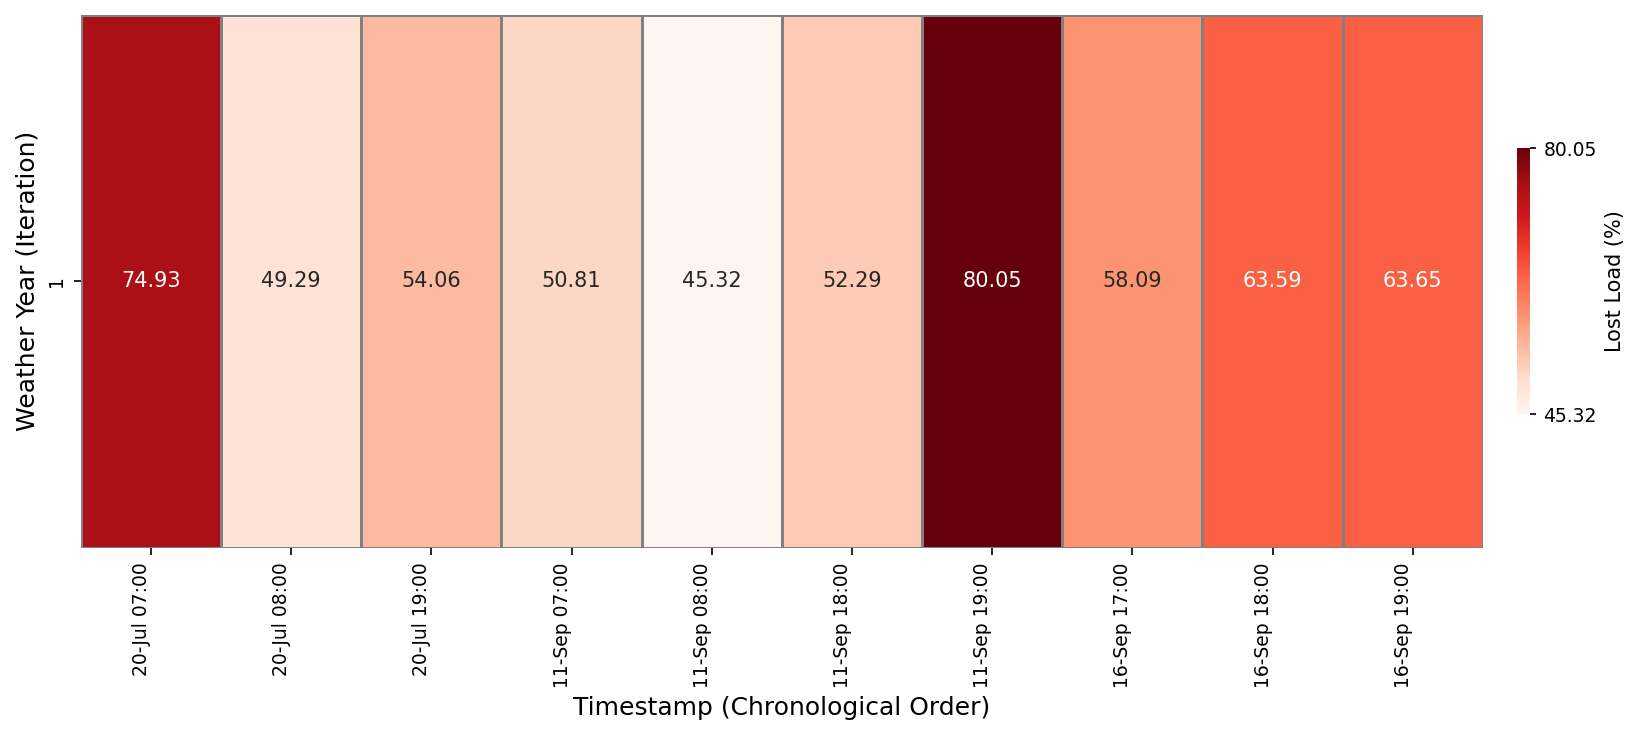

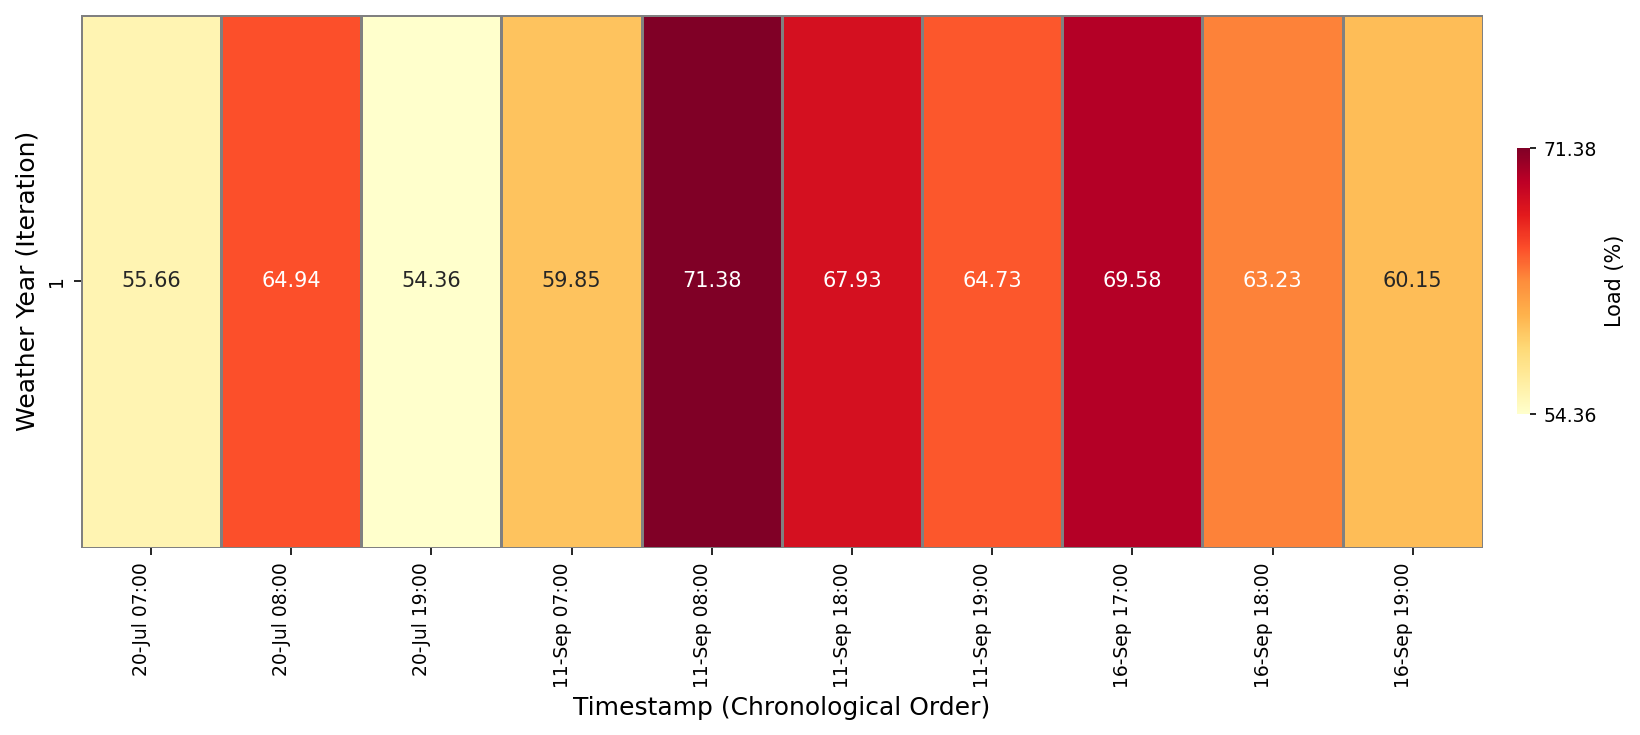

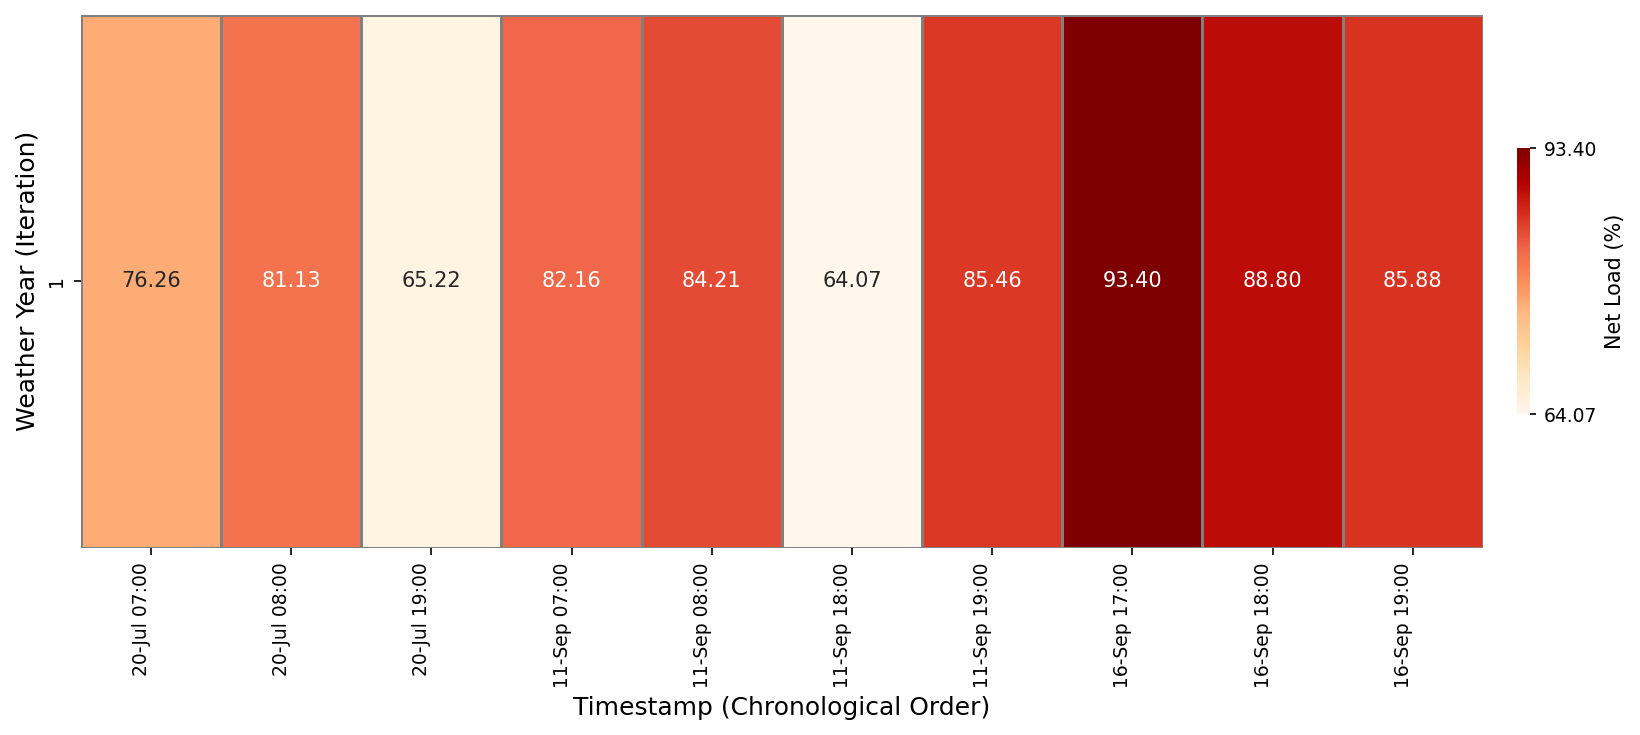

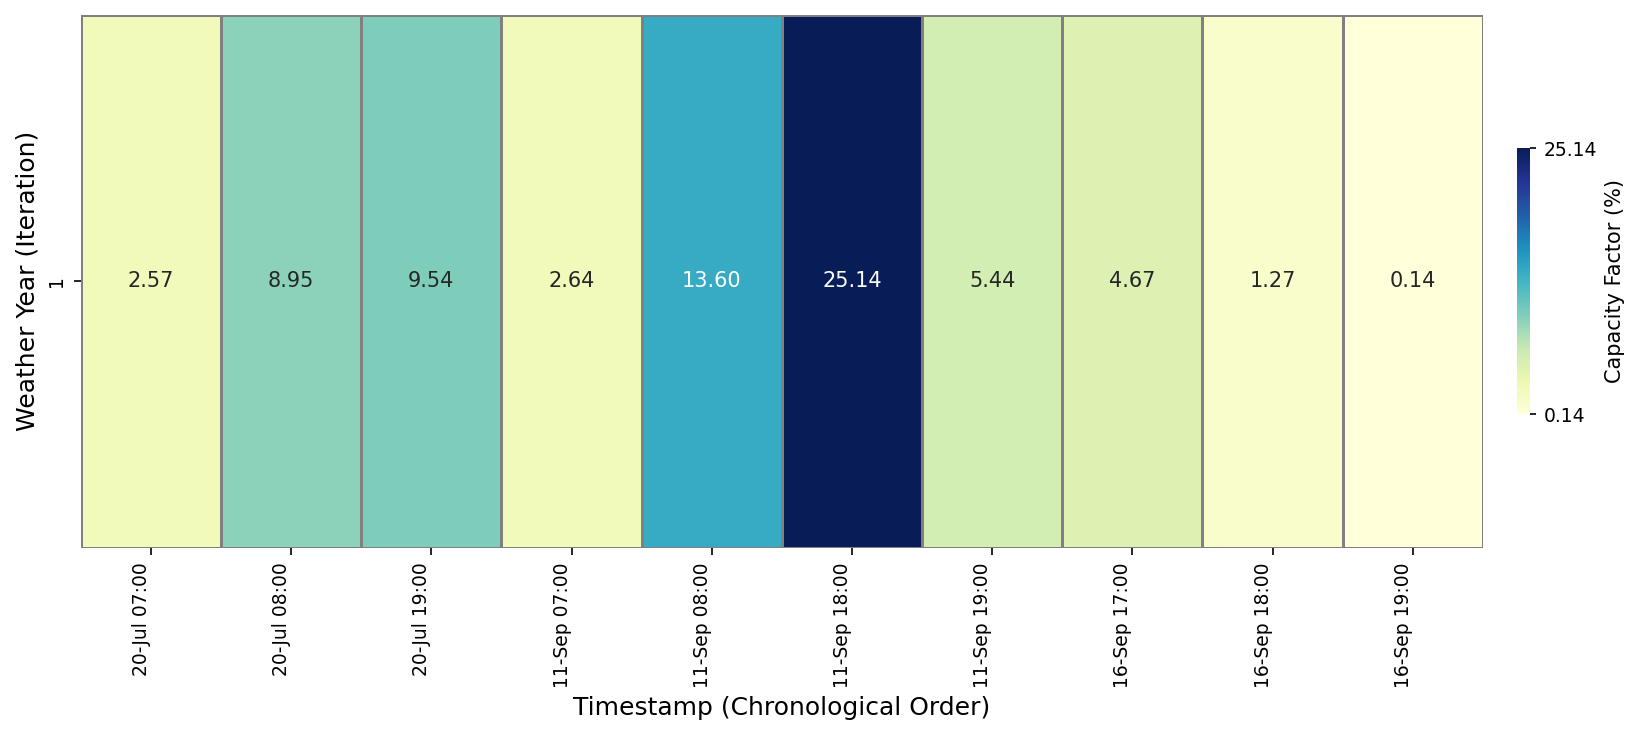

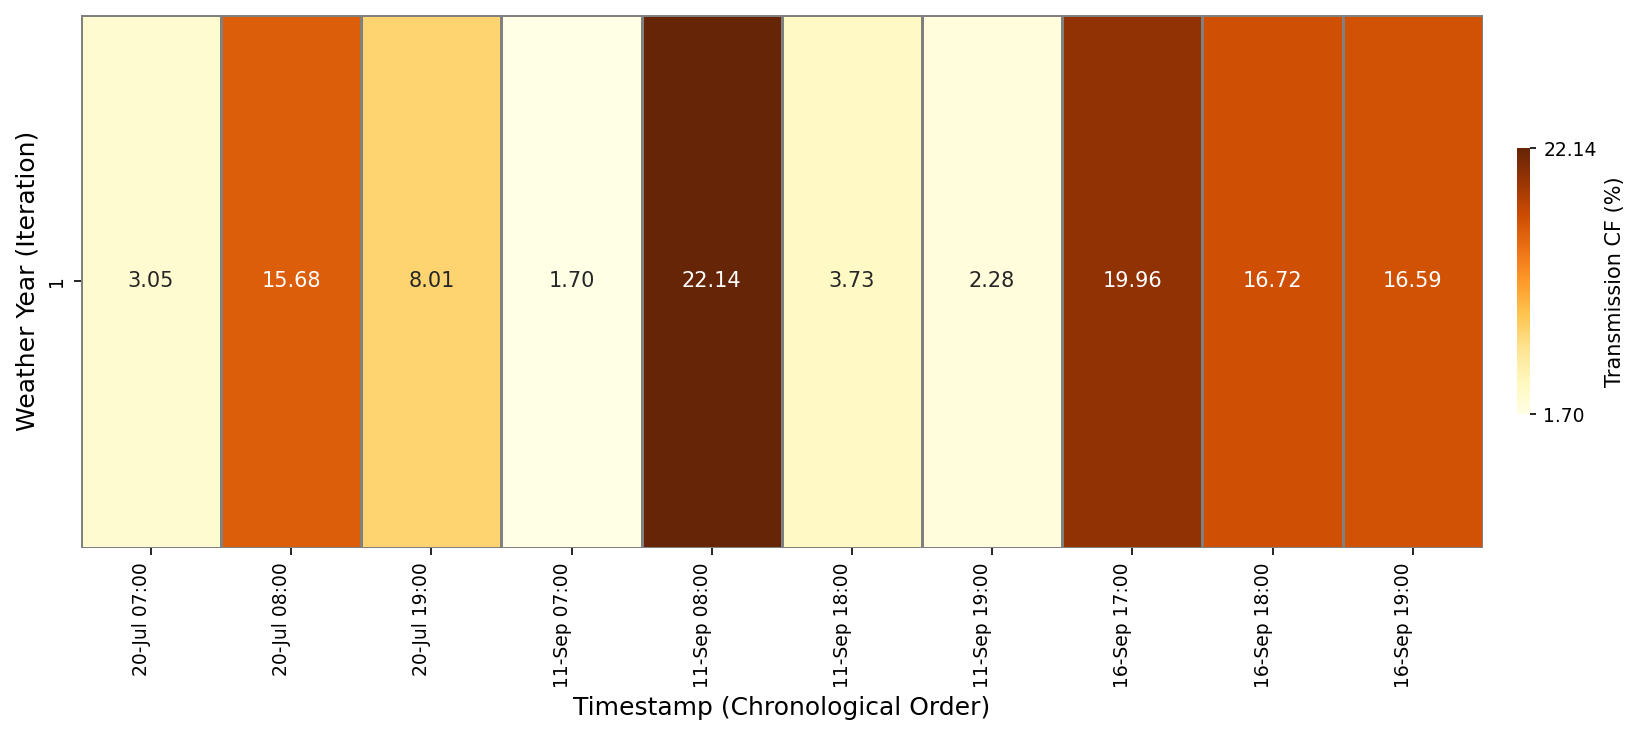

TypeError: Image data of dtype object cannot be converted to float

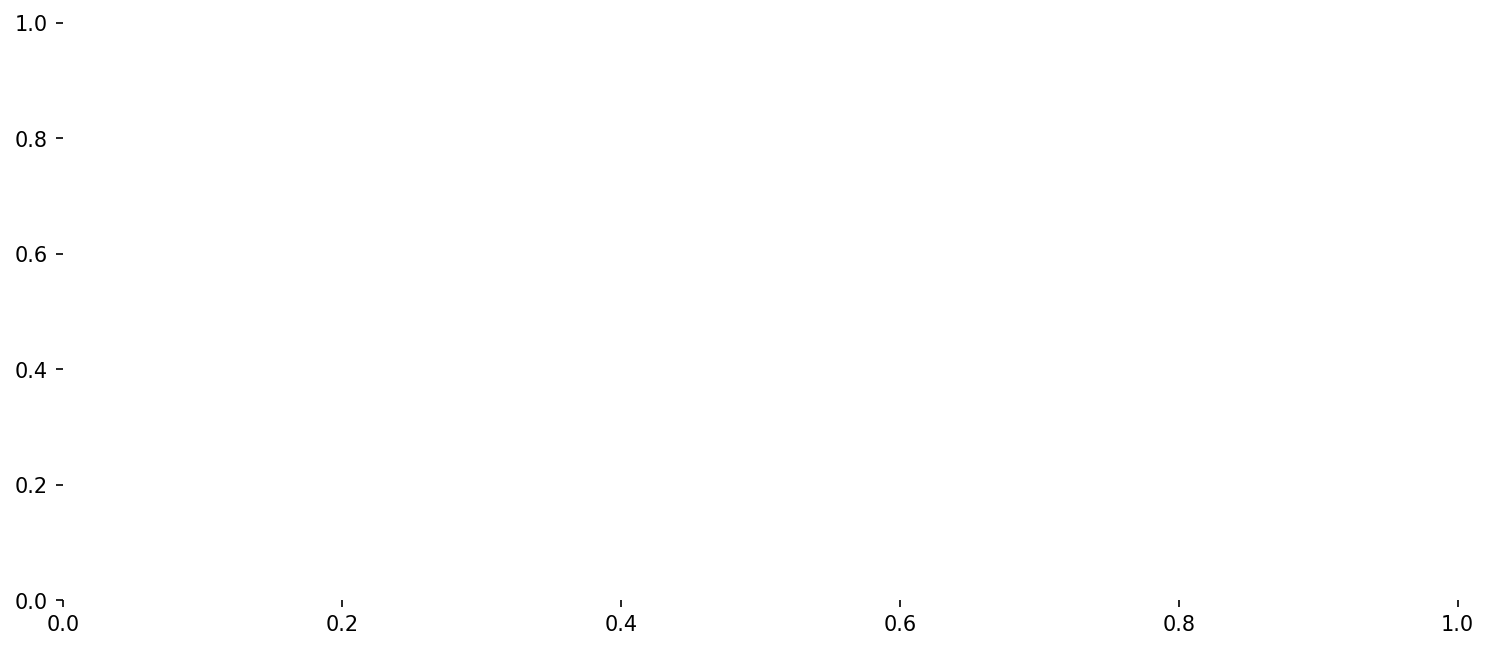

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ===============================================================
# 1️⃣  Select Top 10 timestamps with highest total unserved energy
# ===============================================================
top10_timestamps = (
    events_zone.groupby('timestamp')['unserved_energy']
    .sum()
    .nlargest(10)
    .index
)

# Filter only those timestamps
df_top = events_zone[events_zone['timestamp'].isin(top10_timestamps)].copy()

# ===============================================================
# 2️⃣  Assign Iteration Numbers (Weather Year)
# ===============================================================
unique_iters = (
    df_top[['W', 'H', 'A']]
    .drop_duplicates()
    .sort_values(['W', 'H', 'A'])
    .reset_index(drop=True)
)
unique_iters['iteration'] = range(1, len(unique_iters) + 1)
df_top = pd.merge(df_top, unique_iters, on=['W', 'H', 'A'], how='left')

# ===============================================================
# 3️⃣  Format Timestamp Labels (dd-mmm HH:MM)
# ===============================================================
df_top['timestamp_label'] = df_top['timestamp'].dt.strftime("%d-%b %H:%M")

# --- Order timestamps in CHRONOLOGICAL order ---
timestamp_order = (
    df_top[['timestamp', 'timestamp_label']]
    .drop_duplicates()
    .sort_values('timestamp')
    ['timestamp_label']
    .tolist()
)

# ===============================================================
# 4️⃣  Scale factor columns to percentages (if present)
# ===============================================================
for col in ['capacity_factor', 'tx_cap_factor', 'thermal_availability_factor']:
    if col in df_top.columns:
        df_top[col] = df_top[col] * 100.0

# ===============================================================
# 5️⃣  Generic plotting function (chronological timestamps)
# ===============================================================
def plot_metric_heatmap(df, metric, cmap, label):
    """Plot metric heatmap; timestamps in chronological order, drop no-lost iterations."""
    if metric not in df.columns:
        print(f"⚠️  '{metric}' not found — skipping.")
        return

    # Pivot tables for metric and lost_load mask
    heat_data = df.pivot_table(
        index='iteration',
        columns='timestamp_label',
        values=metric,
        aggfunc='mean'
    )
    lost_data = df.pivot_table(
        index='iteration',
        columns='timestamp_label',
        values='lost_load_pct',
        aggfunc='mean'
    )

    # Reorder columns chronologically
    heat_data = heat_data.reindex(columns=timestamp_order)
    lost_data = lost_data.reindex(columns=timestamp_order)

    # Drop Weather Years with no lost load
    keep_iters = (lost_data > 0).any(axis=1)
    heat_data = heat_data.loc[keep_iters]
    lost_data = lost_data.loc[keep_iters]

    # Mask cells where lost_load_pct ≤ 0
    mask = (lost_data <= 0) | (lost_data.isna())

    # Compute vmin/vmax based only on visible (unmasked) data
    visible_values = heat_data.mask(mask)
    if visible_values.notna().sum().sum() == 0:
        print(f"⚠️  No valid data for '{metric}' — skipping.")
        return
    vmin, vmax = visible_values.min().min(), visible_values.max().max()

    # Plot
    fig, ax = plt.subplots(figsize=(12, 5), dpi=150)
    hm = sns.heatmap(
        heat_data,
        mask=mask,
        cmap=cmap,
        annot=True, fmt=".2f",
        linewidths=0.5, linecolor='grey',
        cbar=True,
        vmin=vmin, vmax=vmax,
        cbar_kws={"orientation": "vertical", "pad": 0.02, "shrink": 0.5}
    )

    # Compact colorbar (min/max only)
    cbar = hm.collections[0].colorbar
    cbar.set_ticks([vmin, vmax])
    cbar.set_ticklabels([f"{vmin:.2f}", f"{vmax:.2f}"])
    cbar.ax.tick_params(labelsize=9, length=3)
    cbar.set_label(label, fontsize=10)

    # Axis labels
    ax.set_xlabel("Timestamp (Chronological Order)", fontsize=12)
    ax.set_ylabel("Weather Year (Iteration)", fontsize=12)
    plt.xticks(rotation=90, ha='right', fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.show()


# ===============================================================
# 6️⃣  Generate all heatmaps (chronological order, masked cleanly)
# ===============================================================
plot_metric_heatmap(df_top, 'lost_load_pct', 'Reds', 'Lost Load (%)')
plot_metric_heatmap(df_top, 'load_pct', 'YlOrRd', 'Load (%)')
plot_metric_heatmap(df_top, 'net_load_pct', 'OrRd', 'Net Load (%)')
plot_metric_heatmap(df_top, 'capacity_factor', 'YlGnBu', 'Capacity Factor (%)')
plot_metric_heatmap(df_top, 'tx_cap_factor', 'YlOrBr', 'Transmission CF (%)')
plot_metric_heatmap(df_top, 'thermal_availability_factor', 'PuBu', 'Thermal Availability (%)')

: 

: 